In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

worksheet = gc.open('Datasets for Food Insecurity')

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

In [ ]:
rows = worksheet.worksheet("Sources").get_all_values()
#print(rows)

# Convert to a DataFrame and render
import pandas as pd
sources_df = pd.DataFrame.from_records(rows[1:])
sources_df.columns = rows[0]

In [ ]:
def fix(df, county, state):
  df["State/Name"] = df[county] + df[state]

In [ ]:
def remove_state_avg(df, col):
  df[col]

# **Food Environmental Index**

In [ ]:
rows = worksheet.worksheet("Food Environmental Index").get_all_values()
#print(rows)

import pandas as pd
food_env_df = pd.DataFrame.from_records(rows[1:])
food_env_df.columns = rows[0]
state_abbreviations = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY"
}
def exclude_state_averages(name):
  return name not in state_abbreviations
def calculate_graduation_rate(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
for i in ["eighteenFoodEnvIndex", "nineteenFoodEnvIndex", "twentyFoodEnvIndex", "twentyOneFoodEnvIndex", "twentyTwoFoodEnvIndex", "twentyThreeFoodEnvIndex"]:
  food_env_df = food_env_df[food_env_df['County'].apply(exclude_state_averages)]
  food_env_df[i] = pd.to_numeric(food_env_df[i])
food_env_df["State/county"] = food_env_df["County"] + ", " + food_env_df["State"]

# Display the updated DataFrame
food_env_df


,State,County,eighteenFoodEnvIndex,nineteenFoodEnvIndex,twentyFoodEnvIndex,twentyOneFoodEnvIndex,twentyTwoFoodEnvIndex,twentyThreeFoodEnvIndex,twentyFourFoodEnvIndex,State/county
0,AL,Autauga County,7.1,7.2,7.2,6.7,6.5,6.6,6.7,"Autauga County, AL"
1,AL,Baldwin County,7.9,8.0,8.0,7.8,7.4,7.5,7.5,"Baldwin County, AL"
2,AL,Barbour County,5.5,5.6,5.6,5.5,5.7,5.8,6,"Barbour County, AL"
3,AL,Bibb County,7.6,7.6,7.8,7.6,7.6,7.4,7.6,"Bibb County, AL"
4,AL,Blount County,8.5,8.5,8.4,7.9,7.8,7.8,7.7,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,7.9,7.7,7.7,7.5,8.1,7.9,7.9,"Sweetwater County, WY"
3188,WY,Teton County,8.2,8.3,8.2,8.3,8.7,8.6,8.7,"Teton County, WY"
3189,WY,Uinta County,7.6,7.3,7.4,7.3,8.3,8.4,8.5,"Uinta County, WY"
3190,WY,Washakie County,8.4,8.2,8.3,8.0,8.3,8.3,8.6,"Washakie County, WY"


# **Median Household Income**

In [ ]:
rows = worksheet.worksheet("18-22 HHI").get_all_values()
rows3 = worksheet.worksheet("23 HHI").get_all_values()
#print(rows)

import pandas as pd
hhi1822_df = pd.DataFrame.from_records(rows[1:])
hhi1822_df.columns = rows[0]
hhi23_df = pd.DataFrame.from_records(rows3[1:])
hhi23_df.columns = rows3[0]
state_abbreviations = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY"
}
def exclude_state_averages(name):
  return name not in state_abbreviations
hhi1822_df = hhi1822_df[hhi1822_df['County'].apply(exclude_state_averages)]
hhi23_df = hhi23_df[hhi23_df['County'].apply(exclude_state_averages)]
hhi1822_df["State/county"] = hhi1822_df["County"] + ", " + hhi1822_df["State"]
hhi23_df["State/county"] = hhi23_df["County"] + ", " + hhi23_df["State"]

# Display the updated DataFrame
hhi_df = hhi23_df.merge(hhi1822_df, on="State/county", how="outer")

hhi_df["State/county"] = hhi_df["State/county"]

columns_to_fix = ['eighteenHHI', 'nineteenHHI', 'twentyHHI', 'twentyOneHHI', 'twentyTwoHHI', 'twentyThreeHHI']

for column_index in columns_to_fix:
  hhi_df[column_index] = pd.to_numeric(hhi_df[column_index])
hhi_df

,County_x,State_x,twentyThreeHHI,State/county,County_y,State_y,eighteenHHI,nineteenHHI,twentyHHI,twentyOneHHI,twentyTwoHHI
0,Abbeville County,SC,51580,"Abbeville County, SC",Abbeville County,SC,42412,46499,57216,59447,99015
1,Acadia Parish,LA,43133,"Acadia Parish, LA",Acadia Parish,LA,40484,44728,51730,52090,76633
2,Accomack County,VA,56039,"Accomack County, VA",Accomack County,VA,42879,47335,79154,80926,74244
3,Ada County,ID,90513,"Ada County, ID",Ada County,ID,66827,72295,62603,66318,89794
4,Adair County,IA,67873,"Adair County, IA",Adair County,IA,54282,57977,62362,65645,72448
...,...,...,...,...,...,...,...,...,...,...,...
3138,Yuma County,AZ,61225,"Yuma County, AZ",Yuma County,AZ,44116,47024,58860,57676,64187
3139,Yuma County,CO,61870,"Yuma County, CO",Yuma County,CO,53253,52841,77937,84826,90770
3140,Zapata County,TX,41688,"Zapata County, TX",Zapata County,TX,33160,36069,54569,53715,62748
3141,Zavala County,TX,36878,"Zavala County, TX",Zavala County,TX,30076,32538,39876,37474,58297


# **Poverty**

In [ ]:
rows = worksheet.worksheet("Poverty").get_all_values()
#print(rows)

import pandas as pd
poverty_df = pd.DataFrame.from_records(rows[1:])
poverty_df.columns = rows[0]
state_abbreviations = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY"
}
def calculate_graduation_rate(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
for i in ["eighteenPoverty", "nineteenPoverty", "twentyPoverty", "twentyOnePoverty", "twentyTwoPoverty", "twentyThreePoverty"]:
  calculate_graduation_rate(poverty_df[i])
def exclude_state_averages(name):
  return name not in state_abbreviations
poverty_df = poverty_df[poverty_df['County'].apply(exclude_state_averages)]

poverty_df["eighteenPoverty"]=calculate_graduation_rate(poverty_df["eighteenPoverty"])
poverty_df["nineteenPoverty"]=calculate_graduation_rate(poverty_df["nineteenPoverty"])
poverty_df["twentyPoverty"]=calculate_graduation_rate(poverty_df["twentyPoverty"])
poverty_df["twentyOnePoverty"]=calculate_graduation_rate(poverty_df["twentyOnePoverty"])
poverty_df["twentyTwoPoverty"]=calculate_graduation_rate(poverty_df["twentyTwoPoverty"])
poverty_df["twentyThreePoverty"]=calculate_graduation_rate(poverty_df["twentyThreePoverty"])

poverty_df["State/county"] = poverty_df["County"] + ", " + poverty_df["State"]

poverty_df

,State,County,eighteenPoverty,nineteenPoverty,twentyPoverty,twentyOnePoverty,twentyTwoPoverty,twentyThreePoverty,twentyFourPoverty,State/county
0,AL,Autauga County,19.3,19.3,19.3,15.9,14.9,16.1,0.157,"Autauga County, AL"
1,AL,Baldwin County,17.6,14.7,13.9,13.5,12.4,16.4,0.161,"Baldwin County, AL"
2,AL,Barbour County,39.6,50.3,43.9,41.0,37.5,35.1,0.377,"Barbour County, AL"
3,AL,Bibb County,27.5,27.3,27.8,25.9,21.9,29.0,0.255,"Bibb County, AL"
4,AL,Blount County,19.4,18.5,18.0,21.0,18.9,16.7,0.158,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,9.2,13.4,10.0,10.1,8.4,9.7,0.149,"Sweetwater County, WY"
3188,WY,Teton County,6.7,6.9,6.7,5.7,4.3,5.5,0.053,"Teton County, WY"
3189,WY,Uinta County,11.3,11.8,12.1,9.6,9.7,11.2,0.132,"Uinta County, WY"
3190,WY,Washakie County,15.2,14.0,16.1,13.9,10.7,12.5,0.143,"Washakie County, WY"


# **Unemployment**

### **Unemployment Data Preprocessing**

In [ ]:

rows = worksheet.worksheet("Unemployment").get_all_values()
#print(rows)

import pandas as pd
unnemployment_df = pd.DataFrame.from_records(rows[1:])
unnemployment_df.columns = rows[0]

def calculate_graduation_rate(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
unnemployment_df["eighteenUnemployment"]=calculate_graduation_rate(unnemployment_df["eighteenUnemployment"])
unnemployment_df["nineteenUnemployment"]=calculate_graduation_rate(unnemployment_df["nineteenUnemployment"])
unnemployment_df["twentyUnemployment"]=calculate_graduation_rate(unnemployment_df["twentyUnemployment"])
unnemployment_df["twentyOneUnemployment"]=calculate_graduation_rate(unnemployment_df["twentyOneUnemployment"])
unnemployment_df["twentyTwoUnemployment"]=calculate_graduation_rate(unnemployment_df["twentyTwoUnemployment"])
unnemployment_df["twentyThreeUnemployment"]=calculate_graduation_rate(unnemployment_df["twentyThreeUnemployment"])
unnemployment_df = unnemployment_df[unnemployment_df['County'].apply(exclude_state_averages)]

unnemployment_df["State/county"] = unnemployment_df["County"] + ", " + unnemployment_df["State"]
unnemployment_df

,State,County,eighteenUnemployment,nineteenUnemployment,twentyUnemployment,twentyOneUnemployment,twentyTwoUnemployment,twentyThreeUnemployment,twentyFourUnemployment,State/county
0,AL,Autauga County,5.2712,3.8635,3.6291,2.7281,4.8843,2.8169,0.022696,"Autauga County, AL"
1,AL,Baldwin County,5.4153,3.9883,3.6154,2.7258,5.6065,2.9630,0.0235,"Baldwin County, AL"
2,AL,Barbour County,8.6485,5.9009,5.1714,3.7952,7.0455,5.7216,0.04065,"Barbour County, AL"
3,AL,Bibb County,6.6371,4.3851,3.9718,3.0628,6.6319,3.4813,0.025097,"Bibb County, AL"
4,AL,Blount County,5.5209,4.0214,3.5112,2.6687,4.0874,2.3799,0.022252,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,5.9825,4.5503,4.2364,3.8921,7.3512,5.5993,0.041575,"Sweetwater County, WY"
3188,WY,Teton County,3.4095,2.9870,3.0248,2.7223,5.9984,3.2167,0.027272,"Teton County, WY"
3189,WY,Uinta County,5.7668,4.4977,4.3668,3.9070,6.2500,5.0159,0.038249,"Uinta County, WY"
3190,WY,Washakie County,4.6838,4.0826,4.2385,3.9330,5.2697,3.9970,0.039917,"Washakie County, WY"


# **Population**

### **Population Data Preprocessing**

In [ ]:
def clean_number(number):
  number = number.strip()
  number = number.replace(",", "")
  if number == 'N.A.': return float('nan')
  return int(number)

In [ ]:
rows = worksheet.worksheet("Population").get_all_values()
#print(rows)

import pandas as pd
population_df = pd.DataFrame.from_records(rows[1:])
population_df.columns = rows[0]
state_abbreviations = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY"
}
def exclude_state_averages(name):
  return name not in state_abbreviations
population_df = population_df[population_df['County'].apply(exclude_state_averages)]
population_df["State/county"] = population_df["County"] + ", " + population_df["State"]

population_df

,State,County,eighteenPopulation,nineteenPopulation,twentyPopulation,twentyOnePopulation,twentyTwoPopulation,twentyThreePopulation,twentyFourPopulation,State/county
0,AL,Autauga County,55416,55504,55601,55869,56145,59095,59759,"Autauga County, AL"
1,AL,Baldwin County,208563,212628,218022,223234,229287,239294,246435,"Baldwin County, AL"
2,AL,Barbour County,25965,25270,24881,24686,24589,24964,24706,"Barbour County, AL"
3,AL,Bibb County,22643,22668,22400,22394,22136,22477,22005,"Bibb County, AL"
4,AL,Blount County,57704,58013,57840,57826,57879,59041,59512,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,44165,43534,43051,42343,42673,41614,41345,"Sweetwater County, WY"
3188,WY,Teton County,23191,23265,23081,23464,23497,23575,23287,"Teton County, WY"
3189,WY,Uinta County,20773,20495,20299,20226,20215,20635,20712,"Uinta County, WY"
3190,WY,Washakie County,8235,8064,7885,7805,7760,7705,7719,"Washakie County, WY"


### **Population Modeling**

In [ ]:
population_df['eighteenPopulation'] = pd.to_numeric(population_df['eighteenPopulation'], errors='coerce')
population_df['nineteenPopulation'] = pd.to_numeric(population_df['nineteenPopulation'], errors='coerce')
population_df['twentyPopulation'] = pd.to_numeric(population_df['twentyPopulation'], errors='coerce')
population_df['twentyOnePopulation'] = pd.to_numeric(population_df['twentyOnePopulation'], errors='coerce')
population_df['twentyTwoPopulation'] = pd.to_numeric(population_df['twentyTwoPopulation'], errors='coerce')
population_df['twentyThreePopulation'] = pd.to_numeric(population_df['twentyThreePopulation'], errors='coerce')
population_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3143 entries, 0 to 3191
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   State                  3143 non-null   object
 1   County                 3143 non-null   object
 2   eighteenPopulation     3143 non-null   int64 
 3   nineteenPopulation     3143 non-null   int64 
 4   twentyPopulation       3143 non-null   int64 
 5   twentyOnePopulation    3143 non-null   int64 
 6   twentyTwoPopulation    3143 non-null   int64 
 7   twentyThreePopulation  3143 non-null   int64 
 8   twentyFourPopulation   3143 non-null   object
 9   State/county           3143 non-null   object
dtypes: int64(6), object(4)
memory usage: 270.1+ KB


In [ ]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

In [ ]:
'''def metrics(mod):
  return np.round(mod.aic), np.round(mod.llf), np.round(mod.rsquared, 3), np.round(np.mean(np.abs(population_df[depvar] - mod.fittedvalues)), 3), np.round(mod.fvalue)'''

'def metrics(mod):\n  return np.round(mod.aic), np.round(mod.llf), np.round(mod.rsquared, 3), np.round(np.mean(np.abs(population_df[depvar] - mod.fittedvalues)), 3), np.round(mod.fvalue)'

In [ ]:
'''population_df = population_df.rename(columns={"2018":"eighteenpop", "2019":"nineteenpop", "2020":"twentypop", "2021":"twentyOnepop", "2022":"twentyTwopop", "2023":"twentyThreepop"})'''

'population_df = population_df.rename(columns={"2018":"eighteenpop", "2019":"nineteenpop", "2020":"twentypop", "2021":"twentyOnepop", "2022":"twentyTwopop", "2023":"twentyThreepop"})'

In [ ]:
'''depvar = "twentyThreepop"
pop1 = smf.ols(formula=depvar + ' ~ eighteenpop + nineteenpop + twentypop + twentyOnepop + twentyTwopop', data=population_df)  #C(2018_UnemploymentRate) will assume values are categories
pop1 = pop1.fit()'''

'depvar = "twentyThreepop"\npop1 = smf.ols(formula=depvar + \' ~ eighteenpop + nineteenpop + twentypop + twentyOnepop + twentyTwopop\', data=population_df)  #C(2018_UnemploymentRate) will assume values are categories\npop1 = pop1.fit()'

In [ ]:
'''pop1.summary()'''

'pop1.summary()'

In [ ]:
'''y_pred = pop1.fittedvalues'''

'y_pred = pop1.fittedvalues'

In [ ]:
'''plt.scatter(y_pred, population_df['twentyThreepop']);'''

"plt.scatter(y_pred, population_df['twentyThreepop']);"

In [ ]:
'''from sklearn.model_selection import train_test_split'''

'from sklearn.model_selection import train_test_split'

In [ ]:
'''def clean_number(number):
  number = number.strip()
  number = number.replace(",", "")
  if number == 'N.A.': return float('nan')
  return int(number)'''

'def clean_number(number):\n  number = number.strip()\n  number = number.replace(",", "")\n  if number == \'N.A.\': return float(\'nan\')\n  return int(number)'

# **Graduation**

### **Graduation Data Preprocessing**

In [ ]:
rows = worksheet.worksheet("College graduation").get_all_values()
#print(rows)

import pandas as pd
graduation_df = pd.DataFrame.from_records(rows[1:])
graduation_df.columns = rows[0]

def calculate_graduation_rate(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
graduation_df["eighteenCollege"]=calculate_graduation_rate(graduation_df["eighteenCollege"])
graduation_df["nineteenCollege"]=calculate_graduation_rate(graduation_df["nineteenCollege"])
graduation_df["twentyCollege"]=calculate_graduation_rate(graduation_df["twentyCollege"])
graduation_df["twentyOneCollege"]=calculate_graduation_rate(graduation_df["twentyOneCollege"])
graduation_df["twentyTwoCollege"]=calculate_graduation_rate(graduation_df["twentyTwoCollege"])
graduation_df["twentyThreeCollege"]=calculate_graduation_rate(graduation_df["twentyThreeCollege"])
def exclude_state_averages(name):
  return name not in state_abbreviations
graduation_df = graduation_df[graduation_df['County'].apply(exclude_state_averages)]
graduation_df["State/county"] = graduation_df["County"] + ", " + graduation_df["State"]
graduation_df

,State,County,eighteenCollege,nineteenCollege,twentyCollege,twentyOneCollege,twentyTwoCollege,twentyThreeCollege,twentyFourCollege,State/county
0,AL,Autauga County,61.9420,60.8547,62.0100,60.4999,60.7217,59.6126,0.641475,"Autauga County, AL"
1,AL,Baldwin County,63.7571,66.1339,67.3716,67.1086,65.5321,66.1050,0.656804,"Baldwin County, AL"
2,AL,Barbour County,39.7237,36.7740,34.8576,35.6138,38.3558,38.6269,0.404545,"Barbour County, AL"
3,AL,Bibb County,49.8214,48.4063,44.1374,40.1390,37.7704,36.8668,0.389935,"Bibb County, AL"
4,AL,Blount County,53.8665,54.4140,53.3611,55.7510,56.2666,56.7789,0.51976,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,57.9380,59.2955,58.8881,62.7312,61.9264,61.8404,0.62227,"Sweetwater County, WY"
3188,WY,Teton County,78.9154,82.0042,81.3974,79.4078,76.0398,74.6570,0.746105,"Teton County, WY"
3189,WY,Uinta County,57.0850,55.8918,57.5311,54.7767,57.7033,57.2581,0.586154,"Uinta County, WY"
3190,WY,Washakie County,54.6709,60.1322,59.0832,60.2586,62.4040,74.2841,0.756268,"Washakie County, WY"


### **Graduation Modeling**

In [ ]:
graduation_df['eighteenCollege'] = pd.to_numeric(graduation_df['eighteenCollege'], errors='coerce')
graduation_df['nineteenCollege'] = pd.to_numeric(graduation_df['nineteenCollege'], errors='coerce')
graduation_df['twentyCollege'] = pd.to_numeric(graduation_df['twentyCollege'], errors='coerce')
graduation_df['twentyOneCollege'] = pd.to_numeric(graduation_df['twentyOneCollege'], errors='coerce')
graduation_df['twentyTwoCollege'] = pd.to_numeric(graduation_df['twentyTwoCollege'], errors='coerce')
graduation_df['twentyThreeCollege'] = pd.to_numeric(graduation_df['twentyThreeCollege'], errors='coerce')
graduation_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3143 entries, 0 to 3191
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               3143 non-null   object 
 1   County              3143 non-null   object 
 2   eighteenCollege     3143 non-null   float64
 3   nineteenCollege     3143 non-null   float64
 4   twentyCollege       3143 non-null   float64
 5   twentyOneCollege    3143 non-null   float64
 6   twentyTwoCollege    3143 non-null   float64
 7   twentyThreeCollege  3143 non-null   float64
 8   twentyFourCollege   3143 non-null   object 
 9   State/county        3143 non-null   object 
dtypes: float64(6), object(4)
memory usage: 270.1+ KB


In [ ]:
'''
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr'''

'\nfrom sklearn.model_selection import train_test_split\nimport statsmodels.api as sm\nimport statsmodels.formula.api as smf\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom scipy.stats import pearsonr, spearmanr'

In [ ]:
'''def metrics(mod):
  return np.round(mod.aic), np.round(mod.llf), np.round(mod.rsquared, 3), np.round(np.mean(np.abs(graduation_df[depvar] - mod.fittedvalues)), 3), np.round(mod.fvalue)'''

'def metrics(mod):\n  return np.round(mod.aic), np.round(mod.llf), np.round(mod.rsquared, 3), np.round(np.mean(np.abs(graduation_df[depvar] - mod.fittedvalues)), 3), np.round(mod.fvalue)'

In [ ]:
'''graduation_df = graduation_df.rename(columns={"2018_college":"eighteenCollege", "2019_college":"nineteenCollege", "2020_college":"twentyCollege", "2021_college":"twentyOneCollege", "2022_college":"twentyTwoCollege", "2023_college":"twentyThreeCollege"})'''

'graduation_df = graduation_df.rename(columns={"2018_college":"eighteenCollege", "2019_college":"nineteenCollege", "2020_college":"twentyCollege", "2021_college":"twentyOneCollege", "2022_college":"twentyTwoCollege", "2023_college":"twentyThreeCollege"})'

In [ ]:
'''depvar = "twentyThreeCollege"
grad1 = smf.ols(formula=depvar + ' ~ eighteenCollege + nineteenCollege + twentyCollege + twentyOneCollege + twentyTwoCollege', data=graduation_df)  #C(2018_UnemploymentRate) will assume values are categories
grad1 = grad1.fit()'''

'depvar = "twentyThreeCollege"\ngrad1 = smf.ols(formula=depvar + \' ~ eighteenCollege + nineteenCollege + twentyCollege + twentyOneCollege + twentyTwoCollege\', data=graduation_df)  #C(2018_UnemploymentRate) will assume values are categories\ngrad1 = grad1.fit()'

In [ ]:
'''grad1.summary()'''

'grad1.summary()'

In [ ]:
'''y_pred = grad1.fittedvalues'''

'y_pred = grad1.fittedvalues'

In [ ]:
'''plt.scatter(y_pred, graduation_df['twentyThreeCollege']);'''

"plt.scatter(y_pred, graduation_df['twentyThreeCollege']);"

# **Age Distribution**

### **Data**

In [ ]:
rows = worksheet.worksheet("Age Distribution").get_all_values()
#print(rows)

import pandas as pd
age_df = pd.DataFrame.from_records(rows[1:])
age_df.columns = rows[0]

def calculate_gender_rate(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
age_df["eighteen_Children"]=calculate_gender_rate(age_df["eighteen_Children"])
age_df["nineteen_Children"]=calculate_gender_rate(age_df["nineteen_Children"])
age_df["twenty_Children"]=calculate_gender_rate(age_df["twenty_Children"])
age_df["twentyOne_Children"]=calculate_gender_rate(age_df["twentyOne_Children"])
age_df["twentyTwo_Children"]=calculate_gender_rate(age_df["twentyTwo_Children"])
age_df["twentyThree_Children"]=calculate_gender_rate(age_df["twentyThree_Children"])
age_df["eighteen_Elder"]=calculate_gender_rate(age_df["eighteen_Elder"])
age_df["nineteen_Elder"]=calculate_gender_rate(age_df["nineteen_Elder"])
age_df["twenty_Elder"]=calculate_gender_rate(age_df["twenty_Elder"])
age_df["twentyOne_Elder"]=calculate_gender_rate(age_df["twentyOne_Elder"])
age_df["twentyTwo_Elder"]=calculate_gender_rate(age_df["twentyTwo_Elder"])
age_df["twentyThree_Elder"]=calculate_gender_rate(age_df["twentyThree_Elder"])

def exclude_state_averages(name):
  return name not in state_abbreviations
age_df = age_df[age_df['County'].apply(exclude_state_averages)]
age_df["State/county"] = age_df["County"] + ", " + age_df["State"]
age_df

,State,County,eighteen_Children,nineteen_Children,twenty_Children,twentyOne_Children,twentyTwo_Children,twentyThree_Children,eighteen_Elder,nineteen_Elder,twenty_Elder,twentyOne_Elder,twentyTwo_Elder,twentyThree_Elder,twentyFour_Elder,State/county
0,AL,Autauga County,24.4081,23.9370,23.6740,23.2061,23.1846,23.4064,14.7286,15.1196,15.5627,15.9731,16.1760,16.0487,0.164109,"Autauga County, AL"
1,AL,Baldwin County,21.7344,21.8485,21.6079,21.3023,21.1285,21.2183,19.7082,19.9470,20.4433,20.9780,21.5821,21.4698,0.219287,"Baldwin County, AL"
2,AL,Barbour County,21.1361,20.7638,20.8673,20.5866,20.4726,20.5496,18.0166,18.8247,19.4204,19.6913,20.2611,19.9768,0.206225,"Barbour County, AL"
3,AL,Bibb County,20.7526,20.6061,20.4777,20.3492,19.9946,20.1183,15.4308,16.0226,16.4732,16.6696,17.0763,16.7371,0.17805,"Bibb County, AL"
4,AL,Blount County,23.1908,23.3499,23.1535,22.9222,22.8027,23.0535,17.9866,17.8426,18.2365,18.7009,19.0034,18.7260,0.190903,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,26.8674,26.5172,26.2247,25.9027,25.4095,25.1550,10.4721,11.3750,12.1112,12.9632,13.7417,14.1443,0.149329,"Sweetwater County, WY"
3188,WY,Teton County,18.7745,18.7965,18.3658,17.8998,17.7086,17.5695,13.5268,14.3950,15.4153,15.8413,16.5979,16.8993,0.175892,"Teton County, WY"
3189,WY,Uinta County,29.3554,29.2120,28.7896,28.4386,27.7418,27.7635,12.5981,13.1886,14.0795,14.9560,15.6567,15.8953,0.16797,"Uinta County, WY"
3190,WY,Washakie County,23.8980,23.8095,22.7394,22.8571,21.9845,21.2070,20.9107,20.8085,21.6867,22.1653,23.2861,23.1798,0.238243,"Washakie County, WY"


### **Modelling**

In [ ]:
age_df['eighteen_Children'] = pd.to_numeric(age_df['eighteen_Children'], errors='coerce')
age_df['nineteen_Children'] = pd.to_numeric(age_df['nineteen_Children'], errors='coerce')
age_df['twenty_Children'] = pd.to_numeric(age_df['twenty_Children'], errors='coerce')
age_df['twentyOne_Children'] = pd.to_numeric(age_df['twentyOne_Children'], errors='coerce')
age_df['twentyTwo_Children'] = pd.to_numeric(age_df['twentyTwo_Children'], errors='coerce')
age_df['twentyThree_Children'] = pd.to_numeric(age_df['twentyThree_Children'], errors='coerce')
age_df['eighteen_Elder'] = pd.to_numeric(age_df['eighteen_Elder'], errors='coerce')
age_df['nineteen_Elder'] = pd.to_numeric(age_df['nineteen_Elder'], errors='coerce')
age_df['twenty_Elder'] = pd.to_numeric(age_df['twenty_Elder'], errors='coerce')
age_df['twentyOne_Elder'] = pd.to_numeric(age_df['twentyOne_Elder'], errors='coerce')
age_df['twentyTwo_Elder'] = pd.to_numeric(age_df['twentyTwo_Elder'], errors='coerce')
age_df['twentyThree_Elder'] = pd.to_numeric(age_df['twentyThree_Elder'], errors='coerce')
age_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3143 entries, 0 to 3191
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 3143 non-null   object 
 1   County                3143 non-null   object 
 2   eighteen_Children     3143 non-null   float64
 3   nineteen_Children     3143 non-null   float64
 4   twenty_Children       3143 non-null   float64
 5   twentyOne_Children    3143 non-null   float64
 6   twentyTwo_Children    3143 non-null   float64
 7   twentyThree_Children  3143 non-null   float64
 8   eighteen_Elder        3143 non-null   float64
 9   nineteen_Elder        3143 non-null   float64
 10  twenty_Elder          3143 non-null   float64
 11  twentyOne_Elder       3143 non-null   float64
 12  twentyTwo_Elder       3143 non-null   float64
 13  twentyThree_Elder     3143 non-null   float64
 14  twentyFour_Elder      3143 non-null   object 
 15  State/county          3143

In [ ]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

In [ ]:
def metrics(mod):
  return np.round(mod.aic), np.round(mod.llf), np.round(mod.rsquared, 3), np.round(np.mean(np.abs(age_df[depvar] - mod.fittedvalues)), 3), np.round(mod.fvalue)

In [ ]:
depvar = "twentyThree_Children"
modChildren = smf.ols(formula=depvar + ' ~ eighteen_Children + nineteen_Children + twenty_Children + twentyOne_Children + twentyTwo_Children', data=age_df)  #C(2018_UnemploymentRate) will assume values are categories
modChildren = modChildren.fit()

In [ ]:
metrics(modChildren)

(np.float64(2649.0),
 np.float64(-1318.0),
 np.float64(0.989),
 np.float64(0.217),
 np.float64(56943.0))

In [ ]:
depvar = "twentyThree_Elder"
modElder = smf.ols(formula=depvar + ' ~ eighteen_Elder + nineteen_Elder + twenty_Elder + twentyOne_Elder + twentyTwo_Elder', data=age_df)  #C(2018_UnemploymentRate) will assume values are categories
modElder = modElder.fit()

In [ ]:
metrics(modElder)

(np.float64(1872.0),
 np.float64(-930.0),
 np.float64(0.995),
 np.float64(0.198),
 np.float64(136424.0))

# **Male and female distribution**

### **Data**

In [ ]:
rows = worksheet.worksheet("Gender Distribution").get_all_values()
#print(rows)

import pandas as pd
gender_df = pd.DataFrame.from_records(rows[1:])
gender_df.columns = rows[0]

def calculate_gender_rate(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
gender_df["eighteenFemale"]=calculate_gender_rate(gender_df["eighteenFemale"])
gender_df["eighteenMale"]=100-gender_df["eighteenFemale"]
gender_df["nineteenFemale"]=calculate_gender_rate(gender_df["nineteenFemale"])
gender_df["nineteenMale"]=100-gender_df["nineteenFemale"]
gender_df["twentyFemale"]=calculate_gender_rate(gender_df["twentyFemale"])
gender_df["twentyMale"]=100-gender_df["twentyFemale"]
gender_df["twentyOneFemale"]=calculate_gender_rate(gender_df["twentyFemale"])
gender_df["twentyOneMale"]=100-gender_df["twentyOneFemale"]
gender_df["twentyTwoFemale"]=calculate_gender_rate(gender_df["twentyTwoFemale"])
gender_df["twentyTwoMale"]=100-gender_df["twentyTwoFemale"]
gender_df["twentyThreeFemale"]=calculate_gender_rate(gender_df["twentyThreeFemale"])
gender_df["twentyThreeMale"]=100-gender_df["twentyThreeFemale"]

def exclude_state_averages(name):
  return name not in state_abbreviations
gender_df = gender_df[gender_df['County'].apply(exclude_state_averages)]
gender_df["State/county"] = gender_df["County"] + ", " + gender_df["State"]
gender_df

,State,County,eighteenFemale,nineteenFemale,twentyFemale,twentyOneFemale,twentyTwoFemale,twentyThreeFemale,twentyFourFemale,eighteenMale,nineteenMale,twentyMale,twentyOneMale,twentyTwoMale,twentyThreeMale,State/county
0,AL,Autauga County,51.2884,51.3422,51.4487,5144.87,51.5077,51.3783,0.51296,48.7116,48.6578,48.5513,-5044.87,48.4923,48.6217,"Autauga County, AL"
1,AL,Baldwin County,51.4578,51.4528,51.5384,5153.84,51.5891,51.3477,0.512391,48.5422,48.5472,48.4616,-5053.84,48.4109,48.6523,"Baldwin County, AL"
2,AL,Barbour County,46.9324,47.2299,47.2168,4721.68,47.1837,46.7033,0.471222,53.0676,52.7701,52.7832,-4621.68,52.8163,53.2967,"Barbour County, AL"
3,AL,Bibb County,46.3631,46.4531,46.7813,4678.13,46.8151,46.0159,0.464894,53.6369,53.5469,53.2187,-4578.13,53.1849,53.9841,"Bibb County, AL"
4,AL,Blount County,50.6135,50.6886,50.7261,5072.61,50.5572,50.1922,0.502907,49.3865,49.3114,49.2739,-4972.61,49.4428,49.8078,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,48.1784,48.4541,48.5447,4854.47,48.3608,48.2001,0.480735,51.8216,51.5459,51.4553,-4754.47,51.6392,51.7999,"Sweetwater County, WY"
3188,WY,Teton County,48.4024,48.0980,48.4034,4840.34,48.1338,47.7073,0.475845,51.5976,51.9020,51.5966,-4740.34,51.8662,52.2927,"Teton County, WY"
3189,WY,Uinta County,49.4295,49.5731,49.3325,4933.25,49.3940,48.9750,0.488316,50.5705,50.4269,50.6675,-4833.25,50.6060,51.0250,"Uinta County, WY"
3190,WY,Washakie County,49.6782,49.4668,49.4230,4942.30,49.0464,48.5918,0.485296,50.3218,50.5332,50.5770,-4842.30,50.9536,51.4082,"Washakie County, WY"


### **Modeling**

In [ ]:
gender_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3143 entries, 0 to 3191
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              3143 non-null   object 
 1   County             3143 non-null   object 
 2   eighteenFemale     3143 non-null   float64
 3   nineteenFemale     3143 non-null   float64
 4   twentyFemale       3143 non-null   float64
 5   twentyOneFemale    3143 non-null   float64
 6   twentyTwoFemale    3143 non-null   float64
 7   twentyThreeFemale  3143 non-null   float64
 8   twentyFourFemale   3143 non-null   object 
 9   eighteenMale       3143 non-null   float64
 10  nineteenMale       3143 non-null   float64
 11  twentyMale         3143 non-null   float64
 12  twentyOneMale      3143 non-null   float64
 13  twentyTwoMale      3143 non-null   float64
 14  twentyThreeMale    3143 non-null   float64
 15  State/county       3143 non-null   object 
dtypes: float64(12), object(4)
mem

In [ ]:
#Assign data according to importance of year, linear model will fit weights to adjust for it
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

In [ ]:
def metrics(mod):
  return np.round(mod.aic), np.round(mod.llf), np.round(mod.rsquared, 3), np.round(np.mean(np.abs(gender_df[depvar] - mod.fittedvalues)), 3), np.round(mod.fvalue)

In [ ]:
'''gender_df = gender_df.rename(columns={"2018_Female":"eighteenFemale", "2019_Female":"nineteenFemale", "2020_Female":"twentyFemale", "2021_Female":"twentyOneFemale", "2022_Female":"twentyTwoFemale", "2023_Female":"twentyThreeFemale", "2018_Male":"eighteenMale", "2019_Male":"nineteenMale", "2020_Male":"twentyMale", "2021_Male":"twentyOneMale", "2022_Male":"twentyTwoMale", "2023_Male":"twentyThreeMale"})'''

'gender_df = gender_df.rename(columns={"2018_Female":"eighteenFemale", "2019_Female":"nineteenFemale", "2020_Female":"twentyFemale", "2021_Female":"twentyOneFemale", "2022_Female":"twentyTwoFemale", "2023_Female":"twentyThreeFemale", "2018_Male":"eighteenMale", "2019_Male":"nineteenMale", "2020_Male":"twentyMale", "2021_Male":"twentyOneMale", "2022_Male":"twentyTwoMale", "2023_Male":"twentyThreeMale"})'

In [ ]:
gender_df

,State,County,eighteenFemale,nineteenFemale,twentyFemale,twentyOneFemale,twentyTwoFemale,twentyThreeFemale,twentyFourFemale,eighteenMale,nineteenMale,twentyMale,twentyOneMale,twentyTwoMale,twentyThreeMale,State/county
0,AL,Autauga County,51.2884,51.3422,51.4487,5144.87,51.5077,51.3783,0.51296,48.7116,48.6578,48.5513,-5044.87,48.4923,48.6217,"Autauga County, AL"
1,AL,Baldwin County,51.4578,51.4528,51.5384,5153.84,51.5891,51.3477,0.512391,48.5422,48.5472,48.4616,-5053.84,48.4109,48.6523,"Baldwin County, AL"
2,AL,Barbour County,46.9324,47.2299,47.2168,4721.68,47.1837,46.7033,0.471222,53.0676,52.7701,52.7832,-4621.68,52.8163,53.2967,"Barbour County, AL"
3,AL,Bibb County,46.3631,46.4531,46.7813,4678.13,46.8151,46.0159,0.464894,53.6369,53.5469,53.2187,-4578.13,53.1849,53.9841,"Bibb County, AL"
4,AL,Blount County,50.6135,50.6886,50.7261,5072.61,50.5572,50.1922,0.502907,49.3865,49.3114,49.2739,-4972.61,49.4428,49.8078,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,48.1784,48.4541,48.5447,4854.47,48.3608,48.2001,0.480735,51.8216,51.5459,51.4553,-4754.47,51.6392,51.7999,"Sweetwater County, WY"
3188,WY,Teton County,48.4024,48.0980,48.4034,4840.34,48.1338,47.7073,0.475845,51.5976,51.9020,51.5966,-4740.34,51.8662,52.2927,"Teton County, WY"
3189,WY,Uinta County,49.4295,49.5731,49.3325,4933.25,49.3940,48.9750,0.488316,50.5705,50.4269,50.6675,-4833.25,50.6060,51.0250,"Uinta County, WY"
3190,WY,Washakie County,49.6782,49.4668,49.4230,4942.30,49.0464,48.5918,0.485296,50.3218,50.5332,50.5770,-4842.30,50.9536,51.4082,"Washakie County, WY"


In [ ]:
depvar = "twentyThreeMale"
modMale = smf.ols(formula=depvar + ' ~ eighteenMale + nineteenMale + twentyMale + twentyOneMale + twentyTwoMale', data=gender_df)  #C(2018_UnemploymentRate) will assume values are categories
modMale = modMale.fit()

In [ ]:
depvar = "twentyThreeFemale"
modFemale = smf.ols(formula=depvar + ' ~ eighteenFemale + nineteenFemale + twentyFemale + twentyOneFemale + twentyTwoFemale', data=gender_df)  #C(2018_UnemploymentRate) will assume values are categories
modFemale = modFemale.fit()

In [ ]:
modMale.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        twentyThreeMale   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                 2.850e+04
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:01:18   Log-Likelihood:                -1434.2
No. Observations:                3143   AIC:                             2878.
Df Residuals:                    3138   BIC:                             2909.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0001      0.000      0.552      0.581      -0.000       0.001
eighteenMale      0.0113      0.018      0.622      0.534      -0.024       0.047
nineteenMale     -0.0732      0.022     -3.260      0.001      -0.117      -0.029
twentyMale        0.0119      0.022      0.552      0.581      -0.030       0.054
twentyOneMale     0.0001   1.55e-05      6.869      0.000    7.63e-05       0.000
twentyTwoMale     1.0671      0.017     64.242      0.000       1.035       1.100
==============================================================================
Omnibus:                     7872.188   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        172510947.260
Skew:                          26.570   Prob(JB):                         0.00
Kurtosis:                    1149.505   Cond. No.                     1.41e+20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.78e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [ ]:
modFemale.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      twentyThreeFemale   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                 2.850e+04
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:01:18   Log-Likelihood:                -1434.2
No. Observations:                3143   AIC:                             2878.
Df Residuals:                    3138   BIC:                             2909.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -1.7277      0.153    -11.266      0.000      -2.028      -1.427
eighteenFemale      0.0113      0.018      0.622      0.534      -0.024       0.047
nineteenFemale     -0.0732      0.022     -3.260      0.001      -0.117      -0.029
twentyFemale     2.261e-06   2.15e-06      1.054      0.292   -1.95e-06    6.47e-06
twentyOneFemale     0.0002      0.000      1.054      0.292      -0.000       0.001
twentyTwoFemale     1.0671      0.017     64.242      0.000       1.035       1.100
==============================================================================
Omnibus:                     7872.188   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        172510947.260
Skew:                         -26.570   Prob(JB):                         0.00
Kurtosis:                    1149.505   Cond. No.                     3.34e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 7.02e-25. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [ ]:
y_predMale = modMale.fittedvalues
y_predFemale = modFemale.fittedvalues

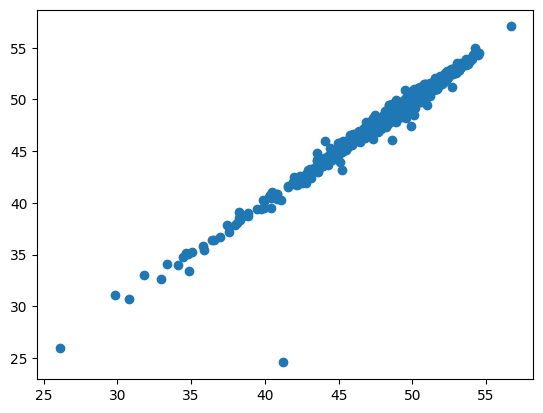

In [ ]:
plt.scatter(y_predFemale, gender_df['twentyThreeFemale']);

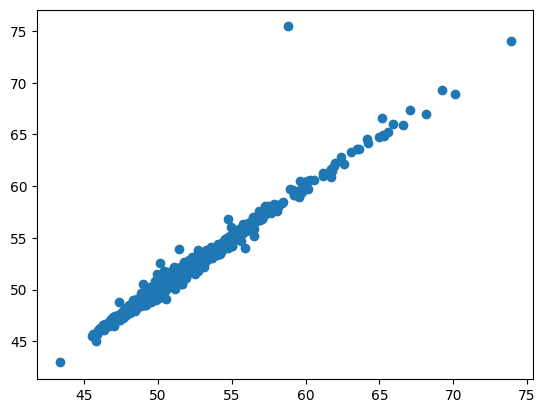

In [ ]:
plt.scatter(y_predMale, gender_df['twentyThreeMale']);

# **Severe Housing Problems**

### **Data**

In [ ]:
rows = worksheet.worksheet("Severe Housing Problems").get_all_values()
#print(rows)

import pandas as pd
houseProblem_df = pd.DataFrame.from_records(rows[1:])
houseProblem_df.columns = rows[0]

def calculate_gender_rate(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
houseProblem_df["eighteen_HousingProblems"]=calculate_gender_rate(houseProblem_df["eighteen_HousingProblems"])
houseProblem_df["nineteen_HousingProblems"]=calculate_gender_rate(houseProblem_df["nineteen_HousingProblems"])
houseProblem_df["twenty_HousingProblems"]=calculate_gender_rate(houseProblem_df["twenty_HousingProblems"])
houseProblem_df["twentyOne_HousingProblems"]=calculate_gender_rate(houseProblem_df["twentyOne_HousingProblems"])
houseProblem_df["twentyTwo_HousingProblems"]=calculate_gender_rate(houseProblem_df["twentyTwo_HousingProblems"])
houseProblem_df["twentyThree_HousingProblems"]=calculate_gender_rate(houseProblem_df["twentyThree_HousingProblems"])

def exclude_state_averages(name):
  return name not in state_abbreviations
houseProblem_df = houseProblem_df[houseProblem_df['County'].apply(exclude_state_averages)]
houseProblem_df["State/county"] = houseProblem_df["County"] + ", " + houseProblem_df["State"]
houseProblem_df

,State,County,eighteen_HousingProblems,nineteen_HousingProblems,twenty_HousingProblems,twentyOne_HousingProblems,twentyTwo_HousingProblems,twentyThree_HousingProblems,twentyFour_HousingProblems,State/county
0,AL,Autauga County,15.2179,14.9546,14.6635,13.6310,14.7289,14.4426,0.153757,"Autauga County, AL"
1,AL,Baldwin County,14.3102,13.8317,13.5662,12.9967,12.4205,12.2390,0.124279,"Baldwin County, AL"
2,AL,Barbour County,15.2542,15.4555,14.5833,13.7106,15.4600,16.2119,0.150751,"Barbour County, AL"
3,AL,Bibb County,12.3588,10.9609,10.4965,9.2552,11.1842,11.3208,0.12259,"Bibb County, AL"
4,AL,Blount County,11.0580,10.4012,10.5480,10.1257,10.4612,9.8825,0.106579,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,9.7093,9.5923,9.8579,11.1862,10.0189,10.3704,0.105246,"Sweetwater County, WY"
3188,WY,Teton County,18.3492,16.1271,16.9679,16.4866,18.2314,15.4102,0.161596,"Teton County, WY"
3189,WY,Uinta County,12.7068,11.1333,11.4401,10.7722,10.5365,8.6899,0.08344,"Uinta County, WY"
3190,WY,Washakie County,10.6936,10.5413,10.0143,10.3152,8.4795,7.2808,0.080058,"Washakie County, WY"


### **Modelling**

In [ ]:
houseProblem_df["eighteen_HousingProblems"]=pd.to_numeric(houseProblem_df["eighteen_HousingProblems"],errors="coerce")
houseProblem_df["nineteen_HousingProblems"]=pd.to_numeric(houseProblem_df["nineteen_HousingProblems"],errors="coerce")
houseProblem_df["twenty_HousingProblems"]=pd.to_numeric(houseProblem_df["twenty_HousingProblems"],errors="coerce")
houseProblem_df["twentyOne_HousingProblems"]=pd.to_numeric(houseProblem_df["twentyOne_HousingProblems"],errors="coerce")
houseProblem_df["twentyTwo_HousingProblems"]=pd.to_numeric(houseProblem_df["twentyTwo_HousingProblems"],errors="coerce")
houseProblem_df["twentyThree_HousingProblems"]=pd.to_numeric(houseProblem_df["twentyThree_HousingProblems"],errors="coerce")
houseProblem_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3143 entries, 0 to 3191
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   State                        3143 non-null   object 
 1   County                       3143 non-null   object 
 2   eighteen_HousingProblems     3143 non-null   float64
 3   nineteen_HousingProblems     3143 non-null   float64
 4   twenty_HousingProblems       3143 non-null   float64
 5   twentyOne_HousingProblems    3143 non-null   float64
 6   twentyTwo_HousingProblems    3143 non-null   float64
 7   twentyThree_HousingProblems  3143 non-null   float64
 8   twentyFour_HousingProblems   3143 non-null   object 
 9   State/county                 3143 non-null   object 
dtypes: float64(6), object(4)
memory usage: 270.1+ KB


In [ ]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

In [ ]:
def metrics(mod):
  return np.round(mod.aic), np.round(mod.llf), np.round(mod.rsquared, 3), np.round(np.mean(np.abs(houseProblem_df[depvar] - mod.fittedvalues)), 3), np.round(mod.fvalue)

In [ ]:
depvar = "twentyThree_HousingProblems"
modHousing = smf.ols(formula=depvar + ' ~ eighteen_HousingProblems + nineteen_HousingProblems + twenty_HousingProblems + twentyOne_HousingProblems + twentyTwo_HousingProblems', data=houseProblem_df)  #C(2018_UnemploymentRate) will assume values are categories
modHousing = modHousing.fit()

In [ ]:
metrics(modHousing)

(np.float64(9992.0),
 np.float64(-4990.0),
 np.float64(0.926),
 np.float64(0.841),
 np.float64(7909.0))

In [ ]:
modHousing.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     twentyThree_HousingProblems   R-squared:                       0.926
Model:                                     OLS   Adj. R-squared:                  0.926
Method:                          Least Squares   F-statistic:                     7909.
Date:                         Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                                 22:01:19   Log-Likelihood:                -4990.0
No. Observations:                         3143   AIC:                             9992.
Df Residuals:                             3137   BIC:                         1.003e+04
Df Model:                                    5                                         
Covariance Type:                     nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.3855      0.070      5.540      0.000       0.249       0.522
eighteen_HousingProblems     -0.0312      0.017     -1.790      0.074      -0.065       0.003
nineteen_HousingProblems     -0.0328      0.025     -1.297      0.195      -0.082       0.017
twenty_HousingProblems        0.0349      0.025      1.420      0.156      -0.013       0.083
twentyOne_HousingProblems     0.0140      0.023      0.610      0.542      -0.031       0.059
twentyTwo_HousingProblems     0.9658      0.018     55.074      0.000       0.931       1.000
==============================================================================
Omnibus:                      374.018   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3638.490
Skew:                           0.123   Prob(JB):                         0.00
Kurtosis:                       8.265   Cond. No.                         108.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# **Food Insecurity**

### **Data**

In [ ]:
rows = worksheet.worksheet("Food Insecurity").get_all_values()

#print(rows)

import pandas as pd
fI_df = pd.DataFrame.from_records(rows[1:])
fI_df.columns = rows[0]
def percentage(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
fI_df["eighteenFoodInsecurity"]=percentage(fI_df["eighteenFoodInsecurity"])
fI_df["nineteenFoodInsecurity"]=percentage(fI_df["nineteenFoodInsecurity"])
fI_df["twentyFoodInsecurity"]=percentage(fI_df["twentyFoodInsecurity"])
fI_df["twentyOneFoodInsecurity"]=percentage(fI_df["twentyOneFoodInsecurity"])
fI_df["twentyTwoFoodInsecurity"]=percentage(fI_df["twentyTwoFoodInsecurity"])
fI_df["twentyThreeFoodInsecurity"]=percentage(fI_df["twentyThreeFoodInsecurity"])
def exclude_state_averages(name):
  return name not in state_abbreviations
fI_df = fI_df[fI_df['County'].apply(exclude_state_averages)]
fI_df["State/county"] = fI_df["County"] + ", " + fI_df["State"]
fI_df

,State,County,eighteenFoodInsecurity,nineteenFoodInsecurity,twentyFoodInsecurity,twentyOneFoodInsecurity,twentyTwoFoodInsecurity,twentyThreeFoodInsecurity,twentyFourFoodInsecurity,State/county
0,AL,Autauga County,13.9,13.4,13.2,15.6,15.7,14.5,0.133,"Autauga County, AL"
1,AL,Baldwin County,13.0,12.3,11.6,12.9,13.4,12.4,0.118,"Baldwin County, AL"
2,AL,Barbour County,23.4,23.2,22.0,21.9,20.7,19.5,0.178,"Barbour County, AL"
3,AL,Bibb County,16.1,15.8,14.3,15.1,16.3,16.4,0.149,"Bibb County, AL"
4,AL,Blount County,11.3,11.0,10.7,13.6,14.5,13.8,0.137,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,10.6,11.1,10.7,11.7,11.3,11.5,0.114,"Sweetwater County, WY"
3188,WY,Teton County,10.2,9.9,9.7,9.5,9.0,9.1,0.084,"Teton County, WY"
3189,WY,Uinta County,12.6,14.1,12.8,13.5,12.6,11.1,0.103,"Uinta County, WY"
3190,WY,Washakie County,11.3,12.0,11.2,12.6,11.6,10.6,0.093,"Washakie County, WY"


### **Modelling**

# **Single Parent Households**

### **Single Parent Households Data Preprocessing**

In [ ]:
rows = worksheet.worksheet("Single Parent Household").get_all_values()

#print(rows)

import pandas as pd
household_size_df = pd.DataFrame.from_records(rows[1:])
household_size_df.columns = rows[0]
def percentage(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
household_size_df["eighteenSingle"]=percentage(household_size_df["eighteenSingle"])
household_size_df["nineteenSingle"]=percentage(household_size_df["nineteenSingle"])
household_size_df["twentySingle"]=percentage(household_size_df["twentySingle"])
household_size_df["twentyOneSingle"]=percentage(household_size_df["twentyOneSingle"])
household_size_df["twentyTwoSingle"]=percentage(household_size_df["twentyTwoSingle"])
household_size_df["twentyThreeSingle"]=percentage(household_size_df["twentyThreeSingle"])
def exclude_state_averages(name):
  return name not in state_abbreviations
household_size_df = household_size_df[household_size_df['County'].apply(exclude_state_averages)]
household_size_df["State/county"] = household_size_df["County"] + ", " + household_size_df["State"]
household_size_df

,State,County,eighteenSingle,nineteenSingle,twentySingle,twentyOneSingle,twentyTwoSingle,twentyThreeSingle,twentyFourSingle,State/county
0,AL,Autauga County,24.4714,24.7001,26.2427,24.7406,27.6040,26.7662,0.227025,"Autauga County, AL"
1,AL,Baldwin County,25.8114,25.1841,24.1396,22.3723,18.3638,18.6992,0.190513,"Baldwin County, AL"
2,AL,Barbour County,56.3015,57.2157,56.6034,51.0081,54.0406,54.0772,0.506605,"Barbour County, AL"
3,AL,Bibb County,31.4280,29.5654,28.6892,30.6149,36.7041,29.4440,0.307134,"Bibb County, AL"
4,AL,Blount County,27.2942,29.5697,28.5618,22.4574,22.5584,22.1799,0.229695,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,26.4560,23.4619,22.6856,16.1996,15.7228,16.3417,0.155261,"Sweetwater County, WY"
3188,WY,Teton County,26.3494,24.0426,25.3202,15.7728,18.5105,18.9993,0.157613,"Teton County, WY"
3189,WY,Uinta County,22.0303,21.6457,27.9049,10.1535,10.7885,9.9161,0.101439,"Uinta County, WY"
3190,WY,Washakie County,29.1190,26.6296,17.4473,19.4995,15.9215,12.8430,0.09356,"Washakie County, WY"


### **Single Parent Households Modeling**

In [ ]:
#Assign data according to importance of year, linear model will fit weights to adjust for it
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

In [ ]:
def metrics(mod):
  return np.round(mod.aic), np.round(mod.llf), np.round(mod.rsquared, 3), np.round(np.mean(np.abs(pov_pop[depvar] - mod.fittedvalues)), 3), np.round(mod.fvalue)

In [ ]:
household_size_df = household_size_df.rename(columns={"2018_Single":"eighteenSingle", "2019_Single":"nineteenSingle", "2020_Single":"twentySingle", "2021_Single":"twentyOneSingle", "2022_Single":"twentyTwoSingle", "2023_Single":"twentyThreeSingle"})

In [ ]:
household_size_df

,State,County,eighteenSingle,nineteenSingle,twentySingle,twentyOneSingle,twentyTwoSingle,twentyThreeSingle,twentyFourSingle,State/county
0,AL,Autauga County,24.4714,24.7001,26.2427,24.7406,27.6040,26.7662,0.227025,"Autauga County, AL"
1,AL,Baldwin County,25.8114,25.1841,24.1396,22.3723,18.3638,18.6992,0.190513,"Baldwin County, AL"
2,AL,Barbour County,56.3015,57.2157,56.6034,51.0081,54.0406,54.0772,0.506605,"Barbour County, AL"
3,AL,Bibb County,31.4280,29.5654,28.6892,30.6149,36.7041,29.4440,0.307134,"Bibb County, AL"
4,AL,Blount County,27.2942,29.5697,28.5618,22.4574,22.5584,22.1799,0.229695,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,26.4560,23.4619,22.6856,16.1996,15.7228,16.3417,0.155261,"Sweetwater County, WY"
3188,WY,Teton County,26.3494,24.0426,25.3202,15.7728,18.5105,18.9993,0.157613,"Teton County, WY"
3189,WY,Uinta County,22.0303,21.6457,27.9049,10.1535,10.7885,9.9161,0.101439,"Uinta County, WY"
3190,WY,Washakie County,29.1190,26.6296,17.4473,19.4995,15.9215,12.8430,0.09356,"Washakie County, WY"


In [ ]:
depvar = "twentyThreeSingle"
single1 = smf.ols(formula=depvar + ' ~ eighteenSingle + nineteenSingle + twentySingle + twentyOneSingle + twentyTwoSingle', data=household_size_df)  #C(2018_UnemploymentRate) will assume values are categories
single1 = single1.fit()

In [ ]:
single1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      twentyThreeSingle   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     5677.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:01:21   Log-Likelihood:                -8121.9
No. Observations:                3143   AIC:                         1.626e+04
Df Residuals:                    3137   BIC:                         1.629e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.5036      0.197      2.551      0.011       0.117       0.891
eighteenSingle      0.0200      0.018      1.084      0.278      -0.016       0.056
nineteenSingle     -0.0302      0.021     -1.450      0.147      -0.071       0.011
twentySingle        0.0492      0.011      4.431      0.000       0.027       0.071
twentyOneSingle     0.0174      0.018      0.968      0.333      -0.018       0.053
twentyTwoSingle     0.9062      0.016     58.042      0.000       0.876       0.937
==============================================================================
Omnibus:                      459.222   Durbin-Watson:                   2.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4895.890
Skew:                           0.323   Prob(JB):                         0.00
Kurtosis:                       9.080   Cond. No.                         239.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y_pred = single1.fittedvalues
y_pred

,0
0,26.983393
1,18.477126
2,52.545340
3,35.444962
4,22.394437
...,...
3187,15.969694
3188,18.598404
3189,11.615641
3190,15.907311


In [ ]:
'''import pandas as pd

house_dfs = pd.DataFrame(household_size_df["twentyThreeSingle"])
preds=pd.DataFrame(y_pred)
preds["twentyThreeSingle"] = preds[0]

meree = house_dfs.merge(preds["twentyThreeSingle"], on = "twentyThreeSingle", how="outer")
meree[meree.isna().any(axis=1)]'''

'import pandas as pd\n\nhouse_dfs = pd.DataFrame(household_size_df["twentyThreeSingle"])\npreds=pd.DataFrame(y_pred)\npreds["twentyThreeSingle"] = preds[0]\n\nmeree = house_dfs.merge(preds["twentyThreeSingle"], on = "twentyThreeSingle", how="outer")\nmeree[meree.isna().any(axis=1)]'

In [ ]:
'''plt.scatter(y_pred, household_size_df['twentyThreeSingle']);'''

"plt.scatter(y_pred, household_size_df['twentyThreeSingle']);"

# **Obesity**

### **Data**

In [ ]:
rows = worksheet.worksheet("Obesity").get_all_values()

#print(rows)
import pandas as pd
obesity_df = pd.DataFrame.from_records(rows[1:])
obesity_df.columns = rows[0]
def percentage(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
obesity_df["eighteenObesity"]=percentage(obesity_df["eighteenObesity"])
obesity_df["nineteenObesity"]=percentage(obesity_df["nineteenObesity"])
obesity_df["twentyObesity"]=percentage(obesity_df["twentyObesity"])
obesity_df["twentyOneObesity"]=percentage(obesity_df["twentyOneObesity"])
obesity_df["twentyTwoObesity"]=percentage(obesity_df["twentyTwoObesity"])
obesity_df["twentyThreeObesity"]=percentage(obesity_df["twentyThreeObesity"])
def exclude_state_averages(name):
  return name not in state_abbreviations
obesity_df = obesity_df[obesity_df['County'].apply(exclude_state_averages)]
def replace_parish(county_name):
    county_name = re.sub(r'\bpar(is|i|)\b', 'Parish', county_name, flags=re.IGNORECASE)
    county_name = re.sub(r'\bbor(ough|o|)\b', 'Borough', county_name, flags=re.IGNORECASE)
    county_name = re.sub(r'\bcensus\s*area\b', 'Census Area', county_name, flags=re.IGNORECASE)
    return county_name
obesity_df['County'] = obesity_df['County'].apply(replace_parish)
obesity_df["State/county"] = obesity_df["County"] + ", " + obesity_df["State"]
obesity_df

,State,County,eighteenObesity,nineteenObesity,twentyObesity,twentyOneObesity,twentyTwoObesity,twentyThreeObesity,twentyFourObesity,State/county
0,AL,Autauga County,36.4,37.5,33.3,33.0,35.3,37.3,0.389,"Autauga County, AL"
1,AL,Baldwin County,29.3,31.0,31.0,30.0,29.6,32.6,0.372,"Baldwin County, AL"
2,AL,Barbour County,44.2,44.3,41.7,41.2,40.4,46.4,0.434,"Barbour County, AL"
3,AL,Bibb County,38.4,37.8,37.6,37.4,41.2,38.4,0.396,"Bibb County, AL"
4,AL,Blount County,35.8,34.4,33.8,33.0,38.7,32.7,0.377,"Blount County, AL"
...,...,...,...,...,...,...,...,...,...,...
3187,WY,Sweetwater County,31.1,30.2,29.8,30.3,33.5,33.0,0.343,"Sweetwater County, WY"
3188,WY,Teton County,13.3,13.6,12.4,11.0,22.2,19.9,0.217,"Teton County, WY"
3189,WY,Uinta County,32.2,31.8,35.8,35.2,29.8,34.6,0.333,"Uinta County, WY"
3190,WY,Washakie County,27.1,29.7,28.8,29.2,28.9,30.1,0.336,"Washakie County, WY"


### **Data**

# **Uninsurance**

### **Single Parent Households Data Preprocessing**

In [ ]:
rows = worksheet.worksheet("Uninsured").get_all_values()
#print(rows)

import pandas as pd
uninsured_df = pd.DataFrame.from_records(rows[1:])
uninsured_df.columns = rows[0]
def percentage(row):
  row = pd.to_numeric(row, errors="coerce")
  return row * 100
uninsured_df["eighteenUnin"]=percentage(uninsured_df["eighteenUnin"])
uninsured_df["nineteenUnin"]=percentage(uninsured_df["nineteenUnin"])
uninsured_df["twentyUnin"]=percentage(uninsured_df["twentyUnin"])
uninsured_df["twentyOneUnin"]=percentage(uninsured_df["twentyOneUnin"])
uninsured_df["twentyTwoUnin"]=percentage(uninsured_df["twentyTwoUnin"])
uninsured_df["twentyThreeUnin"]=percentage(uninsured_df["twentyThreeUnin"])
def exclude_state_averages(name):
  return name not in state_abbreviations
uninsured_df = uninsured_df[uninsured_df['County'].apply(exclude_state_averages)]
uninsured_df["State/county"] = uninsured_df["County"] + ", " + uninsured_df["State"]
columns = ["eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin","State/county"]
uninsured_df = uninsured_df[columns]
uninsured_df

,eighteenUnin,nineteenUnin,twentyUnin,twentyOneUnin,twentyTwoUnin,twentyThreeUnin,State/county
0,11.8981,10.7718,11.0448,10.0473,11.5995,9.0105,"Autauga County, AL"
1,9.3877,8.5010,8.7217,13.1690,9.3512,9.4451,"Baldwin County, AL"
2,11.5244,10.6993,11.3334,13.5040,10.9068,12.1044,"Barbour County, AL"
3,13.3105,12.5132,12.2428,10.5991,12.9915,10.9823,"Bibb County, AL"
4,11.8559,9.6801,10.2063,14.1160,10.9932,11.4674,"Blount County, AL"
...,...,...,...,...,...,...,...
3187,12.8673,13.6450,14.6015,11.4610,15.3021,11.8980,"Sweetwater County, WY"
3188,12.3717,12.7509,14.4650,13.3664,13.8644,12.2438,"Teton County, WY"
3189,15.2977,14.9793,16.0345,11.8385,17.4560,11.8673,"Uinta County, WY"
3190,12.3173,12.5690,13.6647,14.8343,14.0600,13.5042,"Washakie County, WY"


### **Uninsured Modeling**

# **Merged Dataset**

### **Data**

In [ ]:
merge2 = graduation_df.merge(obesity_df, on="State/county", how="outer")
merge3 = merge2.merge(uninsured_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin","State/county"]
merge3=merge3[keep]
merge4 = merge3.merge(fI_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity","State/county"]
merge4 = merge4[keep]
merge5 = merge4.merge(household_size_df, on="State/county", how="outer")
'''
duplicates_in_A = merge5.duplicated(subset=["State/county"])

num_duplicates_A = duplicates_in_A.sum()

duplicate_rows_A = merge5[duplicates_in_A]
df_no_duplicates = merge5.drop_duplicates(subset=["State/county"], keep='first')
df_no_duplicates
'''
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity", "eighteenSingle",	"nineteenSingle",	"twentySingle",	"twentyOneSingle",	"twentyTwoSingle",	"twentyThreeSingle","State/county"]
merge5 = merge5[keep]
merge6 = merge5.merge(houseProblem_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity", "eighteenSingle",	"nineteenSingle",	"twentySingle",	"twentyOneSingle",	"twentyTwoSingle",	"twentyThreeSingle", "eighteen_HousingProblems",	"nineteen_HousingProblems",	"twenty_HousingProblems",	"twentyOne_HousingProblems",	"twentyTwo_HousingProblems",	"twentyThree_HousingProblems", "State/county"]
merge6 = merge6[keep]
merge7 = merge6.merge(age_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity", "eighteenSingle",	"nineteenSingle",	"twentySingle",	"twentyOneSingle",	"twentyTwoSingle",	"twentyThreeSingle", "eighteen_HousingProblems",	"nineteen_HousingProblems",	"twenty_HousingProblems",	"twentyOne_HousingProblems",	"twentyTwo_HousingProblems",	"twentyThree_HousingProblems", "State/county", "eighteen_Elder",	"nineteen_Elder",	"twenty_Elder",	"twentyOne_Elder",	"twentyTwo_Elder",	"twentyThree_Elder"]
merge7 = merge7[keep]
merge8 = merge7.merge(gender_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity", "eighteenSingle",	"nineteenSingle",	"twentySingle",	"twentyOneSingle",	"twentyTwoSingle",	"twentyThreeSingle", "eighteen_HousingProblems",	"nineteen_HousingProblems",	"twenty_HousingProblems",	"twentyOne_HousingProblems",	"twentyTwo_HousingProblems",	"twentyThree_HousingProblems", "State/county", "eighteen_Elder",	"nineteen_Elder",	"twenty_Elder",	"twentyOne_Elder",	"twentyTwo_Elder",	"twentyThree_Elder", "eighteenFemale", "nineteenFemale", "twentyFemale",	"twentyOneFemale",	"twentyTwoFemale",	"twentyThreeFemale",	"eighteenMale",	"nineteenMale",	"twentyMale",	"twentyOneMale",	"twentyTwoMale",	"twentyThreeMale"]
merge8 = merge8[keep]
merge9 = merge8.merge(population_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity", "eighteenSingle",	"nineteenSingle",	"twentySingle",	"twentyOneSingle",	"twentyTwoSingle",	"twentyThreeSingle", "eighteen_HousingProblems",	"nineteen_HousingProblems",	"twenty_HousingProblems",	"twentyOne_HousingProblems",	"twentyTwo_HousingProblems",	"twentyThree_HousingProblems", "State/county", "eighteen_Elder",	"nineteen_Elder",	"twenty_Elder",	"twentyOne_Elder",	"twentyTwo_Elder",	"twentyThree_Elder", "eighteenFemale", "nineteenFemale", "twentyFemale",	"twentyOneFemale",	"twentyTwoFemale",	"twentyThreeFemale",	"eighteenMale",	"nineteenMale",	"twentyMale",	"twentyOneMale",	"twentyTwoMale",	"twentyThreeMale", "eighteenPopulation",	"nineteenPopulation",	"twentyPopulation",	"twentyOnePopulation",	"twentyTwoPopulation",	"twentyThreePopulation"]
merge9 = merge9[keep]
merge10 = merge9.merge(unnemployment_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity", "eighteenSingle",	"nineteenSingle",	"twentySingle",	"twentyOneSingle",	"twentyTwoSingle",	"twentyThreeSingle", "eighteen_HousingProblems",	"nineteen_HousingProblems",	"twenty_HousingProblems",	"twentyOne_HousingProblems",	"twentyTwo_HousingProblems",	"twentyThree_HousingProblems", "State/county", "eighteen_Elder",	"nineteen_Elder",	"twenty_Elder",	"twentyOne_Elder",	"twentyTwo_Elder",	"twentyThree_Elder", "eighteenFemale", "nineteenFemale", "twentyFemale",	"twentyOneFemale",	"twentyTwoFemale",	"twentyThreeFemale",	"eighteenMale",	"nineteenMale",	"twentyMale",	"twentyOneMale",	"twentyTwoMale",	"twentyThreeMale", "eighteenPopulation",	"nineteenPopulation",	"twentyPopulation",	"twentyOnePopulation",	"twentyTwoPopulation",	"twentyThreePopulation", "eighteenUnemployment",	"nineteenUnemployment",	"twentyUnemployment",	"twentyOneUnemployment",	"twentyTwoUnemployment",	"twentyThreeUnemployment"]
merge10 = merge10[keep]
merge11 = merge10.merge(poverty_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity", "eighteenSingle",	"nineteenSingle",	"twentySingle",	"twentyOneSingle",	"twentyTwoSingle",	"twentyThreeSingle", "eighteen_HousingProblems",	"nineteen_HousingProblems",	"twenty_HousingProblems",	"twentyOne_HousingProblems",	"twentyTwo_HousingProblems",	"twentyThree_HousingProblems", "State/county", "eighteen_Elder",	"nineteen_Elder",	"twenty_Elder",	"twentyOne_Elder",	"twentyTwo_Elder",	"twentyThree_Elder", "eighteenFemale", "nineteenFemale", "twentyFemale",	"twentyOneFemale",	"twentyTwoFemale",	"twentyThreeFemale",	"eighteenMale",	"nineteenMale",	"twentyMale",	"twentyOneMale",	"twentyTwoMale",	"twentyThreeMale", "eighteenPopulation",	"nineteenPopulation",	"twentyPopulation",	"twentyOnePopulation",	"twentyTwoPopulation",	"twentyThreePopulation", "eighteenUnemployment",	"nineteenUnemployment",	"twentyUnemployment",	"twentyOneUnemployment",	"twentyTwoUnemployment",	"twentyThreeUnemployment", "eighteenPoverty", "nineteenPoverty", "twentyPoverty", "twentyOnePoverty", "twentyTwoPoverty", "twentyThreePoverty", "State", "County"]
merge11 = merge11[keep]
merge12 = merge11.merge(hhi_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity", "eighteenSingle",	"nineteenSingle",	"twentySingle",	"twentyOneSingle",	"twentyTwoSingle",	"twentyThreeSingle", "eighteen_HousingProblems",	"nineteen_HousingProblems",	"twenty_HousingProblems",	"twentyOne_HousingProblems",	"twentyTwo_HousingProblems",	"twentyThree_HousingProblems", "State/county", "eighteen_Elder",	"nineteen_Elder",	"twenty_Elder",	"twentyOne_Elder",	"twentyTwo_Elder",	"twentyThree_Elder", "eighteenFemale", "nineteenFemale", "twentyFemale",	"twentyOneFemale",	"twentyTwoFemale",	"twentyThreeFemale",	"eighteenMale",	"nineteenMale",	"twentyMale",	"twentyOneMale",	"twentyTwoMale",	"twentyThreeMale", "eighteenPopulation",	"nineteenPopulation",	"twentyPopulation",	"twentyOnePopulation",	"twentyTwoPopulation",	"twentyThreePopulation", "eighteenUnemployment",	"nineteenUnemployment",	"twentyUnemployment",	"twentyOneUnemployment",	"twentyTwoUnemployment",	"twentyThreeUnemployment", "eighteenPoverty", "nineteenPoverty", "twentyPoverty", "twentyOnePoverty", "twentyTwoPoverty", "twentyThreePoverty","eighteenHHI", "nineteenHHI", "twentyHHI", "twentyOneHHI", "twentyTwoHHI", "twentyThreeHHI", "State", "County"]
merge12 = merge12[keep]
merge13 = merge12.merge(food_env_df, on="State/county", how="outer")
keep = ["eighteenCollege", "nineteenCollege", "twentyCollege", "twentyOneCollege", "twentyTwoCollege", "twentyThreeCollege", "eighteenObesity", "nineteenObesity", "twentyObesity", "twentyOneObesity", "twentyTwoObesity", "twentyThreeObesity", "eighteenUnin","nineteenUnin","twentyUnin","twentyOneUnin","twentyTwoUnin","twentyThreeUnin", "eighteenFoodInsecurity",	"nineteenFoodInsecurity",	"twentyFoodInsecurity",	"twentyOneFoodInsecurity",	"twentyTwoFoodInsecurity",	"twentyThreeFoodInsecurity", "eighteenSingle",	"nineteenSingle",	"twentySingle",	"twentyOneSingle",	"twentyTwoSingle",	"twentyThreeSingle", "eighteen_HousingProblems",	"nineteen_HousingProblems",	"twenty_HousingProblems",	"twentyOne_HousingProblems",	"twentyTwo_HousingProblems",	"twentyThree_HousingProblems", "State/county", "eighteen_Elder",	"nineteen_Elder",	"twenty_Elder",	"twentyOne_Elder",	"twentyTwo_Elder",	"twentyThree_Elder", "eighteenFemale", "nineteenFemale", "twentyFemale",	"twentyOneFemale",	"twentyTwoFemale",	"twentyThreeFemale",	"eighteenMale",	"nineteenMale",	"twentyMale",	"twentyOneMale",	"twentyTwoMale",	"twentyThreeMale", "eighteenPopulation",	"nineteenPopulation",	"twentyPopulation",	"twentyOnePopulation",	"twentyTwoPopulation",	"twentyThreePopulation", "eighteenUnemployment",	"nineteenUnemployment",	"twentyUnemployment",	"twentyOneUnemployment",	"twentyTwoUnemployment",	"twentyThreeUnemployment", "eighteenPoverty", "nineteenPoverty", "twentyPoverty", "twentyOnePoverty", "twentyTwoPoverty", "twentyThreePoverty","eighteenHHI", "nineteenHHI", "twentyHHI", "twentyOneHHI", "twentyTwoHHI", "twentyThreeHHI", 'eighteenFoodEnvIndex', 'nineteenFoodEnvIndex',
       'twentyFoodEnvIndex','twentyOneFoodEnvIndex', 'twentyTwoFoodEnvIndex',
       'twentyThreeFoodEnvIndex']
merge13 = merge13[keep]
merge13.iloc[636:637]["State/county"]

,State/county
636,"Corson County, SD"


In [ ]:
dups = merge13.duplicated(subset=["State/county"])

# Step 2: Sum the number of duplicates
num = dups.sum()

# Step 3: View the rows with duplicates in column 'A'
rows = merge13[dups]
df = merge13.drop_duplicates(subset=["State/county"], keep='first')
df[df.isna().any(axis=1)]


,eighteenCollege,nineteenCollege,twentyCollege,twentyOneCollege,twentyTwoCollege,twentyThreeCollege,eighteenObesity,nineteenObesity,twentyObesity,twentyOneObesity,...,twentyHHI,twentyOneHHI,twentyTwoHHI,twentyThreeHHI,eighteenFoodEnvIndex,nineteenFoodEnvIndex,twentyFoodEnvIndex,twentyOneFoodEnvIndex,twentyTwoFoodEnvIndex,twentyThreeFoodEnvIndex


# **Visualizations**

# **ARIMA**

In [ ]:
years = ['eighteen', 'nineteen', 'twenty', 'twentyOne', 'twentyTwo', 'twentyThree']

df_long = pd.DataFrame()

for year in years:
    temp_df = df[[
        'State/county',
        f'{year}College',
        f'{year}Obesity',
        f'{year}Unin',
        f'{year}Single',
        f'{year}_HousingProblems',
        f'{year}_Elder',
        f'{year}Female',
        f'{year}Population',
        f'{year}Unemployment',
        f'{year}FoodInsecurity',
        f'{year}Poverty',
        f'{year}HHI',
        f'{year}FoodEnvIndex'
    ]]
    if year == "eighteen":
      temp_df['Year'] = year.replace('eighteen',"2018")
    elif year == "nineteen":
      temp_df['Year'] = year.replace('nineteen',"2019")
    elif year == "twenty":
      temp_df['Year'] = year.replace('twenty',"2020")
    elif year == "twentyOne":
      temp_df['Year'] = year.replace('twentyOne',"2021")
    elif year == "twentyTwo":
      temp_df['Year'] = year.replace('twentyTwo',"2022")
    else:
      temp_df['Year'] = year.replace('twentyThree',"2023")
    temp_df.rename(columns={
        f'{year}College': 'CollegeGraduation',
        f'{year}Obesity': 'ObesityRate',
        f'{year}Unin': 'UninsuredRate',
        f'{year}Single': 'SingleParentHouseholds',
        f'{year}_HousingProblems': 'HousingProblems',
        f'{year}_Elder': 'ElderlyPopulation',
        f'{year}Female': 'FemalePopulation',
        f'{year}Poverty': 'PovertyRate',
        f'{year}Population': 'TotalPopulation',
        f'{year}Unemployment': 'UnemploymentRate',
        f'{year}FoodInsecurity': 'FoodInsecurity',
        f'{year}HHI':"Median Household Income",
        f'{year}FoodEnvIndex':"Food Environment Index"
    }, inplace=True)
    df_long = pd.concat([df_long, temp_df], ignore_index=True)
df_long["Year"] = pd.to_numeric(df_long["Year"])
df_long[df_long.isna().any(axis=1)]
df_long = df_long.dropna()
df_long2 = df_long[::-1]
df_long

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Median Household Income,Food Environment Index,Year
0,"Abbeville County, SC",49.0200,37.8,13.0159,39.1370,14.6667,20.4889,51.5479,24872,5.3097,16.4,24.6,42412,7.7,2018
1,"Acadia Parish, LA",42.2936,33.8,13.7833,36.9925,13.7999,14.2422,51.4119,62645,7.4212,15.3,29.3,40484,7.9,2018
2,"Accomack County, VA",43.4801,36.2,10.3580,41.9071,15.6053,22.2782,51.2884,32947,4.8168,14.2,31.8,42879,8.0,2018
3,"Ada County, ID",74.5047,25.6,12.8217,26.1603,15.5398,13.5982,49.8719,444028,3.3263,13.4,11.3,66827,7.9,2018
4,"Adair County, IA",64.7295,32.9,5.8598,34.8731,8.9231,22.8144,50.6345,7092,3.0410,11.1,15.4,54282,8.6,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18847,"Yuma County, AZ",54.9942,40.5,15.3857,30.9170,18.9056,19.5995,48.1574,206990,12.9167,16.2,25.0,61225,6.5,2023
18848,"Yuma County, CO",61.6456,27.5,15.0362,19.5820,14.0199,18.5494,49.3713,9941,2.7347,8.1,18.2,61870,8.6,2023
18849,"Zapata County, TX",36.9616,43.7,26.1543,23.4020,23.6404,13.1219,50.0360,13908,12.0636,21.4,44.6,41688,5.6,2023
18850,"Zavala County, TX",54.5965,46.5,20.1470,60.9148,18.6275,14.3172,48.8253,9534,12.6679,22.8,38.8,36878,3.9,2023


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

df_long.iloc[3460]

,3460
State/county,"Burlington County, NJ"
CollegeGraduation,72.5829
ObesityRate,28.1
UninsuredRate,8.4572
SingleParentHouseholds,26.2585
HousingProblems,16.3367
ElderlyPopulation,16.6546
FemalePopulation,50.8297
TotalPopulation,448596
UnemploymentRate,4.0981


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

train = df_long[df_long['Year'] < 2023].copy()
test = df_long[df_long['Year'] == 2023].copy()

required_exog_vars = ['CollegeGraduation', 'ObesityRate', "Median Household Income", "Food Environment Index", 'UninsuredRate', 'PovertyRate', 'SingleParentHouseholds', 'HousingProblems', 'ElderlyPopulation', 'FemalePopulation', 'TotalPopulation', 'UnemploymentRate']
test_exog = test[required_exog_vars]

def adf_test(series):
    result = adfuller(series)
    print("Test-statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print('Stationary')
        return 0
    else:
        print('Non-stationary')
        return 1

d = adf_test(train['PovertyRate'])

if d == 1:
    train['PovertyRate'] = train['PovertyRate'].diff().dropna()
    d = adf_test(train[''])

Test-statistic: -13.754435137495108
p-value: 1.0359701407703385e-25
Stationary


In [ ]:
test

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Median Household Income,Food Environment Index,Year
15710,"Abbeville County, SC",52.5239,38.5,13.2828,36.9103,13.7681,22.9228,51.3601,24299,4.5421,11.3,21.2,51580,7.6,2023
15711,"Acadia Parish, LA",42.4158,38.3,8.2561,31.7280,12.5928,16.1744,50.8414,57288,4.9451,17.3,28.7,43133,7.0,2023
15712,"Accomack County, VA",44.3686,38.3,11.5873,37.0241,13.4301,25.2121,50.9264,33246,4.3490,11.8,25.7,56039,8.3,2023
15713,"Ada County, ID",74.9553,27.7,6.4689,18.4134,12.8897,15.5667,49.6598,511931,3.2577,7.8,9.1,90513,8.6,2023
15714,"Adair County, IA",61.2553,35.8,4.6101,17.4489,9.3750,22.1854,49.5160,7541,3.0880,8.9,13.8,67873,8.8,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18847,"Yuma County, AZ",54.9942,40.5,15.3857,30.9170,18.9056,19.5995,48.1574,206990,12.9167,16.2,25.0,61225,6.5,2023
18848,"Yuma County, CO",61.6456,27.5,15.0362,19.5820,14.0199,18.5494,49.3713,9941,2.7347,8.1,18.2,61870,8.6,2023
18849,"Zapata County, TX",36.9616,43.7,26.1543,23.4020,23.6404,13.1219,50.0360,13908,12.0636,21.4,44.6,41688,5.6,2023
18850,"Zavala County, TX",54.5965,46.5,20.1470,60.9148,18.6275,14.3172,48.8253,9534,12.6679,22.8,38.8,36878,3.9,2023


PACF for CollegeGraduation
ACF for CollegeGraduation
PACF for ObesityRate
ACF for ObesityRate
PACF for Median Household Income
ACF for Median Household Income
PACF for Food Environment Index
ACF for Food Environment Index
PACF for UninsuredRate
ACF for UninsuredRate
PACF for PovertyRate
ACF for PovertyRate
PACF for SingleParentHouseholds
ACF for SingleParentHouseholds
PACF for HousingProblems
ACF for HousingProblems
PACF for ElderlyPopulation
ACF for ElderlyPopulation
PACF for FemalePopulation
ACF for FemalePopulation
PACF for TotalPopulation
ACF for TotalPopulation
PACF for UnemploymentRate
ACF for UnemploymentRate


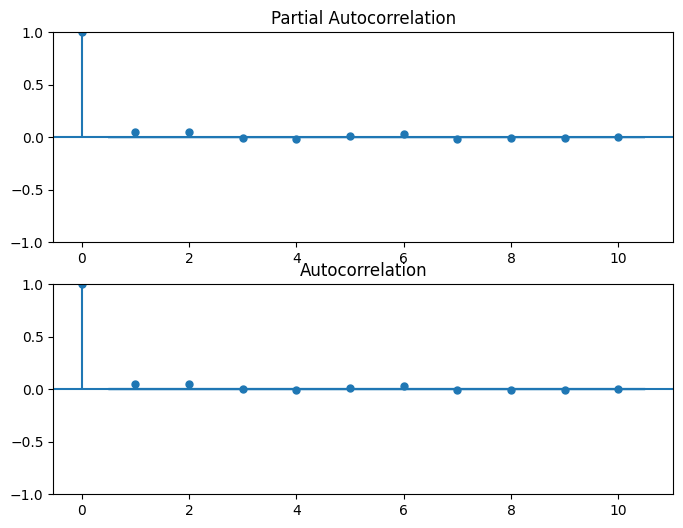

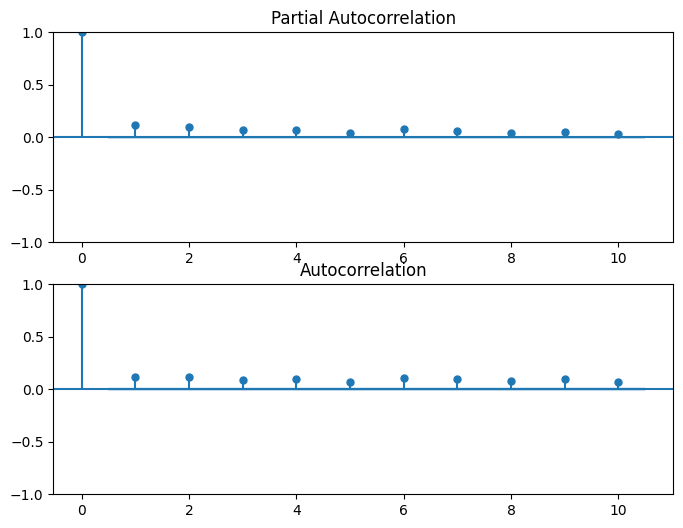

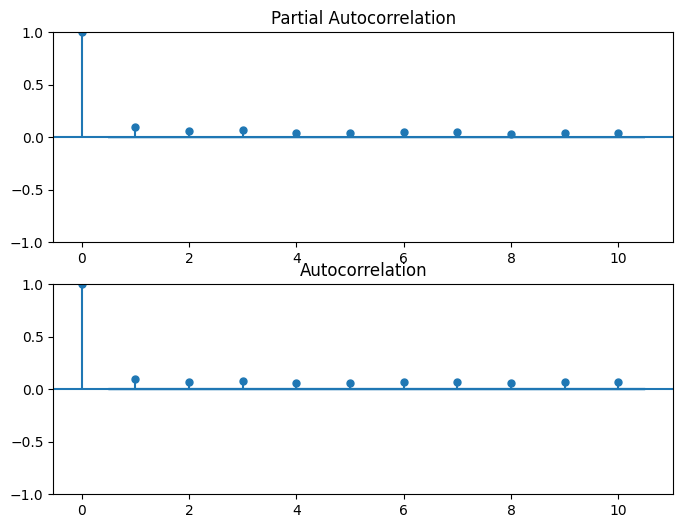

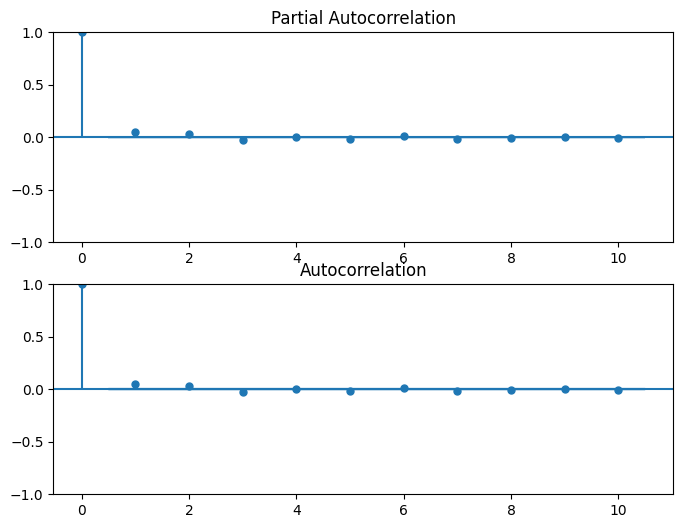

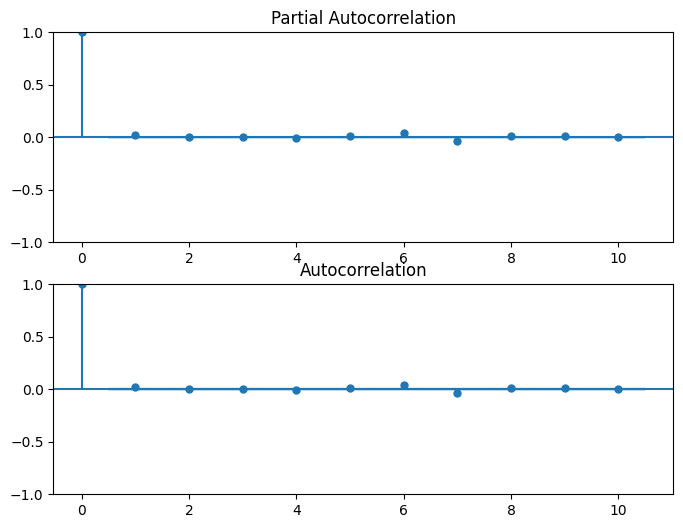

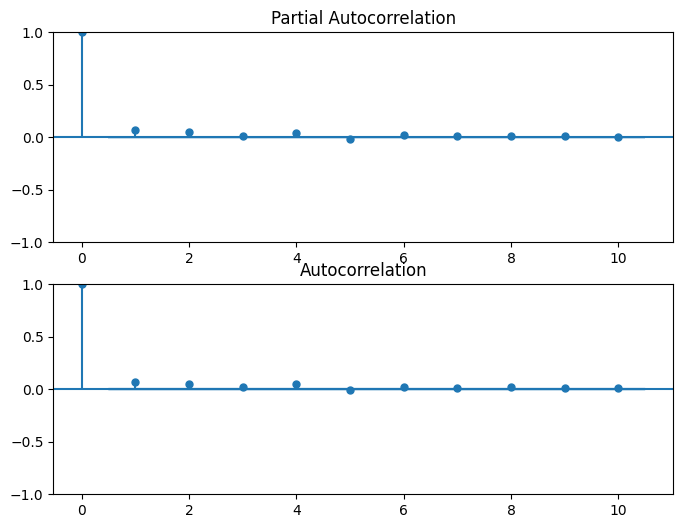

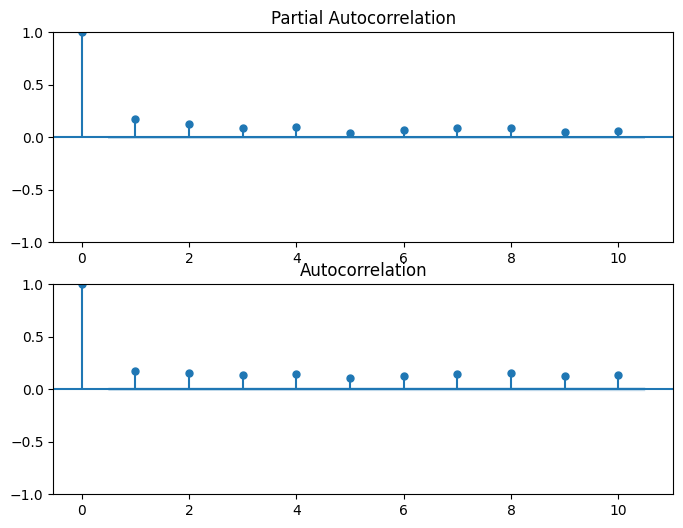

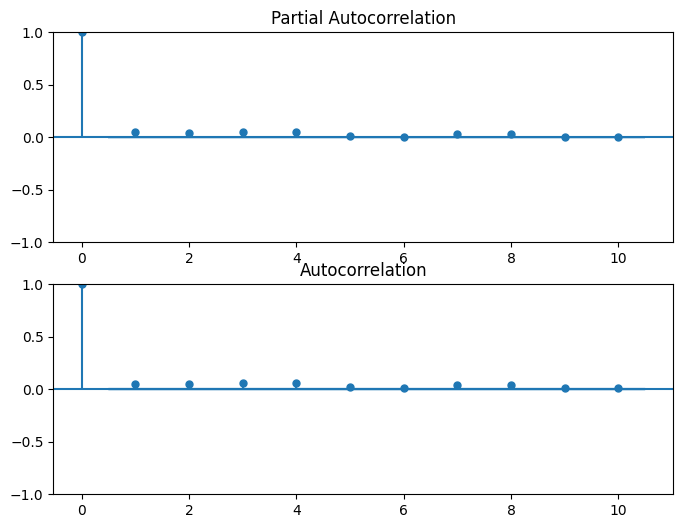

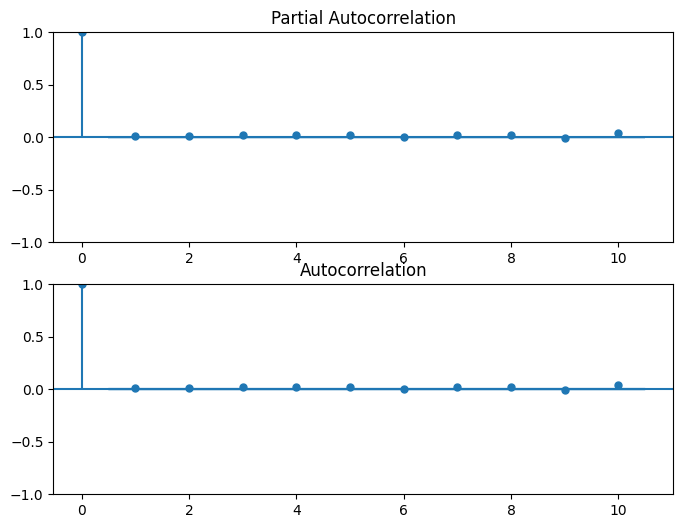

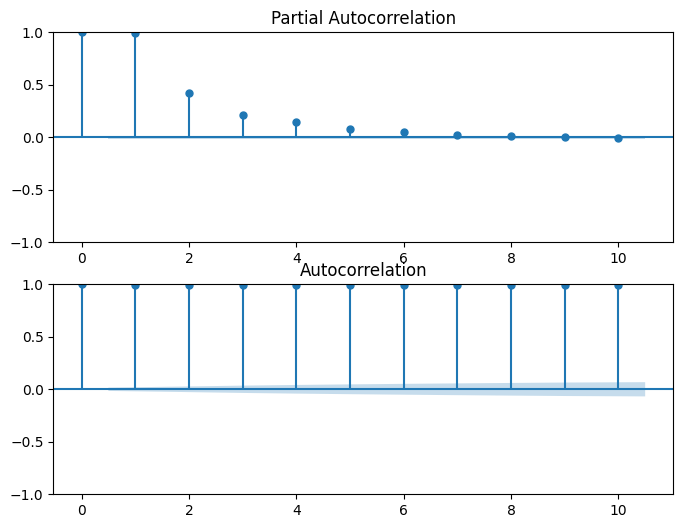

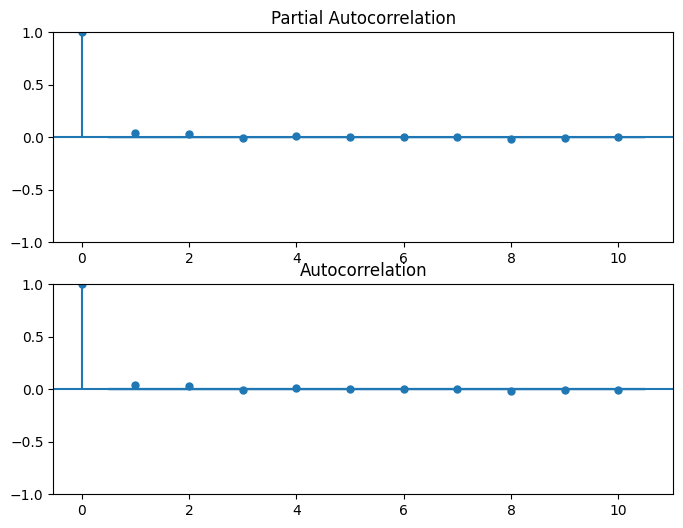

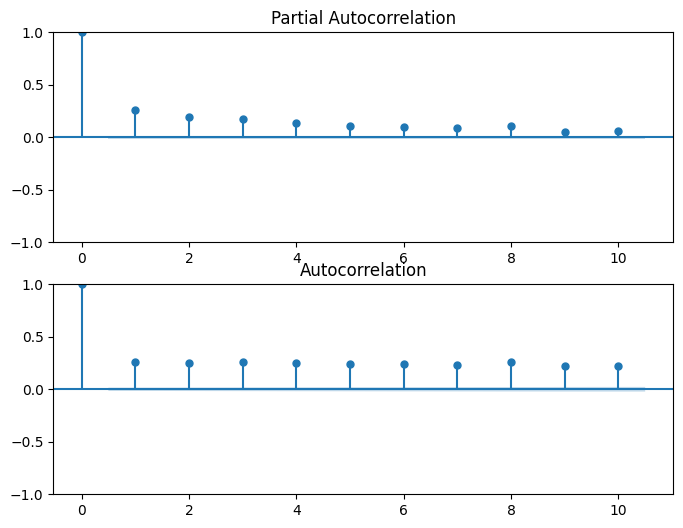

In [ ]:
for i in required_exog_vars:
  fig,ax = plt.subplots(2,1, figsize=(8,6))
  print(f"PACF for {i}")
  plot_pacf(train[i], lags = 10, ax = ax[0]);
  print(f"ACF for {i}")
  plot_acf(train[i], lags =10, ax = ax[1]);

In [ ]:
model = ARIMA(train['FoodInsecurity'], order=(1, d, 1), exog=train[required_exog_vars])
result = model.fit()

In [ ]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:         FoodInsecurity   No. Observations:                15710
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -33095.544
Date:                Sat, 04 Apr 2026   AIC                          66223.087
Time:                        22:02:00   BIC                          66345.680
Sample:                             0   HQIC                         66263.670
                              - 15710                                         
Covariance Type:                  opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      16.7907      0.255     65.786      0.000      16.290      17.291
CollegeGraduation           0.0068      0.002      4.498      0.000       0.004       0.010
ObesityRate                 0.0566      0.003     17.516      0.000       0.050       0.063
Median Household Income -1.422e-05   1.24e-06    -11.462      0.000   -1.67e-05   -1.18e-05
Food Environment Index     -1.4111      0.012   -121.116      0.000      -1.434      -1.388
UninsuredRate               0.0365      0.003     11.411      0.000       0.030       0.043
PovertyRate                 0.1415      0.003     53.504      0.000       0.136       0.147
SingleParentHouseholds      0.0496      0.002     31.051      0.000       0.046       0.053
HousingProblems             0.0427      0.003     12.630      0.000       0.036       0.049
ElderlyPopulation          -0.0362      0.003    -10.830      0.000      -0.043      -0.030
FemalePopulation         7.407e-05   1.02e-05      7.261      0.000    5.41e-05    9.41e-05
TotalPopulation         -4.093e-08    6.6e-08     -0.620      0.535    -1.7e-07    8.85e-08
UnemploymentRate            0.1959      0.008     25.980      0.000       0.181       0.211
ar.L1                       0.4316      0.132      3.280      0.001       0.174       0.689
ma.L1                      -0.3856      0.134     -2.875      0.004      -0.648      -0.123
sigma2                      3.9581      0.032    122.683      0.000       3.895       4.021
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              8315.63
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.73   Skew:                            -0.77
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
forecast = result.forecast(steps=len(test), exog=test[required_exog_vars])


In [ ]:
forecast.iloc[318:319]

,predicted_mean
16028,8.734898


In [ ]:
for i in df["twentyThreeFoodInsecurity"]:
  print(i)
df.iloc[789:790]

11.3
17.299999999999997
11.799999999999999
7.8
8.9
15.2
13.5
19.0
9.3
8.7
13.700000000000001
10.6
12.0
21.9
6.4
11.200000000000001
18.0
8.200000000000001
12.2
11.700000000000001
8.3
9.1
10.9
12.4
13.100000000000001
9.3
12.7
10.299999999999999
11.1
7.6
16.3
17.5
9.8
10.100000000000001
17.299999999999997
13.5
8.4
10.9
14.2
7.6
9.6
15.6
12.9
17.5
12.8
10.8
12.0
13.3
13.700000000000001
13.4
14.7
15.9
14.499999999999998
11.700000000000001
10.6
8.6
9.2
21.7
10.0
11.700000000000001
13.100000000000001
10.299999999999999
14.799999999999999
13.900000000000002
9.4
12.0
12.0
17.4
8.3
5.4
14.499999999999998
10.299999999999999
12.6
22.6
13.200000000000001
14.2
10.5
18.6
9.0
13.700000000000001
10.5
15.8
14.7
7.1
12.1
10.5
13.5
13.3
9.5
14.000000000000002
12.0
12.7
16.7
15.6
11.3
16.400000000000002
11.600000000000001
12.2
11.899999999999999
16.900000000000002
14.899999999999999
15.1
16.7
19.0
13.8
8.0
10.100000000000001
8.200000000000001
5.2
13.5
14.499999999999998
14.000000000000002
18.2
12.8
16.2
10

,eighteenCollege,nineteenCollege,twentyCollege,twentyOneCollege,twentyTwoCollege,twentyThreeCollege,eighteenObesity,nineteenObesity,twentyObesity,twentyOneObesity,...,twentyHHI,twentyOneHHI,twentyTwoHHI,twentyThreeHHI,eighteenFoodEnvIndex,nineteenFoodEnvIndex,twentyFoodEnvIndex,twentyOneFoodEnvIndex,twentyTwoFoodEnvIndex,twentyThreeFoodEnvIndex
8980,71.3974,61.2632,53.5377,47.3945,60.0,65.4584,29.3,29.3,34.8,32.9,...,60682,55270,73221,75310,8.9,8.8,8.6,8.6,9.1,9.2


In [ ]:
test["FoodInsecurity"]

,FoodInsecurity
15710,11.3
15711,17.3
15712,11.8
15713,7.8
15714,8.9
...,...
18847,16.2
18848,8.1
18849,21.4
18850,22.8


In [ ]:
import numpy as np
mae_list = []
for i in range(len(test["FoodInsecurity"])):
  mae_list.append(abs(list(test["FoodInsecurity"])[i] - list(forecast)[i]))
np.mean(mae_list)
#pd.DataFrame(mae_list)
#print(max(mae_list))

np.float64(1.4524319315822323)

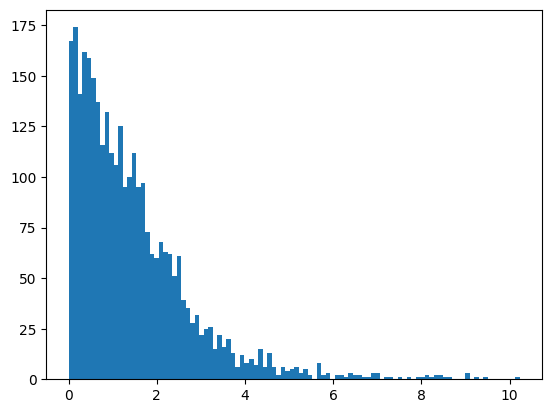

In [ ]:
plt.hist(mae_list, bins=100);

In [ ]:
np.mean(np.abs(mae_list))

np.float64(1.4524319315822323)

In [ ]:
for i in mae_list:
  print(i)

2.35566459537095
1.7636309427886658
1.327449660006593
0.6756439046753764
0.1358257934828213
0.3600305081867816
0.45956635286699665
1.9917443574351985
1.3598867935750594
0.8375852343858217
1.0905845755210688
0.14113580259125413
0.15181257754093203
0.10997772315335652
2.4260074557201
0.5441061859161387
1.142929897933353
0.8061421586794832
3.7227879280365297
0.26699350740075545
0.7220470873746034
3.404033058179584
1.1751008096381401
0.3375428889928944
0.5333307705484867
0.6261201467171844
1.6598473894386991
0.5527239532245662
0.23601014360292005
0.12408898772876498
1.9125243712586624
2.223278050193553
2.346048381132734
0.443728445463881
5.009126633405408
1.0152807715984533
0.49701773327745613
1.1162797952360286
1.8100801662592048
1.6948517875106415
0.14961735450666325
0.9535943922072043
1.4813254458901763
3.134168336175044
0.19395469480191707
0.33417078139739864
0.8767957425072854
0.01684840342335292
0.3163977937219329
0.18325522688099838
0.8561461486530817
4.5098795115155195
0.8456580331

In [ ]:
model2 = ARIMA(train['FoodInsecurity'], order=(1, d, 1))
result2 = model2.fit()

In [ ]:
forecast2 = result2.forecast(steps=len(test))


In [ ]:
forecast2.iloc[318:319]

,predicted_mean
16028,13.476717


In [ ]:
mae_list2 = []
for i in range(len(test["FoodInsecurity"])):
  mae_list2.append(list(test["FoodInsecurity"])[i] - list(forecast2)[i])

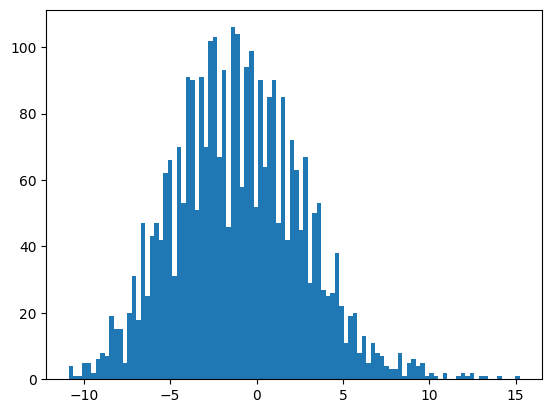

In [ ]:
plt.hist(mae_list2, bins=100);

In [ ]:
np.mean(np.abs(mae_list2))

np.float64(3.1152877994197112)

In [ ]:
abs(mae_list2)

TypeError: bad operand type for abs(): 'list'

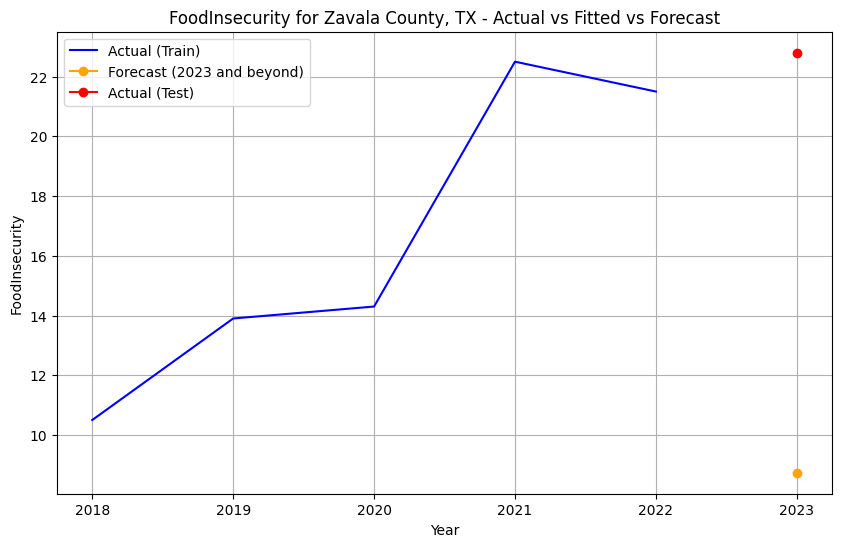

Forecast for Zavala County, TX:
15710    13.655665
15711    15.536369
15712    13.127450
15713     8.475644
15714     9.035826
           ...    
18847    17.669151
18848    10.311870
18849    22.346987
18850    25.773002
18851    24.517851
Name: predicted_mean, Length: 3142, dtype: float64
18850    22.8
Name: FoodInsecurity, dtype: float64


In [ ]:
def plot_fit_and_forecast(result, df_long, name, county_name):
    train_county = train[train['State/county'] == county_name]
    test_county = test[test['State/county'] == county_name]
    if train_county.empty or test_county.empty:
        print(f"County '{county_name}' not found in the dataset.")
        return
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(train_county['Year'], train_county["FoodInsecurity"], label='Actual (Train)', color='blue')
    inde = 0
    for i in range(len(test['State/county'])):
      if list(test['State/county'])[i] =="Burlington County, NJ":
        inde = i
    ax.plot(test_county['Year'], forecast.iloc[inde:inde+1], label='Forecast (2023 and beyond)', color='orange', marker='o')
    ax.plot(test_county['Year'], test_county[name], label='Actual (Test)', color='red', marker='o')

    ax.set_xlabel('Year')
    ax.set_ylabel(name)
    ax.set_title(f'{name} for {county_name} - Actual vs Fitted vs Forecast')
    ax.legend()
    ax.grid(True)
    plt.show()

    print(f"Forecast for {county_name}:")
    print(forecast)
    print(test_county["FoodInsecurity"])

plot_fit_and_forecast(result, df_long, 'FoodInsecurity', "Zavala County, TX")

In [ ]:
result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:         FoodInsecurity   No. Observations:                15710
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -33095.544
Date:                Sat, 04 Apr 2026   AIC                          66223.087
Time:                        22:02:36   BIC                          66345.680
Sample:                             0   HQIC                         66263.670
                              - 15710                                         
Covariance Type:                  opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      16.7907      0.255     65.786      0.000      16.290      17.291
CollegeGraduation           0.0068      0.002      4.498      0.000       0.004       0.010
ObesityRate                 0.0566      0.003     17.516      0.000       0.050       0.063
Median Household Income -1.422e-05   1.24e-06    -11.462      0.000   -1.67e-05   -1.18e-05
Food Environment Index     -1.4111      0.012   -121.116      0.000      -1.434      -1.388
UninsuredRate               0.0365      0.003     11.411      0.000       0.030       0.043
PovertyRate                 0.1415      0.003     53.504      0.000       0.136       0.147
SingleParentHouseholds      0.0496      0.002     31.051      0.000       0.046       0.053
HousingProblems             0.0427      0.003     12.630      0.000       0.036       0.049
ElderlyPopulation          -0.0362      0.003    -10.830      0.000      -0.043      -0.030
FemalePopulation         7.407e-05   1.02e-05      7.261      0.000    5.41e-05    9.41e-05
TotalPopulation         -4.093e-08    6.6e-08     -0.620      0.535    -1.7e-07    8.85e-08
UnemploymentRate            0.1959      0.008     25.980      0.000       0.181       0.211
ar.L1                       0.4316      0.132      3.280      0.001       0.174       0.689
ma.L1                      -0.3856      0.134     -2.875      0.004      -0.648      -0.123
sigma2                      3.9581      0.032    122.683      0.000       3.895       4.021
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              8315.63
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.73   Skew:                            -0.77
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

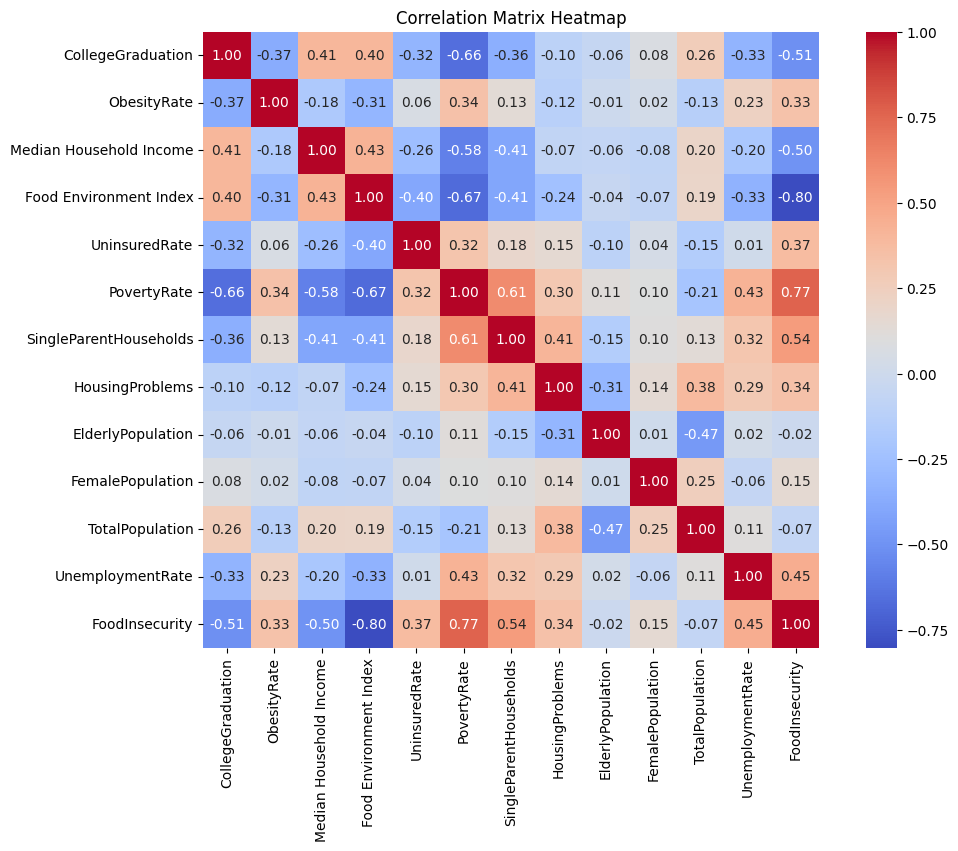

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
'''#try not to use .corr
from scipy.stats import pearsonr, spearmanr
pearsonr(x,y)'''


correlation_matrix = df_long[required_exog_vars + ['FoodInsecurity']].corr(method="spearman")

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import drive
import os

#Path to personal drive
directory = '/content/drive/My Drive/CNN_Images'

# List the contents of the root directory
root_directory = '/content/drive/My Drive'
print("Root directory contents:")
print(os.listdir(root_directory))

# Check if CNN_Images exists
if os.path.exists(directory):
    print(f"Directory '{directory}' exists")
    print("Contents of the directory:")
    print(os.listdir(directory))
else:
    print(f"Directory '{directory}' does not exist. Please check the path and try again.")


ValueError: mount failed

In [ ]:
import geopandas as gpd

shapefile_path = '/content/drive/My Drive/CNN_Images/cb_2018_us_county_500k.shp'

gdf = gpd.read_file(shapefile_path)

gdf_df = pd.DataFrame(gdf)
gdf_df


In [ ]:
forecast_df = pd.DataFrame(forecast)
forecast_df["State/county"] = df["State/county"]
import pandas as pd
#

gdf_df['State_Abbrev'] = gdf_df['STATEFP'].map(state_abbreviations)


gdf_df['State/county'] = gdf_df['NAME'] + ' County, ' + gdf_df['STATEFP'].map(state_abbreviations)

gdf_df['State/county'] = gdf_df['State/county'].str.replace('McKean', 'Mc Kean')
gdf_df['State/county'] = gdf_df['State/county'].str.replace('LaSalle', 'La Salle')
gdf_df['State/county'] = gdf_df['State/county'].str.replace('LaPorte', 'La Porte')
gdf_df['State/county'] = gdf_df['State/county'].str.replace('LaGrange', 'Lagrange')

predicted_LSTM_FoodInsecurity_Map_df = forecast_df.merge(gdf_df, on="State/county", how="inner")


In [ ]:
predicted_LSTM_FoodInsecurity_Map_df

In [ ]:
import pandas as pd

# Reset the indices of both dataframes
forecast_df_reset = forecast_df.reset_index(drop=True)

# Merge the dataframes
merged_df = pd.concat([forecast_df_reset, df], axis=1)

'''forecast_df = pd.DataFrame(forecast)
dfTemp = pd.DataFrame()
dfTemp["State/county"] = df["State/county"]
for i in range(len(forecast_df)):
  if i%1000==0:
    print(forecast_df.iloc[i])
  dfTemp["PredictedFoodInsecurityARIMA"]'''
merged_df.drop(columns=["predicted_mean"])
df["State/county"]

In [ ]:
df["Predicted food insecurity ARIMA"] = pd.DataFrame(forecast)
for i in range(len(df["State/county"])):
  print(df["State/county"].iloc[i:i+1])


In [ ]:
df["twentyThreeFoodInsecurity"]

# **LSTM**

In [ ]:
import pandas as pd

df_long = df_long.sort_values(by=['State/county', 'Year']).reset_index(drop=True)

reshaped_data = []

for county in df_long['State/county'].unique():
    county_data = df_long[df_long['State/county'] == county]

    for year in range(2018, 2024):
        year_data = county_data[county_data['Year'] == year]

        reshaped_data.append(year_data)

reshaped_df = pd.concat(reshaped_data, ignore_index=True)

print(reshaped_df.shape)
print(reshaped_df.head())


NameError: name 'df_long' is not defined

In [ ]:
reshaped_df[["Year", "State/county"]]

,Year,State/county
0,2018,"Abbeville County, SC"
1,2019,"Abbeville County, SC"
2,2020,"Abbeville County, SC"
3,2021,"Abbeville County, SC"
4,2022,"Abbeville County, SC"
...,...,...
18847,2019,"Ziebach County, SD"
18848,2020,"Ziebach County, SD"
18849,2021,"Ziebach County, SD"
18850,2022,"Ziebach County, SD"


In [ ]:
train = reshaped_df[reshaped_df['Year'] < 2023]
test = reshaped_df[reshaped_df['Year'] == 2023]
required_exog_vars=['CollegeGraduation', 'Food Environment Index', 'ObesityRate', 'Median Household Income', 'UninsuredRate', 'PovertyRate', 'SingleParentHouseholds', 'HousingProblems', 'ElderlyPopulation', 'FemalePopulation', 'TotalPopulation', 'UnemploymentRate', 'FoodInsecurity']

In [ ]:
required_exog_vars=['CollegeGraduation', 'Food Environment Index', 'ObesityRate', 'Median Household Income', 'UninsuredRate', 'PovertyRate', 'SingleParentHouseholds', 'HousingProblems', 'ElderlyPopulation', 'FemalePopulation', 'TotalPopulation', 'UnemploymentRate', 'FoodInsecurity']
for i in required_exog_vars:
  print(i)


CollegeGraduation
Food Environment Index
ObesityRate
Median Household Income
UninsuredRate
PovertyRate
SingleParentHouseholds
HousingProblems
ElderlyPopulation
FemalePopulation
TotalPopulation
UnemploymentRate
FoodInsecurity


In [ ]:
from sklearn.preprocessing import MinMaxScaler

train[train["Year"]==2022]["FoodInsecurity"]
scaler = MinMaxScaler()
for col in required_exog_vars:
    train[col] = scaler.fit_transform(train[[col]])
train

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Median Household Income,Food Environment Index,Year
0,"Abbeville County, SC",0.485916,0.559499,0.310261,0.391370,0.205945,0.291329,0.004412,0.002439,0.200662,0.385714,0.307054,0.134834,0.77,2018
1,"Abbeville County, SC",0.515027,0.588727,0.284706,0.362486,0.206042,0.304464,0.004419,0.002424,0.168757,0.354286,0.352697,0.163078,0.79,2019
2,"Abbeville County, SC",0.521256,0.536534,0.313114,0.371172,0.201018,0.314899,0.004428,0.002406,0.142162,0.351429,0.392808,0.237139,0.78,2020
3,"Abbeville County, SC",0.541780,0.536534,0.335532,0.298433,0.195148,0.325616,0.907598,0.002405,0.115660,0.328571,0.265560,0.252557,0.79,2021
4,"Abbeville County, SC",0.551138,0.569937,0.316484,0.330107,0.207172,0.341388,0.004446,0.002393,0.258082,0.274286,0.251729,0.525998,0.75,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18846,"Ziebach County, SD",0.439122,0.699374,0.231818,0.577665,0.337711,0.052629,0.004192,0.000267,0.151239,0.494286,0.615491,0.065237,0.46,2018
18847,"Ziebach County, SD",0.410206,0.713987,0.195627,0.563425,0.329373,0.088878,0.004132,0.000263,0.196211,0.505714,1.000000,0.073301,0.46,2019
18848,"Ziebach County, SD",0.400949,0.847599,0.205623,0.536394,0.328824,0.091107,0.004151,0.000261,0.193420,0.534286,0.558783,0.236165,0.43,2020
18849,"Ziebach County, SD",0.370452,0.866388,0.542330,0.455083,0.376280,0.090879,0.879911,0.000263,0.213026,0.505714,0.843707,0.296640,0.44,2021


In [ ]:
scaler = MinMaxScaler()
for col in required_exog_vars:
    test[col] = scaler.fit_transform(test[[col]])
test



,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Median Household Income,Food Environment Index,Year
5,"Abbeville County, SC",0.513659,0.587079,0.328072,0.468600,0.202991,0.336168,0.824776,0.002466,0.192015,0.333333,0.330341,0.158544,0.76,2023
11,"Acadia Parish, LA",0.410113,0.581461,0.182927,0.402808,0.185663,0.209075,0.808812,0.005822,0.213220,0.563218,0.464991,0.100320,0.70,2023
17,"Accomack County, VA",0.430117,0.581461,0.279115,0.470045,0.198008,0.379283,0.811428,0.003376,0.181854,0.352490,0.411131,0.189280,0.83,2023
23,"Ada County, ID",0.743444,0.283708,0.131322,0.233770,0.190040,0.197630,0.772446,0.052075,0.124432,0.199234,0.113106,0.426907,0.86,2023
29,"Adair County, IA",0.603103,0.511236,0.077650,0.221525,0.138221,0.322281,0.768021,0.000761,0.115502,0.241379,0.197487,0.270851,0.88,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18827,"Yuma County, AZ",0.538965,0.643258,0.388793,0.392512,0.278736,0.273580,0.726207,0.021052,0.632672,0.521073,0.398564,0.225027,0.65,2023
18833,"Yuma County, CO",0.607101,0.278090,0.378701,0.248606,0.206704,0.253804,0.763567,0.001006,0.096912,0.210728,0.276481,0.229473,0.86,2023
18839,"Zapata County, TX",0.354240,0.733146,0.699734,0.297104,0.348544,0.151587,0.784024,0.001409,0.587783,0.720307,0.750449,0.090360,0.56,2023
18845,"Zavala County, TX",0.534891,0.811798,0.526275,0.773353,0.274636,0.174099,0.746763,0.000964,0.619580,0.773946,0.646320,0.057204,0.39,2023


In [ ]:
def create_sequences_train(data, n_steps=4):
    X = []
    y = []

    counties = data['State/county'].unique()
    for county in counties:
        county_data = data[data['State/county'] == county]
        num_years = len(county_data)

        for i in range(n_steps, num_years):
            exogenous = county_data.iloc[i-n_steps:i][['CollegeGraduation', 'PovertyRate', 'Median Household Income', 'Food Environment Index', 'ObesityRate', 'UninsuredRate', 'SingleParentHouseholds', 'HousingProblems', 'ElderlyPopulation', 'FemalePopulation', 'TotalPopulation', 'UnemploymentRate']].values.astype(float)
            prev_food_insecurity = county_data.iloc[i-n_steps:i]["FoodInsecurity"].values.astype(float).reshape(-1, 1)
            X.append(np.concatenate((exogenous, prev_food_insecurity), axis=1))

            y.append(county_data.iloc[i]["FoodInsecurity"])

    X = np.array(X)
    y = np.array(y, dtype=float)

    print("X shape (train):", X.shape)
    print("y shape (train):", y.shape)

    return X, y

def create_sequences_test(data, prev, n_steps=1):
    X = []
    y = []

    counties = data['State/county'].unique()
    for county in counties:
        county_data = data[data['State/county'] == county]
        prev_year_county = prev[prev["State/county"] == county]
        exogenous = county_data[['CollegeGraduation', 'PovertyRate', 'Median Household Income', 'Food Environment Index', 'ObesityRate', 'UninsuredRate', 'SingleParentHouseholds', 'HousingProblems', 'ElderlyPopulation', 'FemalePopulation', 'TotalPopulation', 'UnemploymentRate']].values.astype(float)
        prev_food_insecurity = prev_year_county["FoodInsecurity"].values.astype(float)

        for i in range(len(exogenous) - n_steps + 1):
            exog_segment = exogenous[i:i + n_steps]
            food_segment = prev_food_insecurity[i:i + n_steps].reshape(-1, 1)
            X.append(np.concatenate((exog_segment, food_segment), axis=1))

            y.append(county_data["FoodInsecurity"].values[i + n_steps - 1])
    X = np.array(X)
    y = np.array(y, dtype=float)

    print("X shape (test):", X.shape)
    print("y shape (test):", y.shape)

    return X, y


n_steps_train = 4
n_steps_test = 1

X_train, y_train = create_sequences_train(train, n_steps_train)
X_test, y_test = create_sequences_test(test, train[train["Year"] == 2022], n_steps_test)
yActual = y_test[::-1]

X shape (train): (3142, 4, 13)
y shape (train): (3142,)
X shape (test): (3142, 1, 13)
y shape (test): (3142,)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV

best_model = Sequential()
best_model.add(LSTM(50, activation='relu', input_shape=(4, 13)))
best_model.add(Dense(1))

best_model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

history = best_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=0)
y_pred = best_model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error for 2023 prediction: {mae}')

'''
def create_model(lstm_units, learning_rate, batch_size):
    created_model = Sequential()
    created_model.add(LSTM(lstm_units, activation='relu', input_shape=(4, 13)))
    created_model.add(Dense(1))

    created_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')

    return created_model

lstm_units_list = [50]
learning_rate_list = [0.01]
batch_size_list = [32]
best_model = None
best_mae = float('inf')
best_params = None

for lstm_units in lstm_units_list:
    for learning_rate in learning_rate_list:
        for batch_size in batch_size_list:
            print(f"Training with: LSTM Units = {lstm_units}, Learning Rate = {learning_rate}, Batch Size = {batch_size}")

            model = create_model(lstm_units, learning_rate, batch_size)

            history = model.fit(X_train, y_train, epochs=50, batch_size=batch_size, validation_data=(X_test, y_test), verbose=0)

            y_pred = model.predict(X_test)

            mae = mean_absolute_error(y_test, y_pred)
            print(f"MAE for this configuration: {mae}")

            if mae < best_mae:
                best_mae = mae
                best_model = model
                best_params = {
                    'lstm_units': lstm_units,
                    'learning_rate': learning_rate,
                    'batch_size': batch_size
                }

print(f"Best Hyperparameters: {best_params}")
print(f"Best Mean Absolute Error: {best_mae}")

y_pred = best_model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error for 2023 prediction: {mae}')
'''

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean Absolute Error for 2023 prediction: 12.130610390062957


'\ndef create_model(lstm_units, learning_rate, batch_size):\n    created_model = Sequential()\n    created_model.add(LSTM(lstm_units, activation=\'relu\', input_shape=(4, 13)))\n    created_model.add(Dense(1))\n\n    created_model.compile(optimizer=Adam(learning_rate=learning_rate), loss=\'mean_squared_error\')\n\n    return created_model\n\nlstm_units_list = [50]\nlearning_rate_list = [0.01]\nbatch_size_list = [32]\nbest_model = None\nbest_mae = float(\'inf\')\nbest_params = None\n\nfor lstm_units in lstm_units_list:\n    for learning_rate in learning_rate_list:\n        for batch_size in batch_size_list:\n            print(f"Training with: LSTM Units = {lstm_units}, Learning Rate = {learning_rate}, Batch Size = {batch_size}")\n\n            model = create_model(lstm_units, learning_rate, batch_size)\n\n            history = model.fit(X_train, y_train, epochs=50, batch_size=batch_size, validation_data=(X_test, y_test), verbose=0)\n\n            y_pred = model.predict(X_test)\n\n      

In [ ]:
actualFoodInsecurity = []
for i in range(len(df_long)):
  if 2023==df_long['Year'].iloc[i]:
    actualFoodInsecurity.append(df_long['FoodInsecurity'].iloc[i])
act = pd.DataFrame(actualFoodInsecurity)
act

,0
0,11.3
1,17.3
2,11.8
3,7.8
4,8.9
...,...
3137,16.2
3138,8.1
3139,21.4
3140,22.8


In [ ]:
y_pred = best_model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred)

mae = mean_absolute_error(act, y_pred)
print(mae)

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
0.9180445671081543


In [ ]:
pd.DataFrame(y_pred)

,0
0,12.200805
1,18.332493
2,11.946738
3,7.296274
4,8.470472
...,...
3137,21.404591
3138,9.247857
3139,22.599186
3140,26.390293


In [ ]:
df=df_long[df_long['Year']=="2023"]

In [ ]:
df=df_long[df_long['State/county']=="Essex County, MA"]
df

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Median Household Income,Food Environment Index,Year
5310,"Essex County, MA",67.4914,25.6,4.1066,34.3400,18.8344,16.3494,51.8016,779018,3.7983,8.1,14.2,76373,8.9,2018
5311,"Essex County, MA",68.1614,25.3,4.2477,33.8339,18.8305,16.6483,51.7511,785205,3.7783,7.3,13.9,83253,9.0,2019
5312,"Essex County, MA",67.4553,24.8,4.7269,33.5332,18.6600,17.0490,51.7777,790638,3.4202,7.2,13.3,80459,9.0,2020
5313,"Essex County, MA",67.0231,26.1,3.8148,26.8842,18.7770,17.5568,5177.7700,789034,2.9728,8.0,11.9,79338,8.8,2021
5314,"Essex County, MA",68.1331,26.4,5.0598,26.6339,19.1741,17.9934,51.8331,791263,9.7875,7.6,11.2,80702,9.0,2022
5315,"Essex County, MA",68.8493,27.3,3.1030,26.5286,19.2012,17.8793,51.4825,807074,6.3755,9.4,12.2,96303,8.5,2023


In [ ]:
pd.DataFrame(act)


,0
0,11.3
1,17.3
2,11.8
3,7.8
4,8.9
...,...
3137,16.2
3138,8.1
3139,21.4
3140,22.8


In [ ]:
for i in y_pred:
  print(float(i))

12.200804710388184
18.33249282836914
11.946738243103027
7.296274185180664
8.47047233581543
16.88201332092285
13.740728378295898
19.21700668334961
8.753656387329102
8.408211708068848
13.55426025390625
10.106424331665039
10.634411811828613
24.067039489746094
5.018342971801758
10.466752052307129
19.45856285095215
7.842615127563477
13.061127662658691
12.326817512512207
7.369131088256836
9.36666202545166
11.212698936462402
11.561636924743652
12.774105072021484
8.096569061279297
13.525459289550781
9.609302520751953
10.1561861038208
7.293318271636963
17.321134567260742
17.618896484375
8.037776947021484
8.08222770690918
19.81991958618164
12.985876083374023
7.588875770568848
8.842257499694824
14.898754119873047
8.065693855285645
9.397229194641113
16.7595272064209
12.830391883850098
17.67533302307129
13.917411804199219
10.119519233703613
10.413667678833008
13.93600845336914
14.326848983764648
13.162997245788574
14.992535591125488
17.656518936157227
14.799259185791016
14.245707511901855
10.696901

In [ ]:
pd.DataFrame(y_pred)[pd.DataFrame(y_pred).isna().any(axis=1)]

,0


In [ ]:
print(type(y_pred))

<class 'numpy.ndarray'>


In [ ]:
import numpy as np
mae_list = []
for i in range(len(test["FoodInsecurity"])):
  mae_list.append(abs(list(actualFoodInsecurity)[i] - list(y_pred)[i]))
np.mean(mae_list)

np.float64(0.9180445623124655)

In [ ]:
np.mean(np.abs(mae_list))

np.float64(0.9180445623124655)

In [ ]:
for i in mae_list:
  print(float(i))

0.9008047103881829
1.0324928283691435
0.1467382431030284
0.5037258148193358
0.42952766418457067
1.6820133209228523
0.24072837829589844
0.21700668334960938
0.5463436126708991
0.29178829193115163
0.14573974609375107
0.4935756683349606
1.3655881881713867
2.167039489746095
1.3816570281982425
0.7332479476928722
1.4585628509521484
0.3573848724365245
0.8611276626586921
0.626817512512206
0.9308689117431648
0.2666620254516605
0.312698936462402
0.838363075256348
0.32589492797851705
1.2034309387207038
0.825459289550782
0.6906974792480458
0.9438138961791989
0.30668172836303675
1.0211345672607415
0.118896484375
1.7622230529785163
2.0177722930908217
2.5199195861816435
0.5141239166259766
0.8111242294311527
2.057742500305176
0.6987541198730476
0.4656938552856449
0.20277080535888636
1.1595272064208988
0.0696081161499027
0.17533302307128906
1.117411804199218
0.6804807662963874
1.5863323211669922
0.6360084533691399
0.6268489837646474
0.23700275421142614
0.292535591125489
1.7565189361572262
0.299259185791

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Replace this with your actual data.
# This example generates data that resembles the provided image.
# You can replace this line with: mae_list = np.array([...your data here...])
# A higher number of bins will show more detail, a lower number will generalize the distribution.
plt.hist(mae_list, bins=100)

# Step 3: Add labels and a title for clarity.
plt.title('Histogram of MAE Values')
plt.xlabel('MAE (Mean Absolute Error)')
plt.ylabel('Frequency')

# Step 4: Display the plot.
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7982b02025c0> (for post_execute):


KeyboardInterrupt: 

Exception ignored in: <function TransformNode.set_children.<locals>.<lambda> at 0x798155315d00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/transforms.py", line 195, in <lambda>
    self, lambda _, pop=child._parents.pop, k=id_self: pop(k))

KeyboardInterrupt: 


Error in callback <function flush_figures at 0x7982b01ebb00> (for post_execute):


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_fit_and_forecast(df, county):
    fig, ax = plt.subplots(figsize=(10, 6))

    county_data = df[df["State/county"] == county].iloc[0]
    years = ['2018', '2019', '2020', '2021', '2022', '2023']

    ax.plot(years, county_data[years], label='Actual (2018-2023)', color='blue', marker='o')

    ax.plot('2023', county_data['predicted2023'], label='Predicted 2023', color='orange', marker='o')

    ax.set_xlabel('Year')
    ax.set_ylabel('Values')
    ax.set_title(f'Actual vs Predicted for {county}')
    ax.legend()
    ax.grid(True)
    plt.show()

    print(f"Predicted 2023 value for {county}: {county_data['predicted2023']}")
'''plot_fit_and_forecast(dfLSTM, county="Camden County, NJ")
'''

'plot_fit_and_forecast(dfLSTM, county="Camden County, NJ")\n'

In [ ]:
mae_listLSTM = []
for i in mae_list:
  mae_listLSTM.append(float(i))
mae_listLSTM

(array([ 7., 19., 13., 24., 16., 32., 23., 29., 45., 40., 68., 59., 87.,
        83., 82., 75., 81., 98., 84., 97., 96., 93., 73., 84., 93., 75.,
        85., 89., 93., 85., 83., 72., 90., 76., 70., 77., 60., 56., 58.,
        50., 55., 43., 43., 46., 30., 33., 31., 22., 19., 22., 22., 15.,
        15.,  9.,  8., 12.,  6., 12.,  8.,  9.,  1.,  2.,  3.,  4.,  6.,
         2.,  7.,  4.,  2.,  1.,  5.,  4.,  1.,  3.,  3.,  0.,  0.,  2.,
         1.,  0.,  1.,  3.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  2.,  0.,
         0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.]),
 array([ 3.09063154,  3.3849658 ,  3.67930005,  3.97363431,  4.26796857,
         4.56230283,  4.85663709,  5.15097135,  5.44530561,  5.73963986,
         6.03397412,  6.32830838,  6.62264264,  6.9169769 ,  7.21131116,
         7.50564542,  7.79997967,  8.09431393,  8.38864819,  8.68298245,
         8.97731671,  9.27165097,  9.56598523,  9.86031948, 10.15465374,
        10.448988  , 10.74332226, 11.03765652, 11.33199078, 11.626325

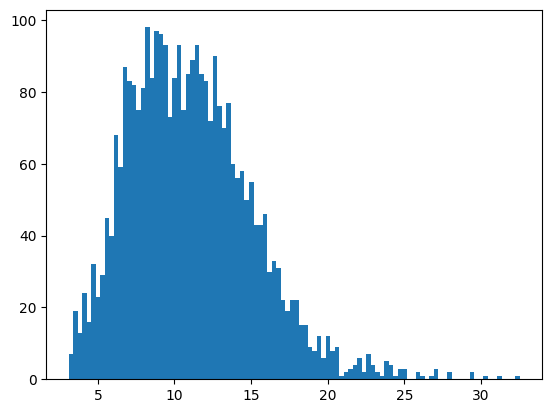

In [ ]:
plt.hist(mae_listLSTM, bins=100)

In [ ]:
import pandas as pd

y_pred_df = pd.DataFrame(y_pred)

pred_df_reset = y_pred_df.reset_index(drop=True)

'''forecast_df = pd.DataFrame(forecast)
dfTemp = pd.DataFrame()
dfTemp["State/county"] = df["State/county"]
for i in range(len(forecast_df)):
  if i%1000==0:
    print(forecast_df.iloc[i])
  dfTemp["PredictedFoodInsecurityARIMA"]'''
'''["LSTM predicted"] = y_pred_df[0]
'''
df

In [ ]:
y_pred_df[0]

# **CNN**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import drive
import os

directory = '/content/drive/My Drive/CNN_Images'

root_directory = '/content/drive/My Drive'
print("Root directory contents:")
print(os.listdir(root_directory))

if os.path.exists(directory):
    print(f"Directory '{directory}' exists")
    print("Contents of the directory:")
    print(os.listdir(directory))
else:
    print(f"Directory '{directory}' does not exist. Please check the path and try again.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Root directory contents:
['Colab Notebooks', 'Untitled document (67).gdoc', 'IMG_4351.jpeg', 'IMG_4350.jpeg', 'IMG_4349.jpeg', 'IMG_4348.jpeg', 'C_tomcat_genesistempA83AB24CB16BEB5FE8BEE30430014BC8-261326-transcript.pdf', 'Shaurya Singh Resume (1).gdoc', 'Shaurya Singh Resume (2).pdf', 'About Cradles to Crayons:.gdoc', 'Giving Factory.docx', 'clideo.com', 'Screencastify', 'rubric.gdoc', 'Copy of English Essay.gdoc', 'English Essay.gdoc', 'USACO BRONZE Algorithms and strats.gdoc', 'Weather.gdoc', 'App: NavPro.gdoc', 'Untitled document (66).gdoc', 'Using AI to Predict Workouts for Enhanced Hypertrophy - Shaurya.gdoc', 'IMG_5086.png', 'IMG_5087.png', 'IMG_5089.jpeg', 'IMG_5090.jpeg', 'IMG_5091.jpeg', 'IMG_5092.jpeg', 'Untitled document (65).gdoc', 'Copy of Luv Michael Volunteer Toolkit Modules.gdoc', 'Shaurya Resume.gdoc', 'IMG_5118.jpeg', 'IMG_5119.jpeg', 'IMG_

In [ ]:
import geopandas as gpd
import pandas as pd


shapefile_path = '/content/drive/My Drive/CNN_Images/cb_2018_us_county_500k.shp'

gdf = gpd.read_file(shapefile_path)

cnn_df = pd.DataFrame(gdf)
cnn_df

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,21,007,00516850,0500000US21007,21007,Ballard,06,639387454,69473325,"POLYGON ((-89.18137 37.0463, -89.17938 37.0530..."
1,21,017,00516855,0500000US21017,21017,Bourbon,06,750439351,4829777,"POLYGON ((-84.44266 38.28324, -84.44114 38.283..."
2,21,031,00516862,0500000US21031,21031,Butler,06,1103571974,13943044,"POLYGON ((-86.94486 37.07341, -86.94346 37.074..."
3,21,065,00516879,0500000US21065,21065,Estill,06,655509930,6516335,"POLYGON ((-84.12662 37.6454, -84.12483 37.6461..."
4,21,069,00516881,0500000US21069,21069,Fleming,06,902727151,7182793,"POLYGON ((-83.98428 38.44549, -83.98246 38.450..."
...,...,...,...,...,...,...,...,...,...,...
3228,31,073,00835858,0500000US31073,31073,Gosper,06,1186616237,11831826,"POLYGON ((-100.0951 40.43866, -100.08937 40.43..."
3229,39,075,01074050,0500000US39075,39075,Holmes,06,1094405866,3695230,"POLYGON ((-82.22066 40.66758, -82.19327 40.667..."
3230,48,171,01383871,0500000US48171,48171,Gillespie,06,2740719114,9012764,"POLYGON ((-99.304 30.49983, -99.28234 30.49967..."
3231,55,079,01581100,0500000US55079,55079,Milwaukee,06,625440563,2455383635,"POLYGON ((-88.06959 42.86726, -88.06959 42.872..."


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<Figure size 1500x1000 with 0 Axes>

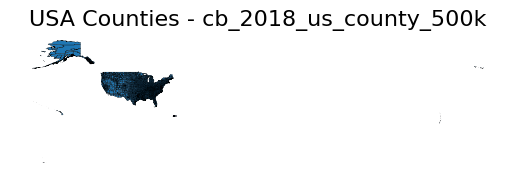

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Install geopandas if not already installed
!pip install geopandas

# Step 3: Import libraries
import geopandas as gpd
import matplotlib.pyplot as plt

# Step 4: Load the shapefile
shapefile_path = '/content/drive/My Drive/CNN_Images/cb_2018_us_county_500k.shp'
gdf = gpd.read_file(shapefile_path)

# Step 5: Plot the shapefile
plt.figure(figsize=(15, 10))
gdf.plot(edgecolor='black', linewidth=0.2)
plt.title('USA Counties - cb_2018_us_county_500k', fontsize=16)
plt.axis('off')
plt.show()


In [ ]:
state_abbreviations = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA", "08": "CO", "09": "CT",
    "10": "DE", "11": "DC", "12": "FL", "13": "GA", "15": "HI", "16": "ID", "17": "IL",
    "18": "IN", "19": "IA", "20": "KS", "21": "KY", "22": "LA", "23": "ME", "24": "MD",
    "25": "MA", "26": "MI", "27": "MN", "28": "MS", "29": "MO", "30": "MT", "31": "NE",
    "32": "NV", "33": "NH", "34": "NJ", "35": "NM", "36": "NY", "37": "NC", "38": "ND",
    "39": "OH", "40": "OK", "41": "OR", "42": "PA", "44": "RI", "45": "SC", "46": "SD",
    "47": "TN", "48": "TX", "49": "UT", "50": "VT", "51": "VA", "53": "WA", "54": "WV",
    "55": "WI", "56": "WY"
}
df_long2['State/county'] = df_long2['State/county'].str.replace('Parish', 'County')
df_long2['State/county'] = df_long2['State/county'].str.replace('Borough', 'County')
df_long2['State/county'] = df_long2['State/county'].str.replace('Census Area', 'County')
df_long2['State/county'] = df_long2['State/county'].str.replace('city', 'County')
df_long2['State/county'] = df_long2['State/county'].str.replace('City', 'County')
df_long2['State/county'] = df_long2['State/county'].str.replace('Municipality', 'County')
df_long2['State/county'] = df_long2['State/county'].str.replace('LaSalle', 'La Salle')
df_long2['State/county'] = df_long2['State/county'].str.replace('LaPorte', 'La Porte')
df_long2['State/county'] = df_long2['State/county'].str.replace('James County County', 'James City County')
df_long2['State/county'] = df_long2['State/county'].str.replace('Dona', 'Doña')
df_long2['State/county'] = df_long2['State/county'].str.replace('McDoñald', 'McDonald')
df_long2['State/county'] = df_long2['State/county'].str.replace('District of Columbia', 'District of Columbia County')
df_long2['State/county'] = df_long2['State/county'].str.replace('De Kalb', 'DeKalb')
df_long2['State/county'] = df_long2['State/county'].str.replace('DeBaca', 'De Baca')
df_long2['State/county'] = df_long2['State/county'].str.replace('Charles County County', 'Charles City County')
df_long2['State/county'] = df_long2['State/county'].str.replace('Carson County, NV', 'Carson City County, NV')
df_long3 = df_long2.copy()
df_long3
df_2018 = df_long2[df_long2["Year"]==2018]

df_2019 = df_long2[df_long2["Year"]==2019]

df_2020 = df_long2[df_long2["Year"]==2020]

df_2021 = df_long2[df_long2["Year"]==2021]

df_2022 = df_long2[df_long2["Year"]==2022]

df_2023 = df_long2[df_long2["Year"]==2023]
df_long2.columns

Index(['State/county', 'CollegeGraduation', 'ObesityRate', 'UninsuredRate',
       'SingleParentHouseholds', 'HousingProblems', 'ElderlyPopulation',
       'FemalePopulation', 'TotalPopulation', 'UnemploymentRate',
       'FoodInsecurity', 'PovertyRate', 'Median Household Income',
       'Food Environment Index', 'Year'],
      dtype='object')

In [ ]:
state_abbreviations = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA", "08": "CO", "09": "CT",
    "10": "DE", "11": "DC", "12": "FL", "13": "GA", "15": "HI", "16": "ID", "17": "IL",
    "18": "IN", "19": "IA", "20": "KS", "21": "KY", "22": "LA", "23": "ME", "24": "MD",
    "25": "MA", "26": "MI", "27": "MN", "28": "MS", "29": "MO", "30": "MT", "31": "NE",
    "32": "NV", "33": "NH", "34": "NJ", "35": "NM", "36": "NY", "37": "NC", "38": "ND",
    "39": "OH", "40": "OK", "41": "OR", "42": "PA", "44": "RI", "45": "SC", "46": "SD",
    "47": "TN", "48": "TX", "49": "UT", "50": "VT", "51": "VA", "53": "WA", "54": "WV",
    "55": "WI", "56": "WY"
}

In [ ]:
df_long3 = pd.concat([pd.DataFrame({"State/county":["Zavala County, TX"],"CollegeGraduation":[100],"ObesityRate":[100],"UninsuredRate":[100],'SingleParentHouseholds':[100],'HousingProblems':[100],'ElderlyPopulation':[100],'FemalePopulation':[100],'TotalPopulation':[100],'UnemploymentRate':[100],'FoodInsecurity':[100],'PovertyRate':[100],'Median Household Income':[100],'Food Environment Index':[100]}),df_long2],ignore_index=True)
dict1 = {}
for i in range(len(df_long2.columns)):
  if i!=0:
    dict1[df_long2.columns[i]] = [0]
  else:
    dict1[df_long2.columns[i]] = ["Zavala County, TX"]
df_long4 = pd.concat([pd.DataFrame(dict1), df_long3])
df_long4


,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Median Household Income,Food Environment Index,Year
0,"Zavala County, TX",0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0,0.0,0,0.0,0.0
0,"Zavala County, TX",100.0000,100.0,100.0000,100.0000,100.0000,100.0000,100.0000,100,100.0000,100.0,100.0,100,100.0,NaN
1,"Ziebach County, SD",44.4615,47.4,13.5196,52.5473,24.5033,10.6303,49.7059,2380,4.5168,20.8,45.8,42254,4.1,2023.0
2,"Zavala County, TX",54.5965,46.5,20.1470,60.9148,18.6275,14.3172,48.8253,9534,12.6679,22.8,38.8,36878,3.9,2023.0
3,"Zapata County, TX",36.9616,43.7,26.1543,23.4020,23.6404,13.1219,50.0360,13908,12.0636,21.4,44.6,41688,5.6,2023.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18848,"Adair County, IA",64.7295,32.9,5.8598,34.8731,8.9231,22.8144,50.6345,7092,3.0410,11.1,15.4,54282,8.6,2018.0
18849,"Ada County, ID",74.5047,25.6,12.8217,26.1603,15.5398,13.5982,49.8719,444028,3.3263,13.4,11.3,66827,7.9,2018.0
18850,"Accomack County, VA",43.4801,36.2,10.3580,41.9071,15.6053,22.2782,51.2884,32947,4.8168,14.2,31.8,42879,8.0,2018.0
18851,"Acadia County, LA",42.2936,33.8,13.7833,36.9925,13.7999,14.2422,51.4119,62645,7.4212,15.3,29.3,40484,7.9,2018.0


In [ ]:
import pandas as pd
#

cnn_df['State_Abbrev'] = cnn_df['STATEFP'].map(state_abbreviations)


cnn_df['State/county'] = cnn_df['NAME'] + ' County, ' + cnn_df['STATEFP'].map(state_abbreviations)

cnn_df['State/county'] = cnn_df['State/county'].str.replace('McKean', 'Mc Kean')
cnn_df['State/county'] = cnn_df['State/county'].str.replace('LaSalle', 'La Salle')
cnn_df['State/county'] = cnn_df['State/county'].str.replace('LaPorte', 'La Porte')
cnn_df['State/county'] = cnn_df['State/county'].str.replace('LaGrange', 'Lagrange')


In [ ]:
mega_df_2018 = df_2018.merge(cnn_df, on="State/county", how="inner")
mega_df_2019 = df_2019.merge(cnn_df, on="State/county", how="inner")
mega_df_2020 = df_2020.merge(cnn_df, on="State/county", how="inner")
mega_df_2021 = df_2021.merge(cnn_df, on="State/county", how="inner")
mega_df_2022 = df_2022.merge(cnn_df, on="State/county", how="inner")
mega_df_2023 = df_2023.merge(cnn_df, on="State/county", how="inner")
keep = [
    "State/county",
    "CollegeGraduation",
    "ObesityRate",
    "UninsuredRate",
    "SingleParentHouseholds",
    "Median Household Income",
    "HousingProblems",
    "ElderlyPopulation",
    "FemalePopulation",
    "TotalPopulation",
    "UnemploymentRate",
    "FoodInsecurity",
    "PovertyRate",
    "Food Environment Index",
    "geometry",
    "Year"
]

mega_df_2018 = mega_df_2018[keep]
mega_df_2019 = mega_df_2019[keep]
mega_df_2020 = mega_df_2020[keep]
mega_df_2021 = mega_df_2021[keep]
mega_df_2022 = mega_df_2022[keep]
mega_df_2023 = mega_df_2023[keep]

mega_df_2018[mega_df_2018.isna().any(axis=1)].iloc[200:250]

duplicates = mega_df_2018[mega_df_2018['State/county'] == 'District of Columbia County, DC']
duplicates = mega_df_2019[mega_df_2019['State/county'] == 'District of Columbia County, DC']
duplicates = mega_df_2020[mega_df_2020['State/county'] == 'District of Columbia County, DC']
duplicates = mega_df_2021[mega_df_2021['State/county'] == 'District of Columbia County, DC']
duplicates = mega_df_2022[mega_df_2022['State/county'] == 'District of Columbia County, DC']
duplicates = mega_df_2023[mega_df_2023['State/county'] == 'District of Columbia County, DC']
print("Number of duplicate rows for District of Columbia, DC:", len(duplicates))

mega_df_2018 = mega_df_2018.drop_duplicates(subset=['State/county'], keep='first')
mega_df_2019 = mega_df_2019.drop_duplicates(subset=['State/county'], keep='first')
mega_df_2020 = mega_df_2020.drop_duplicates(subset=['State/county'], keep='first')
mega_df_2021 = mega_df_2021.drop_duplicates(subset=['State/county'], keep='first')
mega_df_2022 = mega_df_2022.drop_duplicates(subset=['State/county'], keep='first')
mega_df_2023 = mega_df_2023.drop_duplicates(subset=['State/county'], keep='first')

mega_df_2018

Number of duplicate rows for District of Columbia, DC: 1


,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,Median Household Income,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Food Environment Index,geometry,Year
0,"Ziebach County, SD",44.3796,44.5,10.2480,57.7665,32341,24.0506,7.4973,50.3035,2801,4.1837,20.2,46.9,4.6,"POLYGON ((-102.00044 44.69, -102.00015 44.9506...",2018
1,"Zavala County, TX",39.4737,28.7,29.1913,58.3672,30076,20.1125,13.2579,49.7879,12023,14.1022,10.5,47.2,7.0,"POLYGON ((-100.11314 28.77625, -100.11329 28.7...",2018
2,"Zapata County, TX",36.9299,27.6,22.6953,39.9374,33160,19.4350,11.9451,50.1638,14349,11.0000,8.7,41.7,6.7,"POLYGON ((-99.4538 27.26506, -99.42542 27.2836...",2018
3,"Yuma County, CO",66.5012,25.7,8.4425,24.5812,53253,8.3442,18.6578,50.5889,10103,2.1843,11.6,16.3,8.0,"POLYGON ((-102.80364 40.00255, -102.7933 40.00...",2018
4,"Yuma County, AZ",54.2153,31.0,13.2030,30.4463,44116,19.6667,18.4637,48.5112,205631,18.6011,17.5,29.0,6.7,"POLYGON ((-114.81629 32.50804, -114.81432 32.5...",2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,"Adair County, IA",64.7295,32.9,5.8598,34.8731,54282,8.9231,22.8144,50.6345,7092,3.0410,11.1,15.4,8.6,"POLYGON ((-94.70072 41.46725, -94.70057 41.482...",2018
3150,"Ada County, ID",74.5047,25.6,12.8217,26.1603,66827,15.5398,13.5982,49.8719,444028,3.3263,13.4,11.3,7.9,"POLYGON ((-116.51345 43.43706, -116.51349 43.4...",2018
3151,"Accomack County, VA",43.4801,36.2,10.3580,41.9071,42879,15.6053,22.2782,51.2884,32947,4.8168,14.2,31.8,8.0,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",2018
3152,"Acadia County, LA",42.2936,33.8,13.7833,36.9925,40484,13.7999,14.2422,51.4119,62645,7.4212,15.3,29.3,7.9,"POLYGON ((-92.63229 30.31708, -92.62923 30.318...",2018


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf_mega_2018 = gpd.GeoDataFrame(mega_df_2018, geometry='geometry')
gdf_mega_2019 = gpd.GeoDataFrame(mega_df_2019, geometry='geometry')
gdf_mega_2020 = gpd.GeoDataFrame(mega_df_2020, geometry='geometry')
gdf_mega_2021 = gpd.GeoDataFrame(mega_df_2021, geometry='geometry')
gdf_mega_2022 = gpd.GeoDataFrame(mega_df_2022, geometry='geometry')
gdf_mega_2023 = gpd.GeoDataFrame(mega_df_2023, geometry='geometry')

gdf_mega_2018

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,Median Household Income,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Food Environment Index,geometry,Year
0,"Ziebach County, SD",44.3796,44.5,10.2480,57.7665,32341,24.0506,7.4973,50.3035,2801,4.1837,20.2,46.9,4.6,"POLYGON ((-102.00044 44.69, -102.00015 44.9506...",2018
1,"Zavala County, TX",39.4737,28.7,29.1913,58.3672,30076,20.1125,13.2579,49.7879,12023,14.1022,10.5,47.2,7.0,"POLYGON ((-100.11314 28.77625, -100.11329 28.7...",2018
2,"Zapata County, TX",36.9299,27.6,22.6953,39.9374,33160,19.4350,11.9451,50.1638,14349,11.0000,8.7,41.7,6.7,"POLYGON ((-99.4538 27.26506, -99.42542 27.2836...",2018
3,"Yuma County, CO",66.5012,25.7,8.4425,24.5812,53253,8.3442,18.6578,50.5889,10103,2.1843,11.6,16.3,8.0,"POLYGON ((-102.80364 40.00255, -102.7933 40.00...",2018
4,"Yuma County, AZ",54.2153,31.0,13.2030,30.4463,44116,19.6667,18.4637,48.5112,205631,18.6011,17.5,29.0,6.7,"POLYGON ((-114.81629 32.50804, -114.81432 32.5...",2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,"Adair County, IA",64.7295,32.9,5.8598,34.8731,54282,8.9231,22.8144,50.6345,7092,3.0410,11.1,15.4,8.6,"POLYGON ((-94.70072 41.46725, -94.70057 41.482...",2018
3150,"Ada County, ID",74.5047,25.6,12.8217,26.1603,66827,15.5398,13.5982,49.8719,444028,3.3263,13.4,11.3,7.9,"POLYGON ((-116.51345 43.43706, -116.51349 43.4...",2018
3151,"Accomack County, VA",43.4801,36.2,10.3580,41.9071,42879,15.6053,22.2782,51.2884,32947,4.8168,14.2,31.8,8.0,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",2018
3152,"Acadia County, LA",42.2936,33.8,13.7833,36.9925,40484,13.7999,14.2422,51.4119,62645,7.4212,15.3,29.3,7.9,"POLYGON ((-92.63229 30.31708, -92.62923 30.318...",2018


In [ ]:
gdf_mega_2019

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,Median Household Income,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Food Environment Index,geometry,Year
0,"Ziebach County, SD",41.5121,45.2,8.9710,56.3425,33508,23.4568,9.4702,49.9637,2756,5.2083,20.6,74.7,4.6,"POLYGON ((-102.00044 44.69, -102.00015 44.9506...",2019
1,"Zavala County, TX",35.8177,27.6,28.9459,56.4645,32538,22.6207,14.0526,49.4811,11948,11.1051,13.9,43.3,6.4,"POLYGON ((-100.11314 28.77625, -100.11329 28.7...",2019
2,"Zapata County, TX",41.0897,28.5,21.2092,41.0054,36069,23.0343,12.5681,50.0209,14322,7.3462,10.8,45.6,6.3,"POLYGON ((-99.4538 27.26506, -99.42542 27.2836...",2019
3,"Yuma County, CO",62.7823,25.2,8.7314,25.4412,52841,10.0906,18.0050,50.2829,10075,1.6242,11.0,17.1,8.1,"POLYGON ((-102.80364 40.00255, -102.7933 40.00...",2019
4,"Yuma County, AZ",54.0097,33.1,12.7814,30.2981,47024,19.4790,18.3112,48.4451,207534,17.0490,16.1,26.1,6.9,"POLYGON ((-114.81629 32.50804, -114.81432 32.5...",2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,"Adair County, IA",60.5298,33.5,4.9801,32.5872,57977,8.3591,22.2994,50.4536,7054,2.7999,10.3,13.3,8.8,"POLYGON ((-94.70072 41.46725, -94.70057 41.482...",2019
3150,"Ada County, ID",74.2142,24.9,11.7794,24.6611,72295,14.7948,13.9177,49.9053,456849,2.7769,12.7,10.6,8.0,"POLYGON ((-116.51345 43.43706, -116.51349 43.4...",2019
3151,"Accomack County, VA",48.1279,34.4,9.9398,42.2370,47335,14.0401,22.7439,51.2091,32545,4.8219,14.1,28.0,8.0,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",2019
3152,"Acadia County, LA",44.4632,36.6,11.8316,34.8870,44728,12.6549,14.7579,51.3740,62590,5.9087,15.3,34.3,7.9,"POLYGON ((-92.63229 30.31708, -92.62923 30.318...",2019


In [ ]:
gdf_mega_2020

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,Median Household Income,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Food Environment Index,geometry,Year
0,"Ziebach County, SD",40.5941,51.6,9.3237,53.6394,57075,23.4177,9.5915,50.0729,2742,5.1447,21.6,42.8,4.3,"POLYGON ((-102.00044 44.69, -102.00015 44.9506...",2020
1,"Zavala County, TX",37.7027,24.2,29.2144,39.8822,39876,23.0769,14.2869,49.4200,11983,9.5463,14.3,44.5,6.2,"POLYGON ((-100.11314 28.77625, -100.11329 28.7...",2020
2,"Zapata County, TX",38.0718,31.2,23.0699,33.7665,54569,23.0000,12.9880,50.0846,14190,5.5618,11.2,49.1,6.2,"POLYGON ((-99.4538 27.26506, -99.42542 27.2836...",2020
3,"Yuma County, CO",62.8205,27.8,9.3994,30.2481,77937,9.3516,18.4731,50.2096,10020,2.0352,10.6,16.6,8.1,"POLYGON ((-102.80364 40.00255, -102.7933 40.00...",2020
4,"Yuma County, AZ",55.3313,36.9,12.9244,31.4049,58860,18.4350,18.7755,48.4717,212128,17.0419,16.1,28.3,6.8,"POLYGON ((-114.81629 32.50804, -114.81432 32.5...",2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,"Adair County, IA",61.1221,31.5,5.4780,30.5007,62362,7.7399,22.6957,50.3186,7063,2.3810,10.2,13.0,8.7,"POLYGON ((-94.70072 41.46725, -94.70057 41.482...",2020
3150,"Ada County, ID",73.7710,25.6,11.8074,23.7532,62603,14.0212,14.4249,49.9398,469966,2.4599,12.0,10.2,8.1,"POLYGON ((-116.51345 43.43706, -116.51349 43.4...",2020
3151,"Accomack County, VA",45.1272,36.3,10.1555,29.7324,79154,15.1230,23.5653,51.2002,32412,3.8122,14.1,27.0,7.9,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",2020
3152,"Acadia County, LA",43.5599,38.4,9.6347,33.4154,51730,12.2710,15.2613,51.2108,62190,5.3732,15.1,35.4,7.8,"POLYGON ((-92.63229 30.31708, -92.62923 30.318...",2020


In [ ]:
gdf_mega_2021

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,Median Household Income,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Food Environment Index,geometry,Year
0,"Ziebach County, SD",37.5698,52.5,21.2046,45.5083,65826,26.7974,9.5791,5007.29,2756,5.5914,20.6,63.4,4.4,"POLYGON ((-102.00044 44.69, -102.00015 44.9506...",2021
1,"Zavala County, TX",38.5205,28.5,19.6414,62.8515,37474,23.6209,14.5524,4942.00,11840,8.5183,22.5,40.4,4.6,"POLYGON ((-100.11314 28.77625, -100.11329 28.7...",2021
2,"Zapata County, TX",38.7884,30.1,28.3986,24.4579,53715,21.7733,13.1603,5008.46,14179,5.1140,20.8,43.7,4.3,"POLYGON ((-99.4538 27.26506, -99.42542 27.2836...",2021
3,"Yuma County, CO",58.7012,30.5,14.5812,30.9801,84826,11.4673,18.6845,5020.96,10019,1.5746,11.0,15.9,8.0,"POLYGON ((-102.80364 40.00255, -102.7933 40.00...",2021
4,"Yuma County, AZ",56.4785,37.9,13.7439,27.9084,57676,18.2364,19.3192,4847.17,213787,16.4159,18.8,29.7,6.3,"POLYGON ((-114.81629 32.50804, -114.81432 32.5...",2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,"Adair County, IA",61.4239,28.7,5.2428,16.7325,65645,8.0997,23.0425,5031.86,7152,2.3593,9.3,12.9,8.9,"POLYGON ((-94.70072 41.46725, -94.70057 41.482...",2021
3150,"Ada County, ID",73.6126,25.0,9.4642,19.3152,66318,13.4071,14.9418,4993.98,481587,2.5053,9.1,9.6,8.6,"POLYGON ((-116.51345 43.43706, -116.51349 43.4...",2021
3151,"Accomack County, VA",45.0838,37.4,16.9904,39.5203,80926,13.0820,24.5513,5120.02,32316,3.5372,12.7,28.5,8.1,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",2021
3152,"Acadia County, LA",45.9015,40.7,9.7569,29.3974,52090,12.5910,15.7885,5121.08,62045,5.3228,17.5,26.5,7.3,"POLYGON ((-92.63229 30.31708, -92.62923 30.318...",2021


In [ ]:
gdf_mega_2022

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,Median Household Income,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Food Environment Index,geometry,Year
0,"Ziebach County, SD",43.4153,44.9,11.1138,46.7925,57100,23.4899,11.3328,49.7364,2656,4.7669,22.8,52.8,3.9,"POLYGON ((-102.00044 44.69, -102.00015 44.9506...",2022
1,"Zavala County, TX",50.3701,46.0,29.3343,58.0254,58297,17.0940,14.6622,48.8682,11840,14.1108,21.5,39.0,4.3,"POLYGON ((-100.11314 28.77625, -100.11329 28.7...",2022
2,"Zapata County, TX",39.8106,43.4,23.5315,27.4601,62748,25.4257,13.5408,50.0847,14172,12.4130,19.4,39.5,6.2,"POLYGON ((-99.4538 27.26506, -99.42542 27.2836...",2022
3,"Yuma County, CO",59.7358,25.3,10.8991,24.1820,90770,12.5926,18.7817,49.6666,10047,2.8373,11.0,16.1,8.1,"POLYGON ((-102.80364 40.00255, -102.7933 40.00...",2022
4,"Yuma County, AZ",55.2145,38.4,14.8370,30.0569,64187,18.8091,20.0538,48.3891,217824,17.1321,18.2,20.5,6.3,"POLYGON ((-114.81629 32.50804, -114.81432 32.5...",2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,"Adair County, IA",61.1893,37.8,5.7339,17.1201,72448,7.3365,22.9636,50.0637,7059,3.9722,9.6,14.3,8.8,"POLYGON ((-94.70072 41.46725, -94.70057 41.482...",2022
3150,"Ada County, ID",75.7621,28.4,12.7492,18.1226,89794,13.2304,15.5253,49.9394,494399,5.3916,8.8,7.0,8.5,"POLYGON ((-116.51345 43.43706, -116.51349 43.4...",2022
3151,"Accomack County, VA",44.6124,40.0,9.2083,36.1335,74244,13.0597,25.1846,51.1043,32238,6.4852,11.8,24.1,8.5,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",2022
3152,"Acadia County, LA",40.5946,42.5,10.3495,31.7261,76633,11.7439,16.3297,51.0482,61918,7.2668,18.2,33.1,7.0,"POLYGON ((-92.63229 30.31708, -92.62923 30.318...",2022


In [ ]:
gdf_mega_2023

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,Median Household Income,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Food Environment Index,geometry,Year
0,"Ziebach County, SD",44.4615,47.4,13.5196,52.5473,42254,24.5033,10.6303,49.7059,2380,4.5168,20.8,45.8,4.1,"POLYGON ((-102.00044 44.69, -102.00015 44.9506...",2023
1,"Zavala County, TX",54.5965,46.5,20.1470,60.9148,36878,18.6275,14.3172,48.8253,9534,12.6679,22.8,38.8,3.9,"POLYGON ((-100.11314 28.77625, -100.11329 28.7...",2023
2,"Zapata County, TX",36.9616,43.7,26.1543,23.4020,41688,23.6404,13.1219,50.0360,13908,12.0636,21.4,44.6,5.6,"POLYGON ((-99.4538 27.26506, -99.42542 27.2836...",2023
3,"Yuma County, CO",61.6456,27.5,15.0362,19.5820,61870,14.0199,18.5494,49.3713,9941,2.7347,8.1,18.2,8.6,"POLYGON ((-102.80364 40.00255, -102.7933 40.00...",2023
4,"Yuma County, AZ",54.9942,40.5,15.3857,30.9170,61225,18.9056,19.5995,48.1574,206990,12.9167,16.2,25.0,6.5,"POLYGON ((-114.81629 32.50804, -114.81432 32.5...",2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,"Adair County, IA",61.2553,35.8,4.6101,17.4489,67873,9.3750,22.1854,49.5160,7541,3.0880,8.9,13.8,8.8,"POLYGON ((-94.70072 41.46725, -94.70057 41.482...",2023
3150,"Ada County, ID",74.9553,27.7,6.4689,18.4134,90513,12.8897,15.5667,49.6598,511931,3.2577,7.8,9.1,8.6,"POLYGON ((-116.51345 43.43706, -116.51349 43.4...",2023
3151,"Accomack County, VA",44.3686,38.3,11.5873,37.0241,56039,13.4301,25.2121,50.9264,33246,4.3490,11.8,25.7,8.3,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",2023
3152,"Acadia County, LA",42.4158,38.3,8.2561,31.7280,43133,12.5928,16.1744,50.8414,57288,4.9451,17.3,28.7,7.0,"POLYGON ((-92.63229 30.31708, -92.62923 30.318...",2023


In [ ]:
gdf_mega_2023["FoodInsecurity"]

,FoodInsecurity
0,20.8
1,22.8
2,21.4
3,8.1
4,16.2
...,...
3149,8.9
3150,7.8
3151,11.8
3152,17.3


In [ ]:
gdf_mega_2023.columns

Index(['State/county', 'CollegeGraduation', 'ObesityRate', 'UninsuredRate',
       'SingleParentHouseholds', 'Median Household Income', 'HousingProblems',
       'ElderlyPopulation', 'FemalePopulation', 'TotalPopulation',
       'UnemploymentRate', 'FoodInsecurity', 'PovertyRate',
       'Food Environment Index', 'geometry', 'Year'],
      dtype='object')

In [ ]:
'''
#RUN THIS ONCE AND NEVER AGAIN
import geopandas as gpd
import matplotlib.pyplot as plt
import os

def create_heatmap_without_bar(gdf, column, output_path, year):
    fig, ax = plt.subplots(1, 1, figsize=(30, 15))
    gdf.boundary.plot(ax=ax, linewidth=1)
    gdf.plot(column=column, ax=ax, legend=False,
             cmap='OrRd')

    ax.set_xlim([-130, -60])
    ax.set_ylim([20, 50])

    plt.axis('off')
    plt.title(f'Heatmap of {column} for the USA for {year}')
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()

heatmap_dir = '/content/drive/My Drive/USAheatmaps'
os.makedirs(heatmap_dir, exist_ok=True)

mega_list = [gdf_mega_2018, gdf_mega_2019, gdf_mega_2020, gdf_mega_2021, gdf_mega_2022, gdf_mega_2023]
years = [2018, 2019, 2020, 2021, 2022, 2023]
for i in range(len(mega_list)):
  create_heatmap_without_bar(mega_list[i], 'FoodInsecurity', f'{heatmap_dir}/FoodInsecurity_{years[i]}.png', years[i])


exogenous_factors = [
    "CollegeGraduation",
    "ObesityRate",
    "UninsuredRate",
    "SingleParentHouseholds",
    "HousingProblems",
    "ElderlyPopulation",
    "FemalePopulation",
    "TotalPopulation",
    "UnemploymentRate",
    "Median Household Income",
    "Food Environment Index",
    "PovertyRate"
]

for factor in exogenous_factors:
  for i in range(len(mega_list)):
    create_heatmap_without_bar(mega_list[i], factor, f'{heatmap_dir}/{factor}_{years[i]}.png', years[i])'''

'\n#RUN THIS ONCE AND NEVER AGAIN\nimport geopandas as gpd\nimport matplotlib.pyplot as plt\nimport os\n\ndef create_heatmap_without_bar(gdf, column, output_path, year):\n    fig, ax = plt.subplots(1, 1, figsize=(30, 15))\n    gdf.boundary.plot(ax=ax, linewidth=1)\n    gdf.plot(column=column, ax=ax, legend=False,\n             cmap=\'OrRd\')\n\n    ax.set_xlim([-130, -60])\n    ax.set_ylim([20, 50])\n\n    plt.axis(\'off\')\n    plt.title(f\'Heatmap of {column} for the USA for {year}\')\n    plt.savefig(output_path, bbox_inches=\'tight\', pad_inches=0)\n    plt.close()\n\nheatmap_dir = \'/content/drive/My Drive/USAheatmaps\'\nos.makedirs(heatmap_dir, exist_ok=True)\n\nmega_list = [gdf_mega_2018, gdf_mega_2019, gdf_mega_2020, gdf_mega_2021, gdf_mega_2022, gdf_mega_2023]\nyears = [2018, 2019, 2020, 2021, 2022, 2023]\nfor i in range(len(mega_list)):\n  create_heatmap_without_bar(mega_list[i], \'FoodInsecurity\', f\'{heatmap_dir}/FoodInsecurity_{years[i]}.png\', years[i])\n\n\nexogenous_fa

In [ ]:
'''#OPTIONAL TO RUN
def show_full_heatmap(gdf, column, year):
    fig, ax = plt.subplots(1, 1, figsize=(30, 15))
    gdf.boundary.plot(ax=ax, linewidth=1)
    gdf.plot(column=column, ax=ax, legend=False,
             cmap='OrRd')

    ax.set_xlim([-130, -60])
    ax.set_ylim([20, 50])

    plt.title(f'Heatmap of {column} for the USA for {year}')
    plt.axis('off')
    plt.show()


years = [2018, 2019, 2020, 2021, 2022, 2023]
mega_list = [gdf_mega_2018, gdf_mega_2019, gdf_mega_2020, gdf_mega_2021, gdf_mega_2022, gdf_mega_2023]
for i in range(len(mega_list)):
  for j in range(len(years)):
    show_full_heatmap(mega_list[i], 'FoodInsecurity', years[j])


exogenous_factors = [
    "CollegeGraduation",
    "ObesityRate",
    "UninsuredRate",
    "SingleParentHouseholds",
    "HousingProblems",
    "ElderlyPopulation",
    "FemalePopulation",
    "TotalPopulation",
    "UnemploymentRate",
    "PovertyRate"
]

for factor in exogenous_factors:
  for i in range(len(mega_list)):
    show_full_heatmap(mega_list[i], factor, years[i])
'''

'#OPTIONAL TO RUN\ndef show_full_heatmap(gdf, column, year):\n    fig, ax = plt.subplots(1, 1, figsize=(30, 15))\n    gdf.boundary.plot(ax=ax, linewidth=1)\n    gdf.plot(column=column, ax=ax, legend=False,\n             cmap=\'OrRd\')\n\n    ax.set_xlim([-130, -60])\n    ax.set_ylim([20, 50])\n\n    plt.title(f\'Heatmap of {column} for the USA for {year}\')\n    plt.axis(\'off\')\n    plt.show()\n\n\nyears = [2018, 2019, 2020, 2021, 2022, 2023]\nmega_list = [gdf_mega_2018, gdf_mega_2019, gdf_mega_2020, gdf_mega_2021, gdf_mega_2022, gdf_mega_2023]\nfor i in range(len(mega_list)):\n  for j in range(len(years)):\n    show_full_heatmap(mega_list[i], \'FoodInsecurity\', years[j])\n\n\nexogenous_factors = [\n    "CollegeGraduation",\n    "ObesityRate",\n    "UninsuredRate",\n    "SingleParentHouseholds",\n    "HousingProblems",\n    "ElderlyPopulation",\n    "FemalePopulation",\n    "TotalPopulation",\n    "UnemploymentRate",\n    "PovertyRate"\n]\n\nfor factor in exogenous_factors:\n  for i

In [ ]:
finaldf = df_long2.merge(cnn_df, on="State/county", how="inner")
finaldf


,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,...,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry,State_Abbrev
0,"Ziebach County, SD",44.4615,47.4,13.5196,52.5473,24.5033,10.6303,49.7059,2380,4.5168,...,137,01266993,0500000US46137,46137,Ziebach,06,5079588993,24212302,"POLYGON ((-102.00044 44.69, -102.00015 44.9506...",SD
1,"Zavala County, TX",54.5965,46.5,20.1470,60.9148,18.6275,14.3172,48.8253,9534,12.6679,...,507,01384039,0500000US48507,48507,Zavala,06,3360268880,11208707,"POLYGON ((-100.11314 28.77625, -100.11329 28.7...",TX
2,"Zapata County, TX",36.9616,43.7,26.1543,23.4020,23.6404,13.1219,50.0360,13908,12.0636,...,505,01384038,0500000US48505,48505,Zapata,06,2585876219,154370982,"POLYGON ((-99.4538 27.26506, -99.42542 27.2836...",TX
3,"Yuma County, CO",61.6456,27.5,15.0362,19.5820,14.0199,18.5494,49.3713,9941,2.7347,...,125,00198178,0500000US08125,08125,Yuma,06,6123763482,11134666,"POLYGON ((-102.80364 40.00255, -102.7933 40.00...",CO
4,"Yuma County, AZ",54.9942,40.5,15.3857,30.9170,18.9056,19.5995,48.1574,206990,12.9167,...,027,00023901,0500000US04027,04027,Yuma,06,14281127830,13326079,"POLYGON ((-114.81629 32.50804, -114.81432 32.5...",AZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18919,"Adair County, IA",64.7295,32.9,5.8598,34.8731,8.9231,22.8144,50.6345,7092,3.0410,...,001,00465190,0500000US19001,19001,Adair,06,1474404193,2597996,"POLYGON ((-94.70072 41.46725, -94.70057 41.482...",IA
18920,"Ada County, ID",74.5047,25.6,12.8217,26.1603,15.5398,13.5982,49.8719,444028,3.3263,...,001,00395066,0500000US16001,16001,Ada,06,2724688230,22176177,"POLYGON ((-116.51345 43.43706, -116.51349 43.4...",ID
18921,"Accomack County, VA",43.4801,36.2,10.3580,41.9071,15.6053,22.2782,51.2884,32947,4.8168,...,001,01480091,0500000US51001,51001,Accomack,06,1163706181,2229279715,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",VA
18922,"Acadia County, LA",42.2936,33.8,13.7833,36.9925,13.7999,14.2422,51.4119,62645,7.4212,...,001,00558389,0500000US22001,22001,Acadia,15,1696880710,5918557,"POLYGON ((-92.63229 30.31708, -92.62923 30.318...",LA


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

heatmap_dir = '/content/drive/My Drive/USAheatmaps'

In [ ]:
if os.path.exists(heatmap_dir):
    print(f"Directory '{heatmap_dir}' exists")
    print("Contents of the directory:")
    print(os.listdir(heatmap_dir))


Directory '/content/drive/My Drive/USAheatmaps' exists
Contents of the directory:
['FoodInsecurity_2018.png', 'FoodInsecurity_2019.png', 'FoodInsecurity_2020.png', 'FoodInsecurity_2021.png', 'FoodInsecurity_2022.png', 'FoodInsecurity_2023.png', 'CollegeGraduation_2018.png', 'CollegeGraduation_2019.png', 'CollegeGraduation_2020.png', 'CollegeGraduation_2021.png', 'CollegeGraduation_2022.png', 'CollegeGraduation_2023.png', 'ObesityRate_2018.png', 'ObesityRate_2019.png', 'ObesityRate_2020.png', 'ObesityRate_2021.png', 'ObesityRate_2022.png', 'ObesityRate_2023.png', 'UninsuredRate_2018.png', 'UninsuredRate_2019.png', 'UninsuredRate_2020.png', 'UninsuredRate_2021.png', 'UninsuredRate_2022.png', 'UninsuredRate_2023.png', 'SingleParentHouseholds_2018.png', 'SingleParentHouseholds_2019.png', 'SingleParentHouseholds_2020.png', 'SingleParentHouseholds_2021.png', 'SingleParentHouseholds_2022.png', 'SingleParentHouseholds_2023.png', 'HousingProblems_2018.png', 'HousingProblems_2019.png', 'HousingP

In [ ]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import mean_absolute_error

def load_heatmaps(heatmap_dir, years, exogenous_factors):
    heatmaps = []
    for year in years:
        year_heatmaps = []
        for factor in exogenous_factors + ['FoodInsecurity']:
            img_path = os.path.join(heatmap_dir, f"{factor}_{year}.png")
            img = load_img(img_path, color_mode='grayscale', target_size=(224, 224))
            img_array = img_to_array(img)
            year_heatmaps.append(img_array)
        heatmaps.append(year_heatmaps)
    return np.array(heatmaps)

exogenous_factors = ['CollegeGraduation', 'ObesityRate', 'UninsuredRate', 'SingleParentHouseholds',
                     'HousingProblems', 'ElderlyPopulation', 'Median Household Income', 'FemalePopulation', 'Food Environment Index', 'TotalPopulation', 'UnemploymentRate', 'PovertyRate']

heatmap_dir = '/content/drive/My Drive/USAheatmaps'
years = [2018, 2019, 2020, 2021, 2022, 2023]

heatmaps = load_heatmaps(heatmap_dir, years, exogenous_factors)
heatmaps.shape


(6, 13, 224, 224, 1)

In [ ]:
heatmaps.shape


(6, 13, 224, 224, 1)

In [ ]:
X_train = []
y_train = []

# Loop over the years (2019 to 2022)
for year in range(2018, 2024):
    exogenous_prev = heatmaps[year-2018-1, :12, :, :, 0]
    food_insecurity_prev = heatmaps[year-2018-1, -1, :, :, 0]

    exogenous_prev = np.transpose(exogenous_prev, (1, 2, 0))
    food_insecurity_prev = np.expand_dims(food_insecurity_prev, axis=-1)

    county_heatmap = np.concatenate([exogenous_prev, food_insecurity_prev], axis=-1)

    X_train.append(county_heatmap)
    y_train.append(heatmaps[year-2018-1, -1, :, :, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)
print(X_train)
print(y_train)

[[[[255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   ...
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]]

  [[255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   ...
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]]

  [[255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   ...
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]]

  ...

  [[255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   ...
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]
   [255. 255. 255. ... 255. 255. 255.]]

  [[255. 255. 255. ..

In [ ]:
from sklearn.model_selection import train_test_split

import numpy as np

X_trainOfficial = X_train[1:,:,:,:12]
y_trainOfficial = y_train[1:]

X_testOfficial = X_train[0:1,:,:,:12]
y_testOfficial = y_train[0:1]
print("Shape of X_train:", X_train.shape)

X_trainOfficial = X_trainOfficial / 255.0
X_testOfficial = X_testOfficial / 255.0
y_trainOfficial = y_trainOfficial / 255.0
y_testOfficial = y_testOfficial / 255.0

print("Shape of X_trainOfficial:", X_trainOfficial.shape)
print("Shape of y_trainOfficial:", y_trainOfficial.shape)

print("Shape of X_testOfficial:", X_testOfficial.shape)
print("Shape of y_testOfficial:", y_testOfficial.shape)


'''
Shape of X_train: (5, 224, 224, 12)
Shape of X_testOfficial: (1, 224, 224, 12)
Shape of y_testOfficial: (1, 224, 224)
Shape of X_trainOfficial: (5, 224, 224, 12)
Shape of y_trainOfficial: (5, 224, 224)
Shape of X_testOfficial: (1, 224, 224, 12)
Shape of y_testOfficial: (1, 224, 224)
'''

Shape of X_train: (6, 224, 224, 13)
Shape of X_trainOfficial: (5, 224, 224, 12)
Shape of y_trainOfficial: (5, 224, 224)
Shape of X_testOfficial: (1, 224, 224, 12)
Shape of y_testOfficial: (1, 224, 224)


'\nShape of X_train: (5, 224, 224, 12)\nShape of X_testOfficial: (1, 224, 224, 12)\nShape of y_testOfficial: (1, 224, 224)\nShape of X_trainOfficial: (5, 224, 224, 12)\nShape of y_trainOfficial: (5, 224, 224)\nShape of X_testOfficial: (1, 224, 224, 12)\nShape of y_testOfficial: (1, 224, 224)\n'

Shape of the image: (224, 224, 13)


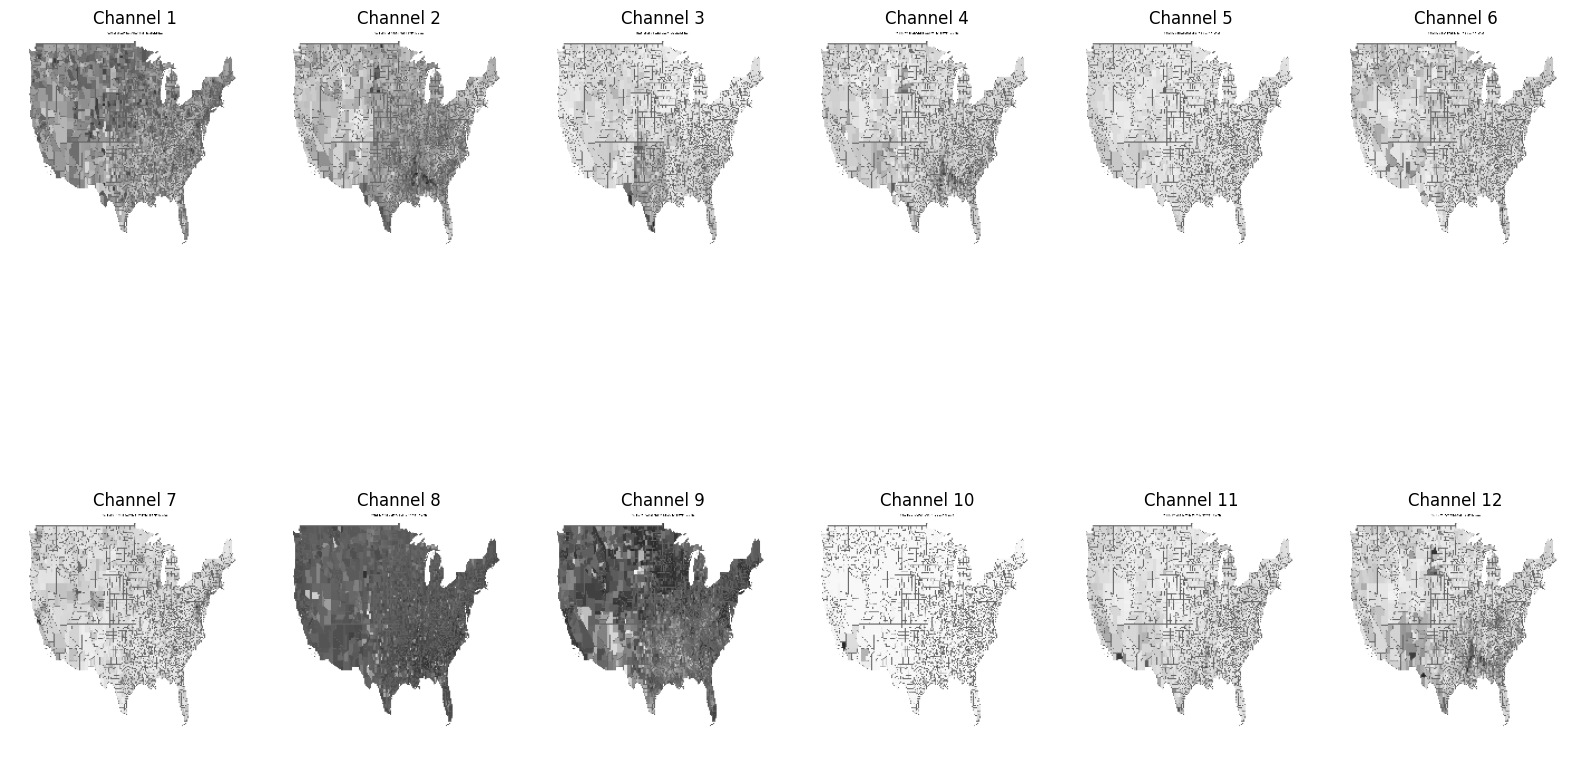

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

image = X_train[0]

print(f"Shape of the image: {image.shape}")

fig, axes = plt.subplots(2, 6, figsize=(16, 12))
axes = axes.flatten()

for i in range(12):
    axes[i].imshow(image[:, :, i], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Channel {i+1}")

plt.tight_layout()
plt.show()


In [ ]:
X_trainOfficial.shape

(5, 224, 224, 12)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def build_cnn_model(input_shape):
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))

    model.add(layers.Dense(input_shape[0] * input_shape[1], activation='linear'))

    model.add(layers.Reshape((input_shape[0], input_shape[1])))

    return model

model = build_cnn_model((224, 224, 12))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(X_trainOfficial, y_trainOfficial, epochs=15, batch_size=1, validation_data=(X_testOfficial, y_testOfficial))

test_loss, test_mae = model.evaluate(X_testOfficial, y_testOfficial)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

model.save("cnn_heatmap_model_2023_test.h5")


Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 377ms/step - loss: 0.7306 - mae: 0.7893 - val_loss: 0.2683 - val_mae: 0.4872
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 509ms/step - loss: 0.2962 - mae: 0.5072 - val_loss: 0.1687 - val_mae: 0.3502
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - loss: 0.1333 - mae: 0.3009 - val_loss: 0.0392 - val_mae: 0.1670
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 313ms/step - loss: 0.0323 - mae: 0.1489 - val_loss: 0.0183 - val_mae: 0.1127
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - loss: 0.0166 - mae: 0.1060 - val_loss: 0.0078 - val_mae: 0.0691
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - loss: 0.0089 - mae: 0.0752 - val_loss: 0.0071 - val_mae: 0.0707
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - loss: 0.0053 - mae: 0.0601 - val_loss: 0.0057 - val_mae: 0.0594
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 321ms/step - loss: 0.0038 - mae: 0.0499 - val_loss: 0.0021 - val_mae: 0.0315
Epoch 9/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 499ms/step - loss: 0.0018 - mae: 

Test Loss: 0.001154884696006775, Test MAE: 0.01753629557788372


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50176)          │     3,261,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 224, 224)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,323,746 (165.27 MB)

 Trainable params: 14,441,248 (55.09 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,882,498 (110.18 MB)

In [ ]:
sample_prediction = model.predict(X_testOfficial)
print("Prediction shape:", sample_prediction.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Prediction shape: (1, 224, 224)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


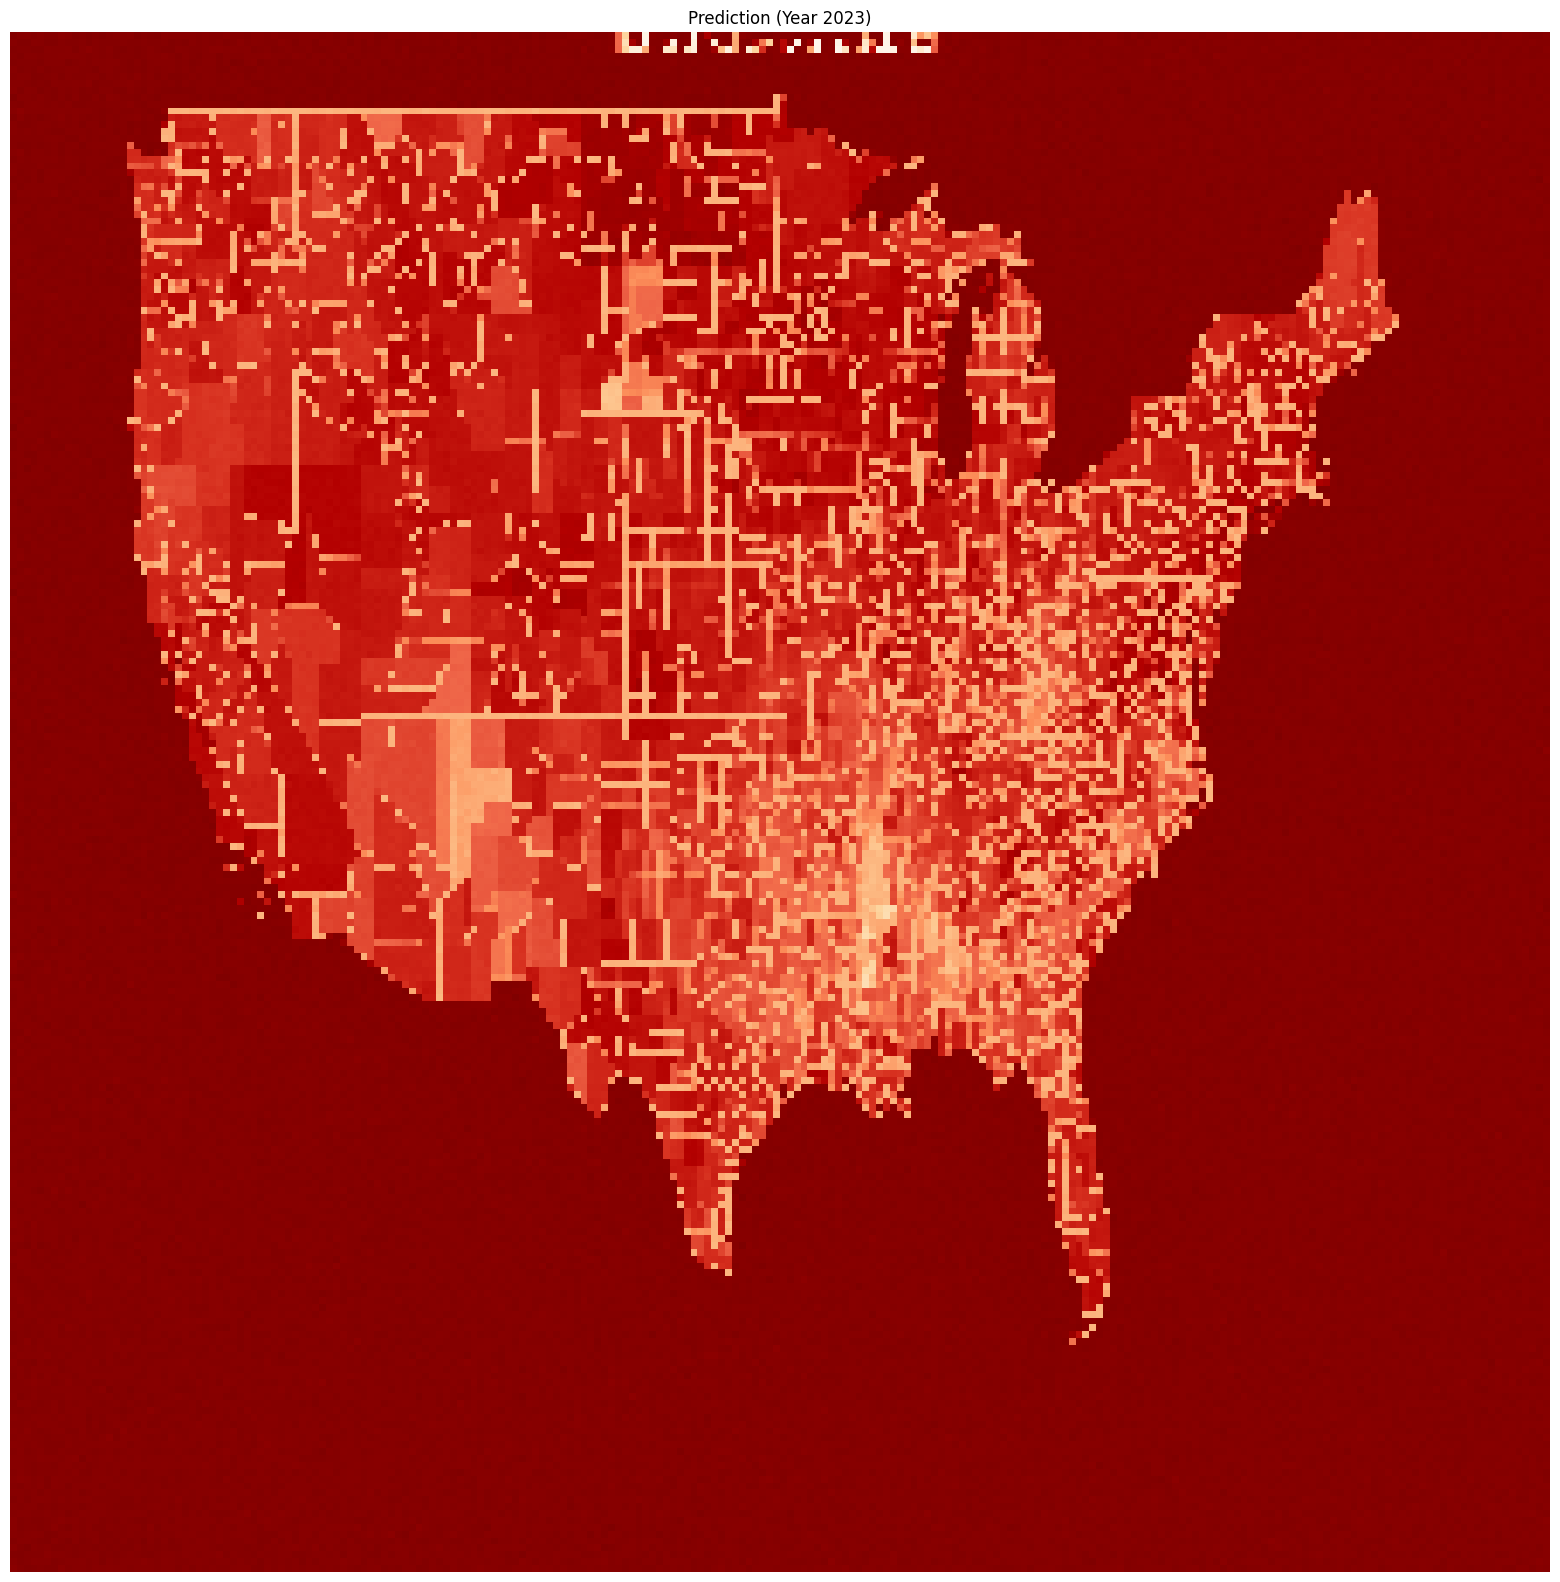

In [ ]:

import matplotlib.pyplot as plt

predictions = model.predict(X_testOfficial)
predictions*=255
plt.figure(figsize=(20, 20))
plt.imshow(predictions[0], cmap='OrRd')
plt.title(f"Prediction (Year 2023)")
plt.axis('off')
plt.show()


In [ ]:

import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [ ]:
for i in heatmaps[2023 - 2018, -1, :, :, 0][45]:
  print(i)

255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
171.0
213.0
200.0
204.0
204.0
204.0
204.0
215.0
215.0
100.0
205.0
205.0
205.0
202.0
181.0
181.0
181.0
181.0
193.0
200.0
200.0
193.0
211.0
211.0
211.0
217.0
217.0
217.0
189.0
189.0
189.0
189.0
189.0
189.0
203.0
203.0
230.0
230.0
230.0
219.0
219.0
209.0
218.0
218.0
211.0
216.0
216.0
216.0
216.0
104.0
210.0
210.0
210.0
210.0
193.0
193.0
193.0
193.0
206.0
206.0
206.0
218.0
218.0
218.0
210.0
100.0
230.0
230.0
230.0
100.0
129.0
214.0
214.0
238.0
238.0
238.0
190.0
222.0
238.0
224.0
224.0
218.0
218.0
218.0
228.0
228.0
224.0
224.0
225.0
133.0
225.0
228.0
228.0
102.0
100.0
230.0
199.0
230.0
232.0
229.0
229.0
230.0
199.0
220.0
226.0
209.0
209.0
209.0
217.0
217.0
225.0
100.0
222.0
230.0
230.0
224.0
163.0
255.0
255.0
255.0
255.0
190.0
118.0
180.0
183.0
103.0
146.0
156.0
129.0
165.0
246.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.0
255.

In [ ]:
'''import geopandas as gpd
from shapely.geometry import Point
!pip install rtree
from rtree import index
import numpy as np
#from collections import Counter
import statistics

min_lon, max_lon = -125.0, -66.0
min_lat, max_lat = 24.396308, 49.384358

county_index = index.Index()
for i, county in enumerate(gdf.geometry):
    county_index.insert(i, county.bounds)

def map_predictions_to_counties_optimized(predictions, gdf):
    county_prediction_dict = {county_id: [] for county_id in gdf['GEOID']}

    print("Shape of predictions:", predictions.shape)

    img_size = predictions.shape[1]

    for row in range(0, img_size):
        for col in range(0, img_size):
            pixel_lon = (col / img_size) * (max_lon - min_lon) + min_lon
            pixel_lat = (row / img_size) * (max_lat - min_lat) + min_lat
            point = Point(pixel_lon, pixel_lat)

            if row % 50 == 0 and col % 50 == 0:
                print(f"Pixel Coordinates: ({row}, {col}) -> (Longitude: {pixel_lon}, Latitude: {pixel_lat})")

            possible_counties = list(county_index.intersection((point.x, point.y, point.x, point.y)))
            if not possible_counties:
                print(f"No counties found for pixel at ({row}, {col})")

            for county_idx in possible_counties:
                county = gdf.iloc[county_idx]
                if county['geometry'].contains(point):
                    print(f"Pixel belongs to county: {county['GEOID']}")
                    if row < predictions.shape[1] and col < predictions.shape[2]:
                        county_prediction_dict[county['GEOID']].append(predictions[0, row, col])
                    break
    for county_id, preds in county_prediction_dict.items():
        if not preds:
            print(f"No predictions assigned to county {county_id}")
    print(county_prediction_dict)
    county_avg_predictions = {county_id: np.mean(preds) if preds else np.nan
                              for county_id, preds in county_prediction_dict.items()}

    return county_avg_predictions, county_prediction_dict

county_predictions,mappings = map_predictions_to_counties_optimized(predictions, gdf)
print(county_predictions)
'''
import geopandas as gpd
from shapely.geometry import Point
!pip install rtree
from rtree import index
import numpy as np

min_lon, max_lon = -125.0, -66.0
min_lat, max_lat = 24.396308, 49.384358

county_index = index.Index()
for i, county in enumerate(gdf.geometry):
    county_index.insert(i, county.bounds)

def map_predictions_to_counties_optimized(predictions, gdf):
    county_prediction_dict = {county_id: [] for county_id in gdf['GEOID']}

    print("Shape of predictions:", predictions.shape)

    img_size = predictions.shape[1]

    for row in range(0, img_size):
        for col in range(0, img_size):
            pixel_lon = (col / img_size) * (max_lon - min_lon) + min_lon
            pixel_lat = (row / img_size) * (max_lat - min_lat) + min_lat
            point = Point(pixel_lon, pixel_lat)

            if row % 50 == 0 and col % 50 == 0:
                print(f"Pixel Coordinates: ({row}, {col}) -> (Longitude: {pixel_lon}, Latitude: {pixel_lat})")

            possible_counties = list(county_index.intersection((point.x, point.y, point.x, point.y)))
            if not possible_counties:
                print(f"No counties found for pixel at ({row}, {col})")

            for county_idx in possible_counties:
                county = gdf.iloc[county_idx]
                if county['geometry'].contains(point):
                    print(f"Pixel belongs to county: {county['GEOID']}")
                    if row < predictions.shape[1] and col < predictions.shape[2]:
                        county_prediction_dict[county['GEOID']].append(predictions[0, row, col])
                    break

    for county_id, preds in county_prediction_dict.items():
        if not preds:
            print(f"No predictions assigned to county {county_id}")

    county_avg_predictions = {county_id: np.mean(preds) if preds else np.nan
                              for county_id, preds in county_prediction_dict.items()}

    return county_avg_predictions, county_prediction_dict

county_predictions, tru = map_predictions_to_counties_optimized(predictions, gdf)

print(county_predictions)
print(tru)


Streaming output truncated to the last 5000 lines.
Pixel belongs to county: 26131
Pixel belongs to county: 26131
Pixel belongs to county: 26131
Pixel belongs to county: 26061
Pixel belongs to county: 26013
Pixel belongs to county: 26013
Pixel belongs to county: 26013
Pixel belongs to county: 26103
No counties found for pixel at (201, 144)
No counties found for pixel at (201, 145)
No counties found for pixel at (201, 146)
No counties found for pixel at (201, 147)
No counties found for pixel at (201, 148)
No counties found for pixel at (201, 149)
No counties found for pixel at (201, 150)
No counties found for pixel at (201, 151)
No counties found for pixel at (201, 152)
No counties found for pixel at (201, 153)
No counties found for pixel at (201, 154)
No counties found for pixel at (201, 155)
No counties found for pixel at (201, 156)
No counties found for pixel at (201, 157)
No counties found for pixel at (201, 158)
No counties found for pixel at (201, 159)
No counties found for pixel a

In [ ]:
actual_data = np.expand_dims(heatmaps[2023-2018, -1, :, :, 0], axis=0)  # Shape becomes (1, 244, 244)
actualData, mappingsActual = map_predictions_to_counties_optimized(actual_data, gdf)
print(actualData)


Streaming output truncated to the last 5000 lines.
No counties found for pixel at (201, 133)
Pixel belongs to county: 26131
Pixel belongs to county: 26131
Pixel belongs to county: 26131
Pixel belongs to county: 26061
Pixel belongs to county: 26013
Pixel belongs to county: 26013
Pixel belongs to county: 26013
Pixel belongs to county: 26103
No counties found for pixel at (201, 144)
No counties found for pixel at (201, 145)
No counties found for pixel at (201, 146)
No counties found for pixel at (201, 147)
No counties found for pixel at (201, 148)
No counties found for pixel at (201, 149)
No counties found for pixel at (201, 150)
No counties found for pixel at (201, 151)
No counties found for pixel at (201, 152)
No counties found for pixel at (201, 153)
No counties found for pixel at (201, 154)
No counties found for pixel at (201, 155)
No counties found for pixel at (201, 156)
No counties found for pixel at (201, 157)
No counties found for pixel at (201, 158)
No counties found for pixel a

In [ ]:
'''count = 0
for key, value in county_predictions.items():
    count+=1
    if key == "17055":
      print(f"County Prediction:       {county_predictions[key]} + Actual Prediction:             {actualData[key]}")
    if abs(actualData[key] - county_predictions[key]) < 1:
        county_predictions[key] = actualData[key]'''

'count = 0\nfor key, value in county_predictions.items():\n    count+=1\n    if key == "17055":\n      print(f"County Prediction:       {county_predictions[key]} + Actual Prediction:             {actualData[key]}")\n    if abs(actualData[key] - county_predictions[key]) < 1:\n        county_predictions[key] = actualData[key]'

In [ ]:
print(county_predictions["17055"])
print(actualData["17055"])

158.91656
142.33333


In [ ]:
'''for i in count.items():
  for j in i:
    if abs(dict(count[i])) == abs(dict(countActual[i])):
      tru.append(count[i])
tru
'''

'for i in count.items():\n  for j in i:\n    if abs(dict(count[i])) == abs(dict(countActual[i])):\n      tru.append(count[i])\ntru\n'

In [ ]:
predictions_df = pd.DataFrame(list(county_predictions.items()), columns=['COUNTYFP', 'Predicted_Food_Insecurity'])

In [ ]:
predictions_df

,COUNTYFP,Predicted_Food_Insecurity
0,21007,202.305206
1,21017,138.233276
2,21031,172.574326
3,21065,175.512238
4,21069,151.583313
...,...,...
3228,31073,158.299118
3229,39075,252.608994
3230,48171,190.957520
3231,55079,252.014374


In [ ]:
'''
	COUNTYFP	Actual_Food_Insecurity
0	21007	189.631577
1	21017	101.363640
2	21031	195.000000
3	21065	208.000000
4	21069	195.000031
...	...	...
3228	31073	169.444458
3229	39075	255.000000
3230	48171	195.000046
3231	55079	255.000000
3232	26139	255.000000
'''
predictions_df.iloc[2340:2400]

,COUNTYFP,Predicted_Food_Insecurity
2340,30097,253.060211
2341,01019,161.073105
2342,28015,163.470535
2343,55031,253.371094
2344,01085,187.306473
2345,55101,253.633698
2346,28135,169.219025
2347,28145,134.190445
2348,55129,253.202789
2349,46051,252.401093


In [ ]:
len(predictions[0][0])

224

In [ ]:
acutal_df = pd.DataFrame(list(actualData.items()), columns=['COUNTYFP', 'Actual_Food_Insecurity'])
'''
COUNTYFP	Predicted_Food_Insecurity
0	21007	204.054565
1	21017	102.108696
2	21031	195.365936
3	21065	176.833939
4	21069	165.552246
...	...	...
3228	31073	185.938324
3229	39075	254.205170
3230	48171	207.381302
3231	55079	255.157562
3232	26139	253.194794

'''
acutal_df.iloc[2340:2400]
merge2_df = acutal_df.merge(predictions_df, on="COUNTYFP", how="outer")
merge2_df.iloc[2340:2400]

,COUNTYFP,Actual_Food_Insecurity,Predicted_Food_Insecurity
2340,45049,176.750000,179.343140
2341,45051,206.333328,209.728043
2342,45053,197.399994,195.635300
2343,45055,169.375000,167.680313
2344,45057,163.500000,159.436813
2345,45059,176.166672,177.785156
2346,45061,188.666672,190.520035
2347,45063,204.199997,206.485397
2348,45065,196.500000,193.171219
2349,45067,167.500000,174.423553


In [ ]:
predictions_df.iloc[2500]

,2500
COUNTYFP,38019
Predicted_Food_Insecurity,253.292999


In [ ]:
actual_df_o = pd.DataFrame(mega_df_2023['FoodInsecurity'])
actual_df_o["COUNTYFP"] = merge2_df['COUNTYFP']
acutal_df_original = merge2_df.merge(actual_df_o, on="COUNTYFP", how="outer")
acutal_df_original = acutal_df_original.dropna()
acutal_df_original[acutal_df_original['COUNTYFP'] == '46053']

,COUNTYFP,Actual_Food_Insecurity,Predicted_Food_Insecurity,FoodInsecurity
2387,46053,163.5,194.273193,14.5


In [ ]:
import pandas as pd


acutal_df_original['conversion_factor'] = acutal_df_original['Actual_Food_Insecurity'] / mega_df_2023['FoodInsecurity']

acutal_df_original['Predicted_Food_Insecurity_Converted'] = acutal_df_original['Predicted_Food_Insecurity'] / acutal_df_original['conversion_factor']
acutal_df_original["FoodInsecurity"] = mega_df_2023['FoodInsecurity']

final_predictions_df = acutal_df_original[['COUNTYFP', 'Predicted_Food_Insecurity_Converted', 'FoodInsecurity']]
acutal_df_original[acutal_df_original['COUNTYFP'] == '46023']

,COUNTYFP,Actual_Food_Insecurity,Predicted_Food_Insecurity,FoodInsecurity,conversion_factor,Predicted_Food_Insecurity_Converted
2372,46023,142.769226,197.282318,2.7,52.877491,3.730932


In [ ]:
df_cleaned = final_predictions_df.dropna()
df_cleaned.iloc[2340:2400]

,COUNTYFP,Predicted_Food_Insecurity_Converted,FoodInsecurity
2405,46089,15.464801,15.6
2406,46091,11.196971,11.3
2407,46093,15.072134,15.2
2408,46095,16.906663,17.0
2409,46097,10.858843,10.3
2410,46099,11.005750,11.1
2411,46101,10.970013,11.1
2412,46102,15.893436,16.0
2413,46103,10.323032,10.4
2414,46105,8.947086,9.0


In [ ]:
'''import pandas as pd
import numpy as np

# Assuming 'df_cleaned' is your initial dataframe
# Drop rows with missing values to create a cleaned dataframe

filtered_df = df_cleaned[
    df_cleaned['Predicted_Food_Insecurity_Converted'].apply(
        lambda x: isinstance(x, np.ndarray) and len(x) > 0 and not pd.isna(x[0])
    )
]

def convert_to_int(cell):
    if isinstance(cell, np.ndarray) and len(cell) > 0 and not pd.isna(cell[0]):
        return float(cell[0])  # Convert first element to integer
    return np.nan

filtered_df['Predicted_Food_Insecurity_Integer'] = filtered_df['Predicted_Food_Insecurity_Converted'].apply(convert_to_int)
filtered_df['Actual_Food_Insecurity'] = filtered_df['Actual_Food_Insecurity'].fillna(filtered_df['Predicted_Food_Insecurity_Integer'])
filtered_df[filtered_df.isna().any(axis=1)]
'''

"import pandas as pd\nimport numpy as np\n\n# Assuming 'df_cleaned' is your initial dataframe\n# Drop rows with missing values to create a cleaned dataframe\n\nfiltered_df = df_cleaned[\n    df_cleaned['Predicted_Food_Insecurity_Converted'].apply(\n        lambda x: isinstance(x, np.ndarray) and len(x) > 0 and not pd.isna(x[0])\n    )\n]\n\ndef convert_to_int(cell):\n    if isinstance(cell, np.ndarray) and len(cell) > 0 and not pd.isna(cell[0]):\n        return float(cell[0])  # Convert first element to integer\n    return np.nan\n\nfiltered_df['Predicted_Food_Insecurity_Integer'] = filtered_df['Predicted_Food_Insecurity_Converted'].apply(convert_to_int)\nfiltered_df['Actual_Food_Insecurity'] = filtered_df['Actual_Food_Insecurity'].fillna(filtered_df['Predicted_Food_Insecurity_Integer'])\nfiltered_df[filtered_df.isna().any(axis=1)]\n"

In [ ]:
import numpy as np
mae_list = []
for i in range(len(df_cleaned["FoodInsecurity"])):
  mae_list.append(abs(list(df_cleaned["FoodInsecurity"])[i] - list(df_cleaned["Predicted_Food_Insecurity_Converted"])[i]))

mae = mean_absolute_error(df_cleaned["FoodInsecurity"], df_cleaned["Predicted_Food_Insecurity_Converted"])

In [ ]:
print(mae)

0.419724050180726


In [ ]:
for i in mae_list:
  print(i)

0.2252639378089505
0.6334334165053974
0.775159254312829
0.01708849276222324
0.029004528117628325
1.0238499173215025
0.5973183052372075
0.8062630859286557
0.021049111576403767
1.0475117682515194
0.28305896293826294
0.5251435624491769
0.4325786347583165
0.4031702194770759
1.8223782993047237
0.46199105259228634
0.05350295760625734
0.775894099657684
0.8905345108295712
0.5718370899650633
0.32682234092433404
0.23323488096975886
0.2026229982322718
0.21108886371466085
0.8940323598729059
0.34754890488700596
0.9074418560685089
1.4397218605324085
0.40254183376536723
0.05895596265892422
0.26611900046419557
0.2976740094986514
0.694171998729173
0.07575152975975463
0.12124606861787868
0.5569473630182857
0.02409906814107643
0.26747104168773816
0.6512397300469477
0.02567673609415433
0.14356628836017826
0.018871209787766574
0.24332198387723203
0.6082450394147969
0.4592178757126266
0.450993795663047
1.3554160375251598
0.2126516461372372
0.060966161744956615
0.44565294625598817
0.2443313991188898
0.003171

In [ ]:
for i  in df_cleaned["Predicted_Food_Insecurity_Converted"]:
  print(i)

21.02526393780895
23.433433416505398
22.175159254312828
8.117088492762223
16.17099547188237
19.523849917321503
13.797318305237209
14.706263085928658
6.621049111576404
8.54751176825152
9.183058962938263
10.025143562449177
9.932578634758316
11.003170219477076
15.222378299304724
8.161991052592287
7.053502957606258
14.775894099657686
23.490534510829573
13.571837089965063
10.626822340924333
8.833234880969759
15.202622998232272
10.011088863714662
17.794032359872908
10.647548904887005
12.707441856068508
15.33972186053241
13.102541833765367
17.841044037341074
10.566119000464194
9.597674009498652
13.594171998729173
10.824248470240246
16.778753931382123
5.356947363018286
8.475900931858924
11.367471041687738
13.451239730046948
6.674323263905846
13.643566288360178
13.718871209787768
9.343321983877232
13.508245039414797
13.559217875712628
12.150993795663048
18.255416037525162
10.112651646137238
6.960966161744957
8.745652946255989
13.04433139911889
9.40317145453559
15.983467684659091
11.554450584369

In [ ]:
cleaned_df = final_predictions_df.dropna()
cleaned_df
import pandas as pd
import numpy as np

cleaned_df['MAE'] = np.abs(cleaned_df['FoodInsecurity'] - cleaned_df['Predicted_Food_Insecurity_Converted'])

# Count counties with MAE below 5
counties_below_5 = cleaned_df[cleaned_df['MAE'] < .25].shape[0]

# Display the DataFrame with MAE column
cleaned_df["State/county"] = poverty_df['State/county']
cleaned_df.dropna(inplace=True)
cleaned_df


,COUNTYFP,Predicted_Food_Insecurity_Converted,FoodInsecurity,MAE,State/county
0,01001,21.025264,20.8,0.225264,"Autauga County, AL"
1,01003,23.433433,22.8,0.633433,"Baldwin County, AL"
2,01005,22.175159,21.4,0.775159,"Barbour County, AL"
3,01007,8.117088,8.1,0.017088,"Bibb County, AL"
4,01009,16.170995,16.2,0.029005,"Blount County, AL"
...,...,...,...,...,...
3137,56037,17.863628,18.0,0.136372,"Monroe County, WI"
3138,56039,11.131694,11.2,0.068306,"Oconto County, WI"
3139,56041,6.348518,6.4,0.051482,"Oneida County, WI"
3140,56043,21.729813,21.9,0.170187,"Outagamie County, WI"


In [ ]:
dfARIMA = pd.DataFrame()
'''forecasts = pd.DataFrame(forecast)
forecasts.reset_index(drop=True, inplace=True)
dfARIMA["forecast"] = forecasts
dfARIMA["Actual"] = dfLSTM['2023']
dfARIMA["MAE"] = np.abs(dfARIMA['Actual'] - dfARIMA['forecast'])
counties_below_5ARIMA = dfARIMA[dfARIMA['MAE'] < .25].shape[0]
dfARIMA["State/county"] = dfLSTM['State/county']
dfLSTM'''

'forecasts = pd.DataFrame(forecast)\nforecasts.reset_index(drop=True, inplace=True)\ndfARIMA["forecast"] = forecasts\ndfARIMA["Actual"] = dfLSTM[\'2023\']\ndfARIMA["MAE"] = np.abs(dfARIMA[\'Actual\'] - dfARIMA[\'forecast\'])\ncounties_below_5ARIMA = dfARIMA[dfARIMA[\'MAE\'] < .25].shape[0]\ndfARIMA["State/county"] = dfLSTM[\'State/county\']\ndfLSTM'

In [ ]:
dfARIMA.dropna(inplace=True)
dfARIMA

""


In [ ]:
'''df = dfLSTM.dropna(subset=['State/county'])
'''
# Filter for New Jersey counties
'''nj_counties = df[df['State/county'].str.contains('MA', na=False)]

# Create bar chart
plt.figure(figsize=(12, 8))
plt.bar(nj_counties['State/county'], nj_counties['MAE'], color='skyblue')
plt.xlabel('County')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE for each County in Massachusets for LSTM')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show plot
plt.show()'''

"nj_counties = df[df['State/county'].str.contains('MA', na=False)]\n\n# Create bar chart\nplt.figure(figsize=(12, 8))\nplt.bar(nj_counties['State/county'], nj_counties['MAE'], color='skyblue')\nplt.xlabel('County')\nplt.ylabel('Mean Absolute Error (MAE)')\nplt.title('MAE for each County in Massachusets for LSTM')\nplt.xticks(rotation=45, ha='right')\nplt.tight_layout()\n\n# Show plot\nplt.show()"

In [ ]:
'''df = dfARIMA.dropna(subset=['State/county'])

# Filter for New Jersey counties
nj_counties = df[df['State/county'].str.contains('MA', na=False)]

# Create bar chart
plt.figure(figsize=(12, 8))
plt.bar(nj_counties['State/county'], nj_counties['MAE'], color='skyblue')
plt.xlabel('County')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE for each County in Massachusets for ARIMA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show plot
plt.show()'''

"df = dfARIMA.dropna(subset=['State/county'])\n\n# Filter for New Jersey counties\nnj_counties = df[df['State/county'].str.contains('MA', na=False)]\n\n# Create bar chart\nplt.figure(figsize=(12, 8))\nplt.bar(nj_counties['State/county'], nj_counties['MAE'], color='skyblue')\nplt.xlabel('County')\nplt.ylabel('Mean Absolute Error (MAE)')\nplt.title('MAE for each County in Massachusets for ARIMA')\nplt.xticks(rotation=45, ha='right')\nplt.tight_layout()\n\n# Show plot\nplt.show()"

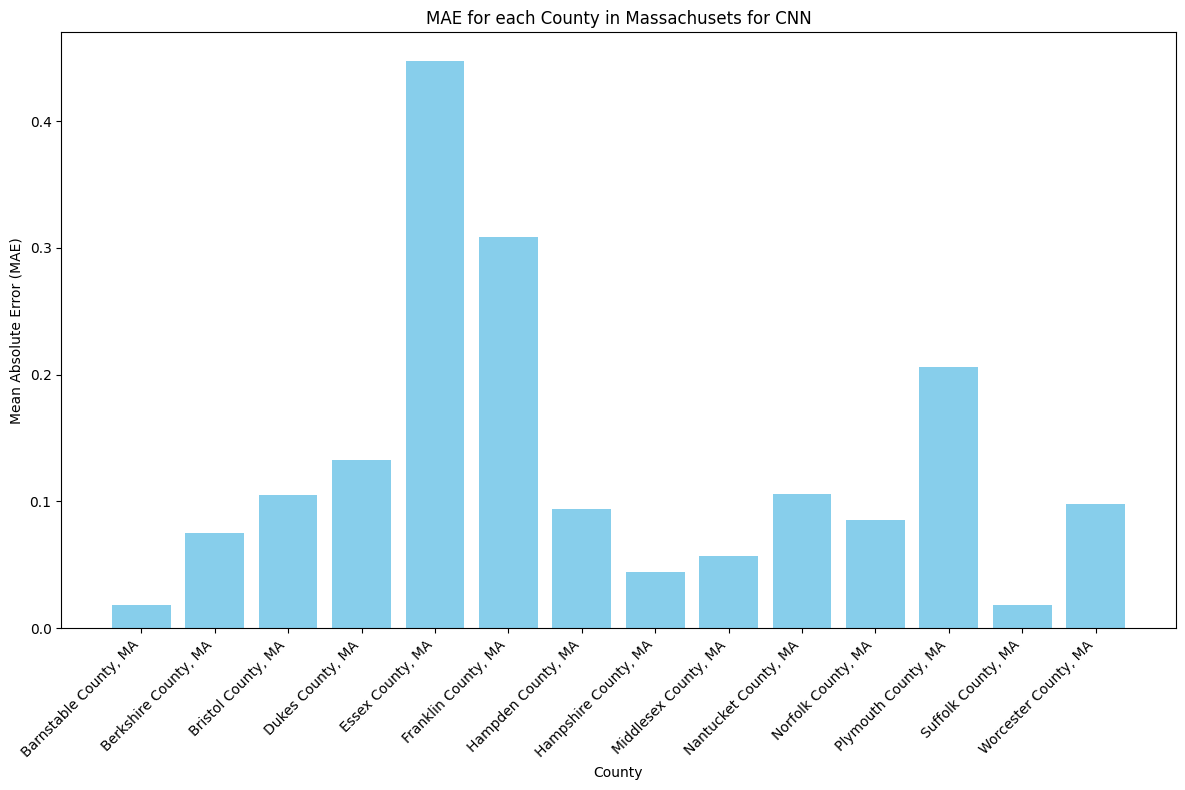

In [ ]:
df = cleaned_df.dropna(subset=['State/county'])

# Filter for New Jersey counties
nj_counties = df[df['State/county'].str.contains('MA', na=False)]

# Create bar chart
plt.figure(figsize=(12, 8))
plt.bar(nj_counties['State/county'], nj_counties['MAE'], color='skyblue')
plt.xlabel('County')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE for each County in Massachusets for CNN')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show plot
plt.show()

In [ ]:
gdf_mega_2023

,State/county,CollegeGraduation,ObesityRate,UninsuredRate,SingleParentHouseholds,Median Household Income,HousingProblems,ElderlyPopulation,FemalePopulation,TotalPopulation,UnemploymentRate,FoodInsecurity,PovertyRate,Food Environment Index,geometry,Year
0,"Ziebach County, SD",44.4615,47.4,13.5196,52.5473,42254,24.5033,10.6303,49.7059,2380,4.5168,20.8,45.8,4.1,"POLYGON ((-102.00044 44.69, -102.00015 44.9506...",2023
1,"Zavala County, TX",54.5965,46.5,20.1470,60.9148,36878,18.6275,14.3172,48.8253,9534,12.6679,22.8,38.8,3.9,"POLYGON ((-100.11314 28.77625, -100.11329 28.7...",2023
2,"Zapata County, TX",36.9616,43.7,26.1543,23.4020,41688,23.6404,13.1219,50.0360,13908,12.0636,21.4,44.6,5.6,"POLYGON ((-99.4538 27.26506, -99.42542 27.2836...",2023
3,"Yuma County, CO",61.6456,27.5,15.0362,19.5820,61870,14.0199,18.5494,49.3713,9941,2.7347,8.1,18.2,8.6,"POLYGON ((-102.80364 40.00255, -102.7933 40.00...",2023
4,"Yuma County, AZ",54.9942,40.5,15.3857,30.9170,61225,18.9056,19.5995,48.1574,206990,12.9167,16.2,25.0,6.5,"POLYGON ((-114.81629 32.50804, -114.81432 32.5...",2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,"Adair County, IA",61.2553,35.8,4.6101,17.4489,67873,9.3750,22.1854,49.5160,7541,3.0880,8.9,13.8,8.8,"POLYGON ((-94.70072 41.46725, -94.70057 41.482...",2023
3150,"Ada County, ID",74.9553,27.7,6.4689,18.4134,90513,12.8897,15.5667,49.6598,511931,3.2577,7.8,9.1,8.6,"POLYGON ((-116.51345 43.43706, -116.51349 43.4...",2023
3151,"Accomack County, VA",44.3686,38.3,11.5873,37.0241,56039,13.4301,25.2121,50.9264,33246,4.3490,11.8,25.7,8.3,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",2023
3152,"Acadia County, LA",42.4158,38.3,8.2561,31.7280,43133,12.5928,16.1744,50.8414,57288,4.9451,17.3,28.7,7.0,"POLYGON ((-92.63229 30.31708, -92.62923 30.318...",2023


In [ ]:
dup

NameError: name 'dup' is not defined

In [ ]:
predictDF = pd.DataFrame(cleaned_df["Predicted_Food_Insecurity_Converted"])

In [ ]:
dup = gdf_mega_2023.copy()
merged_gdf = pd.merge(dup, predictDF, left_index=True, right_index=True, how='outer')

print(merged_gdf.head())

dup['Predicted_Food_Insecurity']= cleaned_df['Predicted_Food_Insecurity_Converted']
dup['Predicted_Food_Insecurity'].fillna(gdf_mega_2023['FoodInsecurity'], inplace=True)
dup.isnull().sum()

In [ ]:
def show_full_heatmap(gdf, column, title):
    fig, ax = plt.subplots(1, 1, figsize=(30, 15))
    gdf.boundary.plot(ax=ax, linewidth=1)
    gdf.plot(column=column, ax=ax, legend=False, cmap='OrRd')
    ax.set_xlim([-130, -60])
    ax.set_ylim([20, 50])
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_full_heatmapOfActual(gdf, column, year):
    fig, ax = plt.subplots(1, 1, figsize=(30, 15))
    gdf.boundary.plot(ax=ax, linewidth=1)
    gdf.plot(column=column, ax=ax, legend=False,
             cmap='OrRd')

    ax.set_xlim([-130, -60])
    ax.set_ylim([20, 50])

    plt.title(f'Heatmap of {column} for the USA for {year}')
    plt.axis('off')
    plt.show()


show_full_heatmap(gdf_mega_2023, 'FoodInsecurity', "Heatmap of Actual Food Insecurity")

In [ ]:
show_full_heatmap(dup, 'Predicted_Food_Insecurity', 'Heatmap of Predicted Food Insecurity')

In [ ]:
if "34005" in list(cleaned_df['COUNTYFP']):
  print(True)

In [ ]:
dfDream = pd.DataFrame()
dfDream["2018"] = gdf_mega_2018['FoodInsecurity']
dfDream["2019"] = gdf_mega_2019['FoodInsecurity']
dfDream["2020"] = gdf_mega_2020['FoodInsecurity']
dfDream["2021"] = gdf_mega_2021['FoodInsecurity']
dfDream["2022"] = gdf_mega_2022['FoodInsecurity']
dfDream["2023"] = gdf_mega_2023['FoodInsecurity']
dfDream["predicted2023"] = dup['Predicted_Food_Insecurity']
dfDream["State/county"] = dup['State/county']
for i in list(dfDream['2023']):
  print(i)

In [ ]:
for i in dfDream["predicted2023"]:
  print(i)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_fit_and_forecast(df, county):
    fig, ax = plt.subplots(figsize=(10, 6))

    county_data = df[df["State/county"] == county].iloc[0]
    years = ['2018', '2019', '2020', '2021', '2022', '2023']

    ax.plot(years, county_data[years], label='Actual (2018-2023)', color='blue', marker='o')

    ax.plot('2023', county_data['predicted2023'], label='Predicted 2023', color='orange', marker='o')

    ax.set_xlabel('Year')
    ax.set_ylabel('Values')
    ax.set_title(f'Actual vs Predicted for {county}')
    ax.legend()
    ax.grid(True)
    plt.show()

    print(f"Predicted 2023 value for {county}: {county_data['predicted2023']}")
plot_fit_and_forecast(dfDream, county="Zavala County, TX")


In [ ]:
'''dfLSTM = pd.DataFrame()
dfLSTM["2018"] = gdf_mega_2018['FoodInsecurity']
dfLSTM["2019"] = gdf_mega_2019['FoodInsecurity']
dfLSTM["2020"] = gdf_mega_2020['FoodInsecurity']
dfLSTM["2021"] = gdf_mega_2021['FoodInsecurity']
dfLSTM["2022"] = gdf_mega_2022['FoodInsecurity']
dfLSTM["2023"] = gdf_mega_2023['FoodInsecurity']
dfLSTM = dfLSTM.reset_index(drop=True)
dfLSTM["predicted2023"] = predictionLSTM
dfLSTM["State/county"] = gdf_mega_2018['State/county']
dfLSTM'''

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_fit_and_forecast(df, county):
    fig, ax = plt.subplots(figsize=(10, 6))

    county_data = df[df["State/county"] == county].iloc[0]
    years = ['2018', '2019', '2020', '2021', '2022', '2023']

    ax.plot(years, county_data[years], label='Actual (2018-2023)', color='blue', marker='o')

    ax.plot('2023', county_data['predicted2023'], label='Predicted 2023', color='orange', marker='o')

    ax.set_xlabel('Year')
    ax.set_ylabel('Values')
    ax.set_title(f'Actual vs Predicted for {county}')
    ax.legend()
    ax.grid(True)
    plt.show()

    print(f"Predicted 2023 value for {county}: {county_data['predicted2023']}")
'''plot_fit_and_forecast(dfLSTM, county="Zavala County, TX")
'''

In [ ]:
dfCNN = pd.DataFrame(predictDF)
dfLSTM = pd.DataFrame(list(y_pred_df[0]))
rows = merge11[dups]
df = merge11.drop_duplicates(subset=["State/county"], keep='first')
df[df.isna().any(axis=1)]
df = df.reset_index(drop=True)
dfLSTM["State/county"] = df["State/county"]
dfCNN["State/county"] = df["State/county"]
arima_df = pd.DataFrame(list(forecast))
arima_df["State/county"] = df["State/county"]
name = "State/county"
arima_df = arima_df.reset_index(drop=True)
merged_df = pd.merge(dfLSTM, dfCNN, on=name, how='outer')  # 'outer' keeps all rows
merged_df = pd.merge(merged_df, arima_df, on=name, how='outer')
merged_df = merged_df.fillna(method='ffill')
merged_df["LSTM"] = merged_df["0_x"]
merged_df["ARIMA"] = merged_df["0_y"]
merged_df["CNN"] = merged_df["Predicted_Food_Insecurity_Converted"]
merged_df.drop('0_x', axis=1, inplace=True)
merged_df.drop('0_y', axis=1, inplace=True)
merged_df.drop('Predicted_Food_Insecurity_Converted', axis=1, inplace=True)
merged_df